# **PyMC Price Target Model V3**

## Price Target Achievement — Hierarchical Student-t Regression

Schema-aligned with:
- MV: `pml.mv_pymc_price_target`
- Catalogue: `SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'price_target'`

Likelihood:
- `feat_pt_achievement_1y ~ StudentT(ν, μ_isin, σ_isin)` (heavy-tailed analyst noise)
- `μ_isin = α_sector[sector] + X_std · β`
- `σ_isin = σ_base / sqrt(n_analysts)` (precision-weighted by analyst count)


## 1. Notebook Setup & Imports

Shared imports for EDA, schema-aligned summary statistics, PyMC modelling, and prior/posterior predictive diagnostics. The `price_target_df` and `feature_catalogue` DataFrames produced by the two `%%sql` cells above are reused throughout.


In [1]:
%%sql
SELECT * FROM pml.mv_pymc_price_target WHERE income_statement_report_date > '2025-01-01' AND next_earnings >= '2026-01-01'

,isin,ticker,name,region,country,trading_country,exchange,unit,style_class,size_class,...,feat_ev_ebitda_ntm,feat_vol_3m,feat_analyst_rating,feat_pt_achievement_1y,feat_pt_accuracy_1y,feat_pt_optimism_bias,feat_pt_range_hit_rate,feat_pt_median_vs_mean_spread,feat_pt_high_low_convergence_1y,feat_analyst_count_stability
0,US67066G1040,NVDA,NVIDIA Corporation,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,...,16.4,39.59,4.71,1.000000,0.193558,-0.193558,1,0.037959,0.423432,1.053571
1,US3429091081,FLOC,Flowco Holdings Inc.,United States and Canada,US,US,NYSE,USD,Value,Small Cap,...,6.0,44.95,4.44,0.750356,0.249644,0.249644,0,-0.013888,0.002885,1.125000
2,US65290E1010,NXT,Nextpower Inc.,United States and Canada,US,US,NasdaqGS,USD,Growth,Mid Cap,...,18.9,79.62,4.26,1.000000,0.983266,-0.983266,0,0.001282,0.135504,1.000000
3,US37637K1088,GTLB,GitLab Inc.,United States and Canada,US,US,NasdaqGS,USD,Core,Small Cap,...,22.2,66.74,3.48,0.439564,0.560436,0.560436,0,0.050272,0.427083,0.862500
4,US02079K3059,GOOGL,Alphabet Inc.,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,...,18.0,35.34,4.56,1.000000,0.786403,-0.786403,0,0.006592,-0.043023,0.975460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6276,BRCASHACNOR8,CASH3,Méliuz S.A.,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,...,3.6,54.19,4.00,0.845161,0.154839,0.154839,1,0.023077,-0.419107,1.125000
6277,BRVVEOACNOR0,VVEO3,CM Hospitalar S/A,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,...,5.1,69.71,2.43,0.619345,0.380655,0.380655,0,0.187500,-0.100000,0.750000
6278,EGS38211C016,MICH,Misr Chemical Industries Co.,Africa / Middle East,EG,EG,CASE,EGP,Value,Small Cap,...,6.3,35.94,4.00,1.000000,0.145396,-0.145396,0,0.000000,0.206158,1.500000
6279,BRLJQQACNOR5,LJQQ3,Lojas Quero-Quero S.A.,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,...,9.7,77.29,4.33,0.302065,0.697935,0.697935,0,0.092583,-0.529167,0.900000


In [2]:
%%sql
SELECT *
FROM pml.vw_pymc_feature_catalogue
WHERE model_target = 'price_target'
ORDER BY pymc_role, feature_role, feature_alias

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,price_target,constant_data,price_target_num,analyst_targets,count,n_analysts,double precision,Number of analyst price targets
1,price_target,coord,country,classification,categorical,country,text,Country of incorporation
2,price_target,coord,exchange,classification,categorical,exchange,text,Stock exchange
3,price_target,coord,industry,classification,categorical,industry,text,GICS industry classification
4,price_target,coord,next_earnings_status,fiscal_calendar,categorical,next_earnings_status,text,Next earnings status (confirmed/estimated)
...,...,...,...,...,...,...,...,...
155,price_target,observed,price_target,analyst_targets,target,price_target,double precision,Analyst consensus price target
156,price_target,observed,price_target_high,analyst_targets,target,price_target_high,double precision,High analyst price target
157,price_target,observed,price_target_low,analyst_targets,target,price_target_low,double precision,Low analyst price target
158,price_target,observed,target_pct_high,analyst_targets,target,target_pct_high,double precision,Implied upside vs. high analyst target (%)


In [3]:
import warnings

# ArviZ 1.0 split-package imports: arviz-plots owns `style` + plotting,
# arviz-stats owns `summary` / `rhat` / `ess` / `compare`. The legacy
# top-level `arviz` re-exports collide with `arviz_base` in type checkers,
# so address each submodule directly.
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# --- Dark theme for all plots ------------------------------------------------
# Matplotlib dark background + seaborn dark grid keep ArviZ / pandas / seaborn
# figures visually consistent. Try ArviZ-plots' bundled dark stylesheet first;
# if unavailable, fall back to matplotlib's built-in 'dark_background'.
plt.style.use('dark_background')
try:
    azp.style.use('arviz-darkgrid')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })
plt.rcParams['figure.dpi'] = 110

print(f'pt_df : {pt_df.shape}')
print(f'feature_catalogue: {feature_catalogue.shape}  (model_target=price_target)')
assert (feature_catalogue['model_target'] == 'price_target').all(), \
    "feature_catalogue must be pre-filtered to model_target='price_target'"


pt_df : (6281, 63)
feature_catalogue: (160, 8)  (model_target=price_target)


## 2. Exploratory Data Analysis (EDA) — `price_target_df`

Schema-aligned EDA driven by `feature_catalogue` (the `vw_pymc_feature_catalogue` view for `model_target = 'price_target'`). We split columns by `pymc_role` (`response`, `mutable_predictor`, `coord`) and `feature_role` to drive shape, missingness, and distribution checks.


In [4]:
# Map feature_catalogue -> columns actually present in pt_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(pt_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary

,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,1,1
1,coord,categorical,11,11
2,coord,date,6,6
3,derived_input,historical,72,0
4,mutable_predictor,count,6,6
5,mutable_predictor,historical,3,3
6,mutable_predictor,predictor,51,14
7,mutable_predictor,score,1,1
8,mutable_predictor,target,2,2
9,observed,target,7,5


In [5]:
# Resolve column groups by pymc_role
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Canonical fallbacks for the price-target MV
for col in ('observed_target_pct', 'observed_target_pct_med', 'n_analysts', 'last_price'):
    if col in pt_df.columns and col not in RESPONSE_COLS + COORD_COLS:
        if col.startswith('observed_'):
            RESPONSE_COLS.append(col)

# Classification coords (all 9 from the new MV)
CLASSIFICATION_COORDS = [c for c in (
    'isin', 'ticker', 'name', 'region', 'country', 'trading_country',
    'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry', 'next_earnings_status'
) if c in pt_df.columns]

# Build source-column -> MV alias mapping from the catalogue. The catalogue
# view now exposes the per-model `feature_alias` populated by
# pml.pml_df_feature_alias, so downstream code can address columns by their
# materialized-view alias (e.g. feat_eps_fy1e, observed_target_pct, n_beats,
# region/country/sector classification coords).
if 'feature_alias' in catalogue.columns:
    ALIAS_MAP = (
        present.dropna(subset=['feature_alias'])
        .set_index('column_name')['feature_alias']
        .to_dict()
    )
else:
    ALIAS_MAP = {c: c for c in present['column_name']}

print(f'#predictors : {len(PREDICTOR_COLS)}')
print(f'#coords     : {len(COORD_COLS)}  -> {COORD_COLS}')
print(f'#response   : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#classification : {len(CLASSIFICATION_COORDS)} -> {CLASSIFICATION_COORDS}')
print(f'#aliases    : {len(ALIAS_MAP)} (source_column -> mv_alias)')


#predictors : 26
#coords     : 17  -> ['country', 'exchange', 'industry', 'next_earnings_status', 'next_earnings_when', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit', 'expected_report_date', 'fy_end_date', 'income_statement_report_date', 'next_earnings', 'next_fy_end_date', 'next_income_statement_report_date']
#response   : 5 -> ['observed_target_pct', 'observed_target_pct_med', 'price_target', 'price_target_high', 'price_target_low']
#classification : 13 -> ['isin', 'ticker', 'name', 'region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry', 'next_earnings_status']
#aliases    : 49 (source_column -> mv_alias)


In [6]:
# 2.1 Shape, dtypes, missingness overview
missing = pt_df.isna().mean().sort_values(ascending=False)
eda_overview = pd.DataFrame({
    'dtype': pt_df.dtypes.astype(str),
    'missing_pct': missing.round(4),
    'n_unique': pt_df.nunique(dropna=True),
})
eda_overview.head(20)


,dtype,missing_pct,n_unique
country,str,0.0000,82
days_since_last_report,int64,0.0000,59
days_to_expected_report,int64,0.0000,81
days_to_fy_end,float64,0.0059,19
days_to_next_earnings,int64,0.0000,109
days_to_next_fy_end,float64,0.0059,19
days_to_next_report,int64,0.0000,80
exchange,str,0.0000,81
expected_report_date,str,0.0000,81
feat_52w_range_position,float64,0.0002,6252


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\2548491049.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


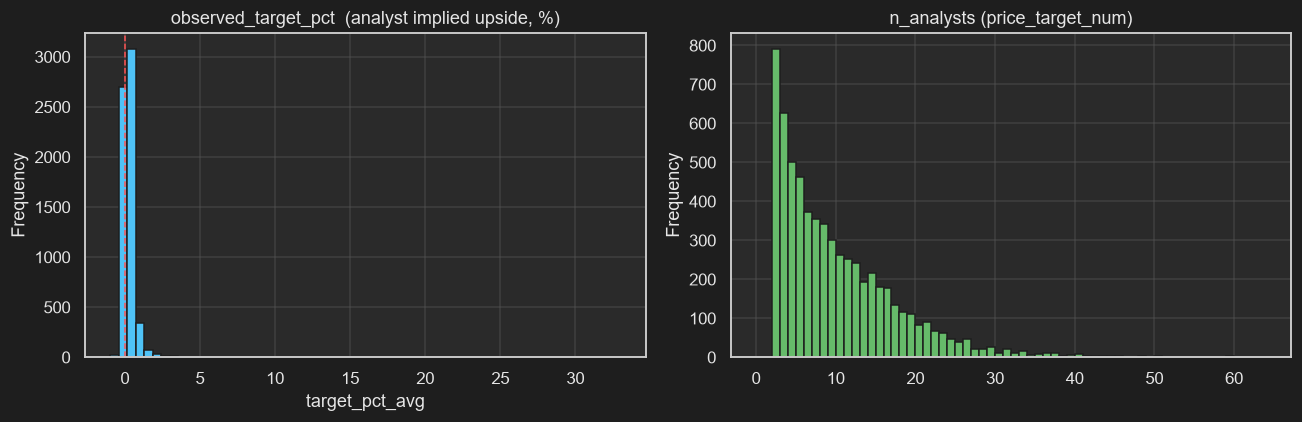

In [7]:
# 2.2 Response distribution: observed_target_pct + n_analysts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pt_df['observed_target_pct'].dropna().plot.hist(
    bins=60, ax=axes[0], edgecolor='#1e1e1e', color='#4FC3F7'
)
axes[0].axvline(0, color='#FF5252', ls='--', lw=1)
axes[0].set_title('observed_target_pct  (analyst implied upside, %)')
axes[0].set_xlabel('target_pct_avg')

n_analysts_s = pt_df['n_analysts'].dropna().astype(int)
n_analysts_s.plot.hist(bins=range(0, int(n_analysts_s.max()) + 2),
                       ax=axes[1], edgecolor='#1e1e1e', color='#66BB6A')
axes[1].set_title('n_analysts (price_target_num)')
plt.tight_layout()
plt.show()


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


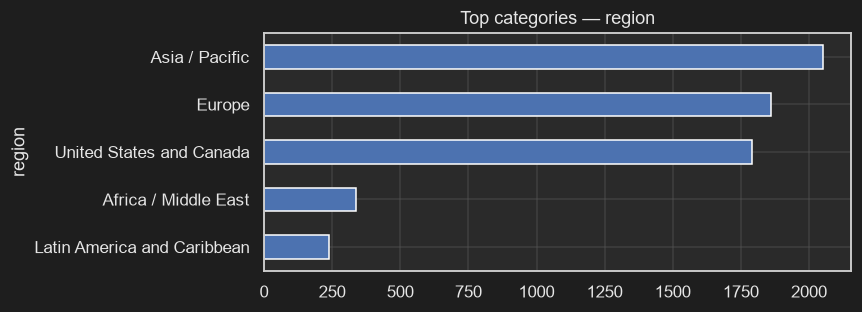

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


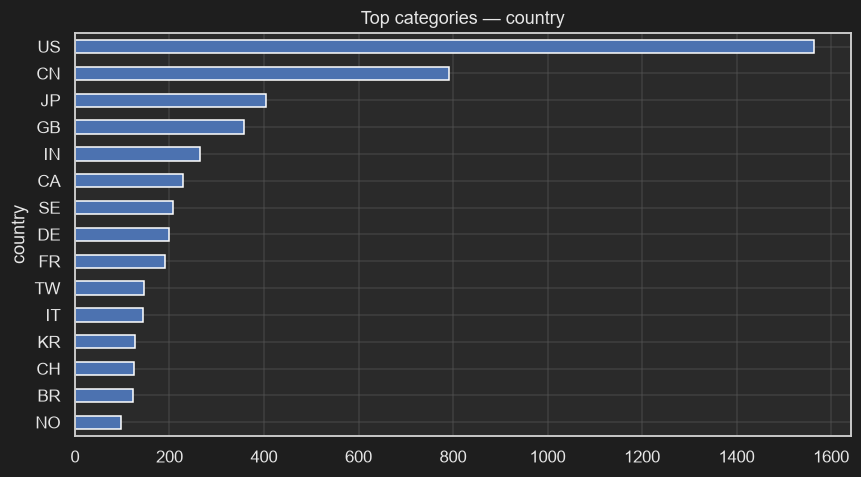

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


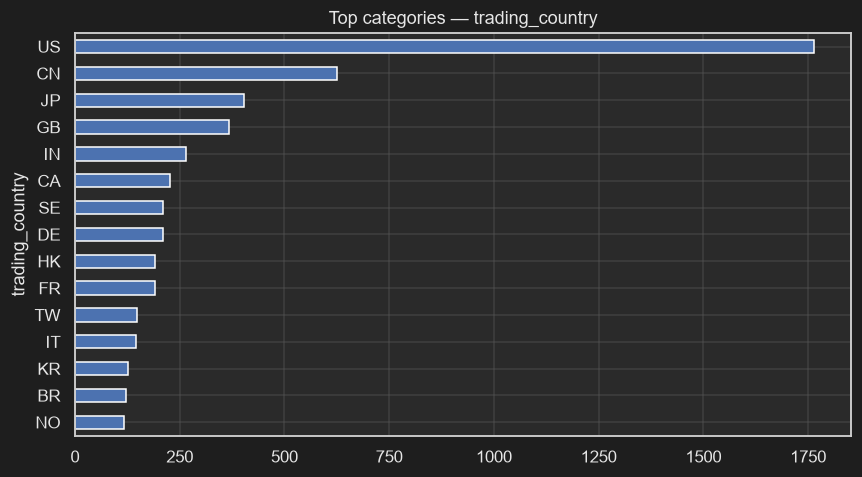

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


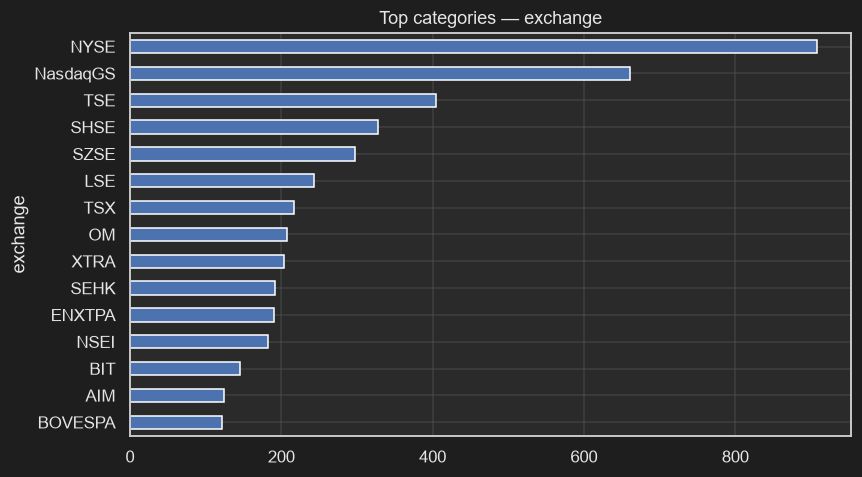

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


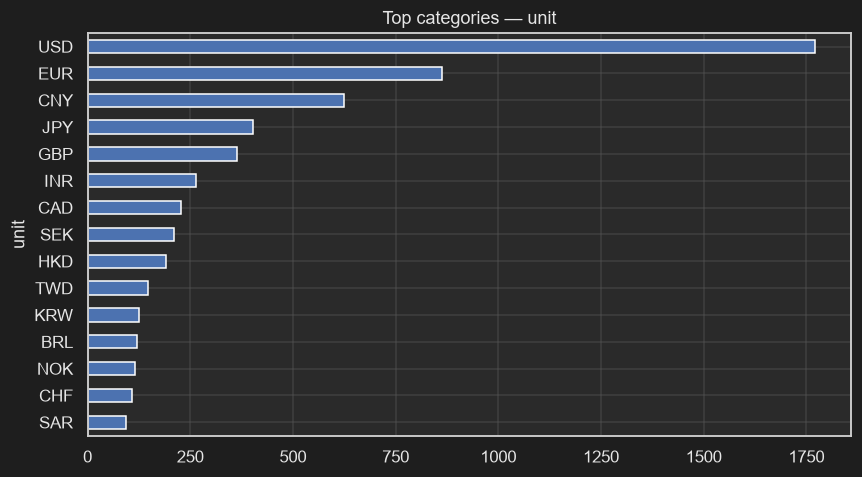

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


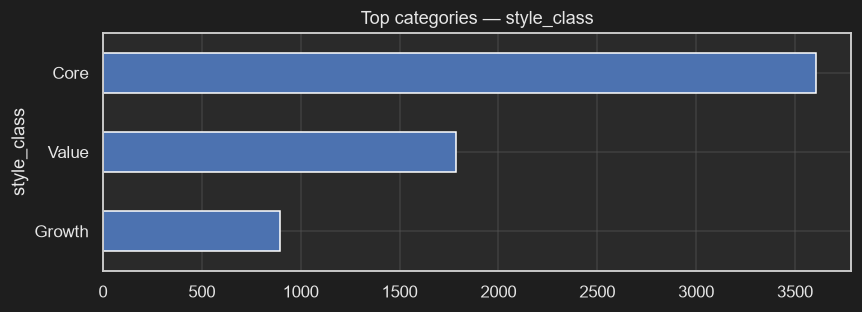

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


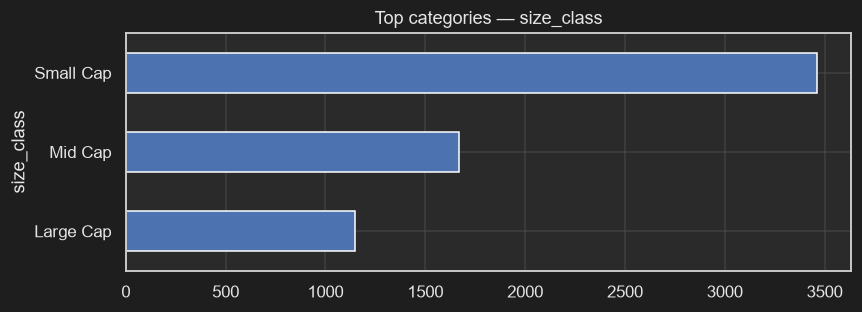

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


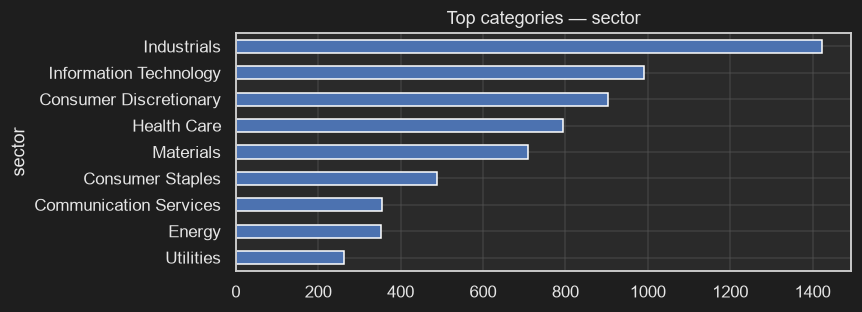

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


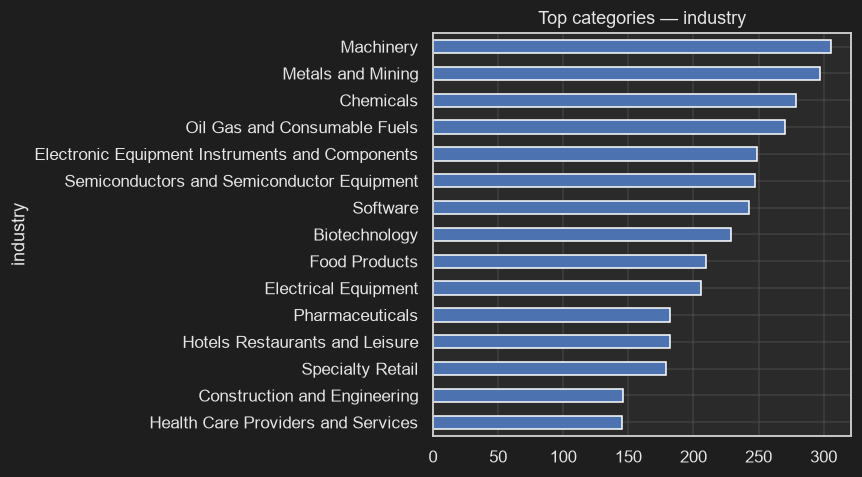

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1549629249.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


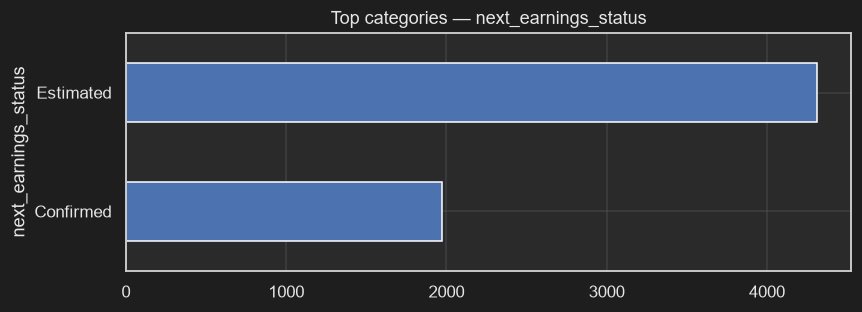

In [8]:
# 2.3 Classification coord cardinality (region / country / sector / industry / ...)
for col in CLASSIFICATION_COORDS:
    if col in ('isin', 'ticker', 'name'):
        continue
    counts = pt_df[col].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(counts))))
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top categories — {col}')
    plt.tight_layout()
    plt.show()


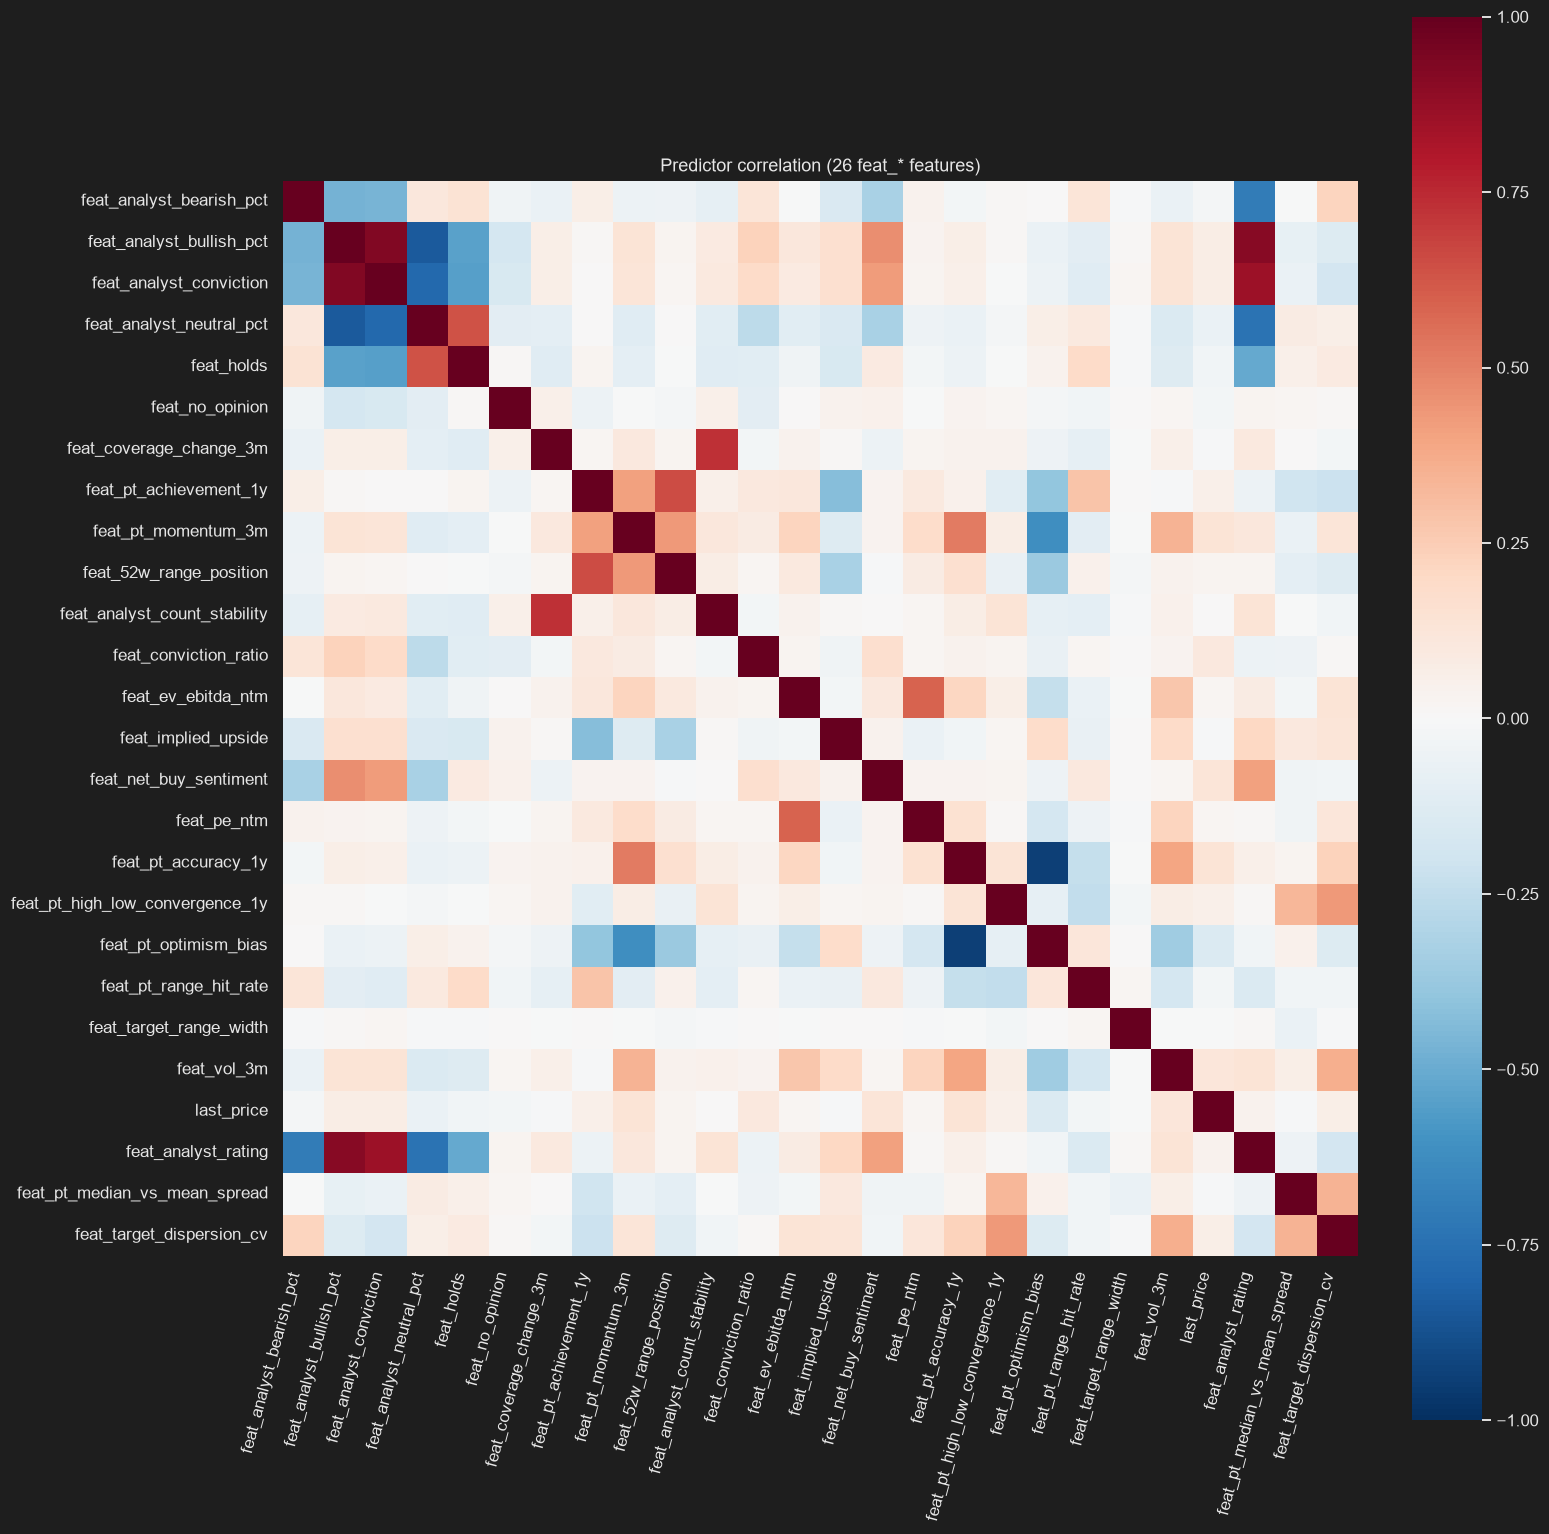

In [10]:
# 2.4 Predictor correlation heatmap (numeric predictors only)
num_predictors = [c for c in PREDICTOR_COLS
                  if pd.api.types.is_numeric_dtype(pt_df[c])]

if len(num_predictors) < 2:
    print(f'⚠️ Predictor correlation heatmap skipped — '
          f'only {len(num_predictors)} numeric predictor(s) available '
          f'(need ≥ 2). Check that `feature_catalogue` tags '
          f'`mutable_predictor` columns that actually exist in `pt_df`.')
else:
    corr = pt_df[num_predictors].corr(numeric_only=True)
    side = min(14, 0.4 * len(num_predictors) + 4)
    fig, ax = plt.subplots(figsize=(side, side))
    # Only render tick labels when the matrix is small enough to read them.
    show_labels = len(num_predictors) <= 30
    sns.heatmap(
        corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=show_labels, yticklabels=show_labels,
        square=True, ax=ax,
    )
    if show_labels:
        # Pin tick positions to a FixedLocator before relabelling so Matplotlib
        # does not warn about a mismatch between auto-located ticks and the
        # explicit labels we supply (robust to any variable number of features).
        x_locs = ax.get_xticks()
        x_labels = [t.get_text() for t in ax.get_xticklabels()]
        ax.set_xticks(x_locs)
        ax.set_xticklabels(x_labels, rotation=75, ha='right')

        y_locs = ax.get_yticks()
        y_labels = [t.get_text() for t in ax.get_yticklabels()]
        ax.set_yticks(y_locs)
        ax.set_yticklabels(y_labels, rotation=0, va='center')
    ax.set_title(f'Predictor correlation ({len(num_predictors)} feat_* features)')
    plt.show()


## 3. Summary Statistics by Feature Role

Statistics are grouped using `feature_catalogue.feature_role` (e.g. `predictor`, `target`, `categorical`) and `category` (e.g. `eps_revisions`, `fiscal_calendar`, `classification`). This mirrors the catalogue-driven approach used in `pymc_expected_returns_model.ipynb` §13 (catalogue-driven coverage check).


In [11]:
def summarize_by_role(df: pd.DataFrame, cat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-column statistics, joined with feature_catalogue metadata.

    The catalogue uses two identifiers:
      - ``column_name``   — source column in ``pml.pml_df``
      - ``feature_alias`` — MV/view alias actually exposed in ``pt_df``
        (populated from ``pml.pml_df_feature_alias`` per ``model_target``).

    Rows in ``pt_df`` are addressable by alias, so we resolve presence by
    alias first and fall back to ``column_name`` for catalogue rows that pass
    the source column through unchanged (most ``coord`` entries).
    """
    numeric_fields = ['mean', 'std', 'p05', 'median', 'p95', 'skew', 'kurt']

    # 1. Resolve, for each catalogue row, which df column (if any) backs it.
    has_alias = 'feature_alias' in cat.columns
    cat = cat.copy()
    cat['resolved_column'] = (
        cat['feature_alias'].where(has_alias and cat['feature_alias'].notna(),
                                   cat['column_name'])
        if has_alias else cat['column_name']
    )
    # Keep only rows whose resolved name exists in the dataframe, de-duplicated
    # (a single MV alias can be referenced by multiple source columns).
    resolved = (
        cat.loc[cat['resolved_column'].isin(df.columns)]
        .drop_duplicates(subset=['resolved_column'])
    )

    # 2. Per-column statistics keyed by the resolved (df-side) column name.
    rows = []
    for col in resolved['resolved_column']:
        s = df[col]
        rec = {
            'resolved_column': col,
            'dtype': str(s.dtype),
            'n': int(s.notna().sum()),
            'missing_pct': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
        }
        # Ensure numeric stat columns always exist (NaN for non-numeric dtypes)
        for f in numeric_fields:
            rec[f] = np.nan
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.5, 0.95])
            rec.update({
                'mean': float(desc['mean']),
                'std': float(desc['std']),
                'p05': float(desc['5%']),
                'median': float(desc['50%']),
                'p95': float(desc['95%']),
                'skew': float(s.skew(skipna=True)),
                'kurt': float(s.kurt(skipna=True)),
            })
        rows.append(rec)

    stats = pd.DataFrame(rows)

    # 3. Merge metadata back. Use ``resolved_column`` as the join key so every
    #    feature category (coord, mutable_predictor, constant_data, observed)
    #    keeps its catalogue annotations. Rename the catalogue's source
    #    ``column_name`` to ``source_column_name`` BEFORE the merge so it does
    #    not collide with the alias-based ``column_name`` we surface below.
    meta_cols = [c for c in
                 ['column_name', 'pymc_role', 'feature_role',
                  'feature_alias', 'category', 'data_type']
                 if c in cat.columns]
    meta_df = resolved[['resolved_column', *meta_cols]].rename(
        columns={'column_name': 'source_column_name'}
    )
    out = stats.merge(meta_df, on='resolved_column', how='left')

    # 4. Surface a stable ``column_name`` (= MV/df-side alias) for downstream
    #    code that filters pt_df by alias (e.g. the target box plot).
    out = out.rename(columns={'resolved_column': 'column_name'})

    # Reorder for readability
    leading = ['column_name', 'feature_alias', 'source_column_name',
               'pymc_role', 'feature_role',
               'category', 'data_type', 'dtype', 'n', 'missing_pct', 'n_unique']
    leading = [c for c in leading if c in out.columns]
    return out[leading + [c for c in out.columns if c not in leading]]


summary_stats = summarize_by_role(pt_df, catalogue)
summary_stats.head(50)


,column_name,feature_alias,source_column_name,pymc_role,feature_role,category,data_type,dtype,n,missing_pct,n_unique,mean,std,p05,median,p95,skew,kurt
0,n_analysts,n_analysts,price_target_num,constant_data,count,analyst_targets,double precision,int64,6281,0.000000,53,9.652444,7.546188,2.000000,8.000000,24.000000,1.585536,3.646730
1,country,country,country,coord,categorical,classification,text,str,6281,0.000000,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,exchange,exchange,exchange,coord,categorical,classification,text,str,6281,0.000000,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,industry,industry,industry,coord,categorical,classification,text,str,6281,0.000000,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,next_earnings_status,next_earnings_status,next_earnings_status,coord,categorical,fiscal_calendar,text,str,6281,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,next_earnings_when,next_earnings_when,next_earnings_when,coord,categorical,fiscal_calendar,text,str,6138,0.022767,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,region,region,region,coord,categorical,classification,text,str,6281,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sector,sector,sector,coord,categorical,classification,text,str,6281,0.000000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,size_class,size_class,size_class,coord,categorical,classification,text,str,6281,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,style_class,style_class,style_class,coord,categorical,classification,text,str,6281,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# 3.1 Roll-up by (pymc_role, feature_role, category)
rollup = (
    summary_stats
    .groupby(['pymc_role', 'category', 'feature_role'], dropna=False)
    .agg(
        n_columns=('feature_alias', 'size'),
        avg_missing_pct=('missing_pct', 'mean'),
        mean_of_means=('mean', 'mean'),
        mean_of_stds=('std', 'mean'),
    )
    .round(4)
    .reset_index()
    .sort_values(['pymc_role', 'category', 'feature_role'])
)
rollup


,pymc_role,category,feature_role,n_columns,avg_missing_pct,mean_of_means,mean_of_stds
0,constant_data,analyst_targets,count,1,0.0000,9.6524,7.5462
1,coord,classification,categorical,9,0.0000,NaN,NaN
2,coord,fiscal_calendar,categorical,2,0.0114,NaN,NaN
3,coord,fiscal_calendar,date,6,0.0020,NaN,NaN
4,mutable_predictor,analyst_ratings,count,6,0.0000,0.7805,0.8190
5,mutable_predictor,analyst_ratings,predictor,2,0.0000,3.1040,3.1826
6,mutable_predictor,analyst_ratings,score,1,0.0054,4.0847,0.6646
7,mutable_predictor,analyst_targets,historical,3,0.0146,0.3172,0.2367
8,mutable_predictor,analyst_targets,predictor,7,0.0190,0.4739,21.2962
9,mutable_predictor,analyst_targets,target,2,0.0000,0.0746,0.0823


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1166768636.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


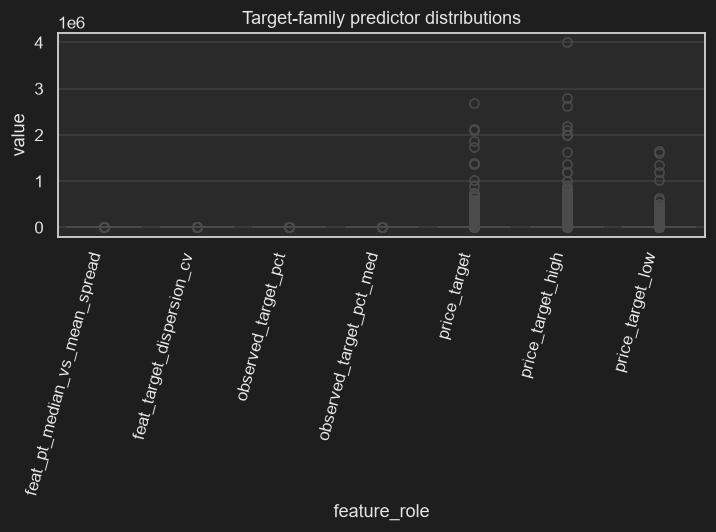

In [13]:
# 3.2 Visualise distribution of target-family predictors per category
#     Iterate feature_aliases for the 'target' feature_role and map them
#     onto pt_df columns (the MV exposes columns by feature_alias).
rev_aliases = (
    summary_stats.loc[summary_stats['feature_role'] == 'target',
    'feature_alias']
    .dropna()
    .unique()
    .tolist()
)
rev_cols = [a for a in rev_aliases if a in pt_df.columns
            and pd.api.types.is_numeric_dtype(pt_df[a])]
if rev_cols:
    melted = pt_df[rev_cols].melt(var_name='feature_role', value_name='value').dropna()
    fig, ax = plt.subplots(figsize=(min(14, 0.4 * len(rev_cols) + 4), 5))
    sns.boxplot(data=melted, x='feature_role', y='value', ax=ax, showfliers=True)

    # --- Option A: pin tick positions, then set labels (fully explicit) ---
    # Works for any variable number of categories. `ax.get_xticks()` returns
    # the locations seaborn used; passing them through FixedLocator-equivalent
    # `set_xticks` silences the warning.
    tick_locs = ax.get_xticks()
    tick_labels = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=75, ha='right')

    # --- Option B (equivalent, even shorter): rotate in place ---
    # plt.setp(ax.get_xticklabels(), rotation=75, ha='right')

    ax.set_title('Target-family predictor distributions')
    plt.tight_layout()
    plt.show()
else:
    print('No target-role predictors present in pt_df.')

## 4. Build PyMC-Aligned Data Containers

Cross-sectional hierarchical **Student-t** regression on `observed_target_pct`, schema-aligned with `PriceTargetAchievement`. One observation per ISIN; the heavy-tailed likelihood absorbs analyst-noise outliers and the per-ISIN scale is shrunk by `1 / sqrt(n_analysts)` so broadly-covered names carry more weight. `pm.Data` container names mirror `pml.mv_pymc_price_target` columns (and therefore `vw_pymc_feature_catalogue.feature_alias`) so `pm.set_data` round-trips against the live MV.

**Refactored from the previous fused MvGRW model.** The earlier `(isin, time, y_series)` Multivariate Gaussian Random Walk observed a *tiled* response (`Y = np.tile(snapshot, (1, T))`) across T fiscal anchors and D deterministically-related price-target columns — pseudo-replication that inflated the effective sample size and made PSIS-LOO / WAIC non-comparable. It also carried a per-observation `expected_return` latent that saturated the likelihood and blew up Pareto-k. **Both are removed:** the model now observes a single non-redundant response per ISIN, so the marginal posterior of `mu_isin` (on the `observed_target_pct` scale) and leave-one-out are reliable.

Hierarchical partial-pooling intercepts are attached to every available low-cardinality coord (`sector`, `industry`, `region`, `size_class`, `style_class`); each is registered as a `pm.Model` dimension and as a `pm.Data('<coord>_idx', …, dims='isin')` integer-index container. `risk_adj_return` is retained as a derived, on-scale screening output — it no longer drives the likelihood.

In [14]:
# 4.0  Filter rows with a usable response + build categorical coords.
DATE_COLS = [
    'income_statement_report_date',
    'next_earnings',
    'fy_end_date',
    'next_income_statement_report_date',
    'next_fy_end_date',
    'expected_report_date',
]
DAY_COUNT_COLS = [
    'days_to_next_earnings',
    'days_since_last_report',
    'days_to_next_fy_end',
    'days_to_next_report',
    'days_to_expected_report',
    'days_to_fy_end',
]

# Cast dates and drop rows missing the response or n_analysts.
for c in DATE_COLS:
    if c in pt_df.columns:
        pt_df[c] = pd.to_datetime(pt_df[c], errors='coerce')

model_df = pt_df.loc[
    pt_df['observed_target_pct'].notna()
    & pt_df['n_analysts'].fillna(0).gt(0)
    ].copy().reset_index(drop=True)
print(f'Modelling rows (response present & n_analysts>0): {len(model_df)}')

# ---------------------------------------------------------------------------
# Categorical coords: every column tagged `coord` in vw_pymc_feature_catalogue
# and present in pml.mv_pymc_price_target. Each becomes a model dimension with
# its own integer index array (`<coord>_idx`) and unique-label vector. These
# drive the hierarchical partial-pooling intercepts in §4.2.
# ---------------------------------------------------------------------------
isin_labels = model_df['isin'].astype(str).values

CATEGORICAL_COORDS = [c for c in COORD_COLS
                      if c in model_df.columns and c not in ('isin', 'ticker', 'name')]
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

coord_uniques = {}  # coord_name -> np.ndarray of unique labels
coord_idx = {}  # coord_name -> np.ndarray of int64 indices (len == n_obs)
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')

# Back-compat aliases (legacy downstream cells expect `sector_*` symbols).
sector_uniques = coord_uniques.get('sector')
sector_idx = coord_idx.get('sector')
sector_labels = model_df['sector'].fillna('Unknown').astype(str).values

# ---------------------------------------------------------------------------
# Single observed response (one row per ISIN). No tiling, no D-stacked
# y_series tensor: the previous (isin, time, y_series) MvGRW response was a
# broadcast of one cross-sectional snapshot across T fiscal anchors and D
# deterministically-related price-target columns — pseudo-replication that
# inflated the effective sample size and made LOO / WAIC non-comparable.
# ---------------------------------------------------------------------------
observed_target_pct = model_df['observed_target_pct'].astype('float64').to_numpy()
print(f'Observed response observed_target_pct: shape={observed_target_pct.shape}')

Modelling rows (response present & n_analysts>0): 6281
Categorical coords (17): ['country', 'exchange', 'industry', 'next_earnings_status', 'next_earnings_when', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit', 'expected_report_date', 'fy_end_date', 'income_statement_report_date', 'next_earnings', 'next_fy_end_date', 'next_income_statement_report_date']
Observed response observed_target_pct: shape=(6281,)


In [15]:
# 4.1  Predictor matrix — numeric feat_* with ≥70% coverage, capped at 8 features
num_pred_cols = [c for c in PREDICTOR_COLS if pd.api.types.is_numeric_dtype(model_df[c])]
# Force-include the new fiscal-calendar day-count predictors when present
for c in DAY_COUNT_COLS:
    if c in model_df.columns and c not in num_pred_cols:
        num_pred_cols.append(c)
# Force-include the new normalized analyst-sentiment predictors (pml-schema
# update). bullish/bearish %s are coverage-invariant directional signals; we
# omit neutral_pct (the residual of the other buckets) to avoid collinearity,
# and feat_analyst_conviction is consumed separately as the risk/dispersion
# latent in §4.2. These columns are tagged constant_data in the catalogue
# (multi-source carriers), so they are not in PREDICTOR_COLS and must be added
# explicitly here.
for c in ('feat_analyst_bullish_pct', 'feat_analyst_bearish_pct'):
    if c in model_df.columns and pd.api.types.is_numeric_dtype(model_df[c]) and c not in num_pred_cols:
        num_pred_cols.append(c)
coverage = model_df[num_pred_cols].notna().mean()
selected_predictors = coverage[coverage >= 0.70].sort_values(ascending=False).index.tolist()[:8]
print(f'Selected predictors ({len(selected_predictors)}): {selected_predictors}')

X_raw = model_df[selected_predictors].astype(float)
X_std = (X_raw - X_raw.mean()) / X_raw.std(ddof=0).replace(0, 1.0)
X = X_std.fillna(0.0).to_numpy()

# Response + precision-weight
y_target_pct = model_df['observed_target_pct'].astype(float).to_numpy()
n_analysts = model_df['n_analysts'].astype(int).clip(lower=1).to_numpy()
print(f'Predictor matrix X: shape={X.shape}')


Selected predictors (8): ['feat_analyst_bearish_pct', 'feat_analyst_bullish_pct', 'feat_analyst_conviction', 'feat_analyst_neutral_pct', 'feat_holds', 'feat_no_opinion', 'feat_implied_upside', 'feat_conviction_ratio']
Predictor matrix X: shape=(6281, 8)


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


§4.2 — cross-sectional model on 6281 ISINs; 8 predictors; group effects: ['region', 'unit', 'sector', 'industry', 'size_class', 'style_class']


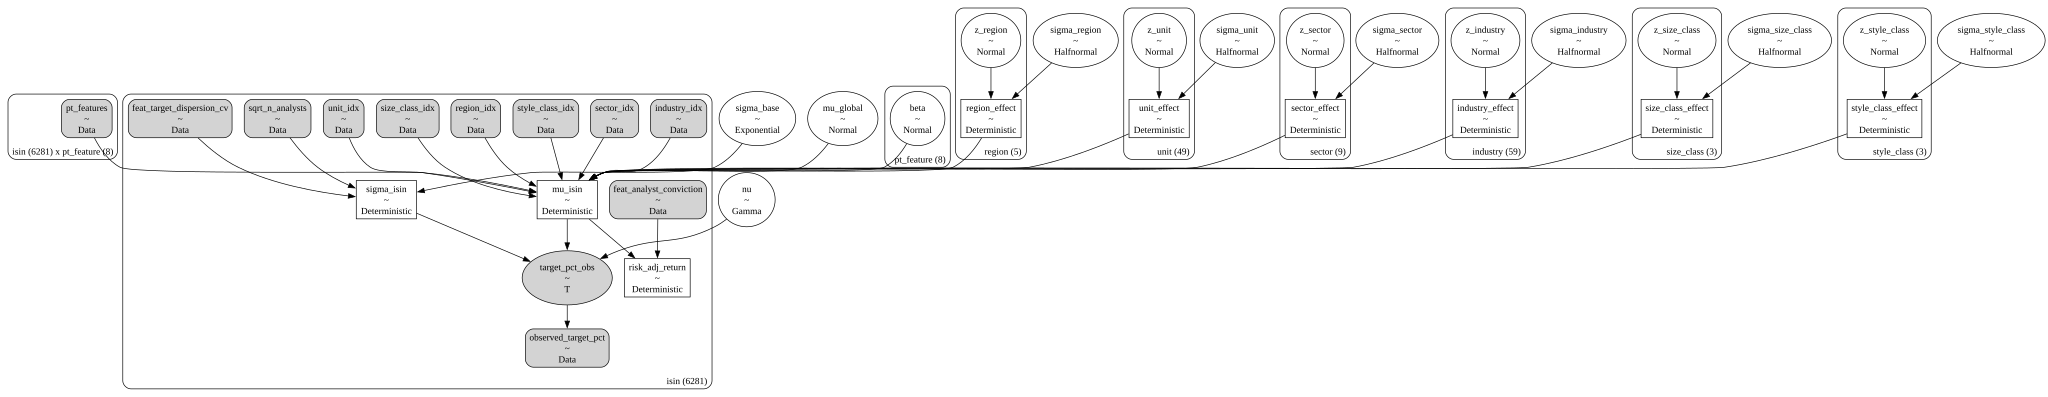

In [16]:
# 4.2  Cross-sectional price-target model — refactored fused builder.
#
# The previous fused model layered a 3-D MvGaussianRandomWalk on a TILED
# (isin, time, y_series) response tensor (Y = np.tile(snapshot, (1, T))) and a
# per-observation `expected_return` latent. Both are removed here:
#   * the tiling created T identical copies x D deterministically-related
#     series, inflating the effective sample size and making PSIS-LOO / WAIC
#     meaningless (the pointwise log-likelihood was dominated by duplicates);
#   * the per-observation latent saturated the likelihood (one free mean per
#     datum) and blew up Pareto-k.
# The refactored builder is a single-observation-per-ISIN hierarchical Student-t
# regression with multi-coord partial-pooling group effects. `mu_isin` is on
# the observed_target_pct scale (directly comparable); `risk_adj_return` is a
# derived, on-scale screening output (NOT the likelihood mean).
import numpy as np
import pymc as pm
import pytensor.tensor as pt

# Highest-signal, lowest-cardinality coords that receive a partial-pooling
# intercept, intersected with the coords actually present in the MV pull.
_CANDIDATE_GROUPS = ('region', 'sector', 'size_class', 'style_class', 'next_eanings_status')
GROUP_EFFECTS = [c for c in _CANDIDATE_GROUPS if c in coord_idx]

# Heteroscedastic-sigma / risk-adjustment inputs (one row per ISIN). The
# dispersion CV and conviction ratio are MV-native `feat_*` columns when
# present; otherwise they fall back to zeros (sigma then reduces to the
# analyst-count-weighted base, risk_adj_return to mu_isin).
n_analysts_xs = model_df['n_analysts'].astype('float64').clip(lower=1).to_numpy()
sqrt_n_xs = np.sqrt(n_analysts_xs)
cv_xs = (model_df['feat_target_dispersion_cv'].astype('float64').fillna(0.0).to_numpy()
         if 'feat_target_dispersion_cv' in model_df.columns
         else np.zeros(len(model_df)))
# `feat_analyst_conviction` is the MV-native 0-100 percentage |bullish% -
# bearish%|; rescale by 1/100 to a [0, 1] fraction so exp(-RISK_PENALTY *
# conviction) below stays on its tuned unit scale (a raw 0-100 value would
# collapse risk_adj_return to ~0 for high-conviction names).
conviction_xs = (model_df['feat_analyst_conviction'].astype('float64').div(100.0).fillna(0.0).to_numpy()
                 if 'feat_analyst_conviction' in model_df.columns
                 else np.zeros(len(model_df)))

RISK_PENALTY = 0.1


def build_fused_price_target_model(*, robust: bool = True) -> pm.Model:
    """Cross-sectional hierarchical Student-t price-target model (no MvGRW/tiling).

    One observation per ISIN on ``observed_target_pct``. The mean is a direct
    hierarchical regression with non-centred partial-pooling intercepts on each
    coord in ``GROUP_EFFECTS``; the scale is analyst-count-weighted and
    dispersion-driven. No per-observation latent, so the marginal posterior of
    ``mu_isin`` and PSIS-LOO are reliable.

    Parameters
    ----------
    robust : bool
        ``True`` -> heavy-tailed Student-t likelihood (default). ``False`` ->
        Normal-likelihood twin (differs ONLY in the observation distribution).
    """
    coords = {'isin': isin_labels, 'pt_feature': selected_predictors}
    for col in GROUP_EFFECTS:
        coords[col] = coord_uniques[col]

    with pm.Model(coords=coords) as model:
        Xd = pm.Data('pt_features', X, dims=('isin', 'pt_feature'))
        cvd = pm.Data('feat_target_dispersion_cv', cv_xs, dims='isin')
        convd = pm.Data('feat_analyst_conviction', conviction_xs, dims='isin')
        sqn = pm.Data('sqrt_n_analysts', sqrt_n_xs, dims='isin')
        obs = pm.Data('observed_target_pct', observed_target_pct, dims='isin')
        idx_data = {col: pm.Data(f'{col}_idx', coord_idx[col], dims='isin')
                    for col in GROUP_EFFECTS}

        # --- Mean: direct hierarchical regression (NO per-observation latent).
        mu_global = pm.Normal('mu_global', 0.0, 0.5)
        beta = pm.Normal('beta', 0.0, 0.25, dims='pt_feature')
        eta = mu_global + pt.dot(Xd, beta)
        for col in GROUP_EFFECTS:
            sigma_g = pm.HalfNormal(f'sigma_{col}', 0.25)
            z_g = pm.Normal(f'z_{col}', 0.0, 1.0, dims=col)
            group_effect = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
            eta = eta + group_effect[idx_data[col]]
        mu_isin = pm.Deterministic('mu_isin', eta, dims='isin')

        # --- Heteroscedastic, analyst-count-weighted scale.
        sigma_base = pm.Exponential('sigma_base', 1.0)  # no Abs->Sqrt inplace rewrite
        sigma_isin = pm.Deterministic('sigma_isin',
                                      sigma_base * (1.0 + cvd) / sqn, dims='isin')

        # --- Likelihood: robust Student-t by default; Normal twin optional.
        if robust:
            nu = pm.Gamma('nu', alpha=2.0, beta=0.1)
            pm.StudentT('target_pct_obs', nu=nu, mu=mu_isin, sigma=sigma_isin,
                        observed=obs, dims='isin')
        else:
            pm.Normal('target_pct_obs', mu=mu_isin, sigma=sigma_isin,
                      observed=obs, dims='isin')

        # --- Derived, on-scale risk-adjusted screening output.
        pm.Deterministic('risk_adj_return',
                         mu_isin * pt.exp(-RISK_PENALTY * convd), dims='isin')
    return model


price_target_model = build_fused_price_target_model(robust=True)
print(f'§4.2 — cross-sectional model on {len(observed_target_pct)} ISINs; '
      f'{len(selected_predictors)} predictors; group effects: {GROUP_EFFECTS}')
pm.model_to_graphviz(price_target_model)

## 5. Prior Predictive Checks

Sample from the prior to verify that priors imply a plausible distribution of analyst implied upside (`observed_target_pct`) centred near zero with heavy-tailed coverage of the empirical distribution.


In [17]:
# 5.0  Prior predictive — covers the cross-sectional hierarchical mean
# (mu_global, beta, group effects -> mu_isin), the heteroscedastic scale
# (sigma_base -> sigma_isin) and the likelihood degrees-of-freedom (nu).
_prior_var_names = [
    "mu_global", "beta", "mu_isin",
    *[f"sigma_{g}" for g in GROUP_EFFECTS],
    *[f"{g}_effect" for g in GROUP_EFFECTS],
    "sigma_base", "sigma_isin", "nu",
    "risk_adj_return", "target_pct_obs",
]
with price_target_model:
    prior_idata = pm.sample_prior_predictive(
        draws=2000,
        var_names=_prior_var_names,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )
prior_idata

Sampling: [beta, mu_global, nu, sigma_base, sigma_industry, sigma_region, sigma_sector, sigma_size_class, sigma_style_class, sigma_unit, target_pct_obs, z_industry, z_region, z_sector, z_size_class, z_style_class, z_unit]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:             (chain: 1, draw: 2000, pt_feature: 8, sector: 9,
│                                region: 5, isin: 6281, industry: 59, unit: 49,
│                                size_class: 3, style_class: 3)
│       Coordinates:
│         * chain               (chain) int64 8B 0
│         * draw                (draw) int64 16kB 0 1 2 3 4 ... 1995 1996 1997 1998 1999
│         * pt_feature          (pt_feature) <U24 768B 'feat_analyst_bearish_pct' ......
│         * sector              (sector) <U22 792B 'Communication Services' ... 'Util...
│         * region              (region) <U27 540B 'Africa / Middle East' ... 'United...
│         * isin                (isin) <U12 301kB 'US67066G1040' ... 'BRENJUACNOR9'
│         * industry            (industry) <U53 13kB 'Aerospace and Defense' ... 'Wir...
│         * unit                (unit) <U3 588B 'AED' 'ARS' 'AUD' ... 'USD' 'VND' 'ZAR'
│         * size_class          (size_class) <U9 108B 'Large Cap' 'Mid Cap' 'Small Cap'
│         * style_class         (style_class) <U6 72B 'Core' 'Growth' 'Value'
│       Data variables: (12/19)
│           beta                (chain, draw, pt_feature) float64 128kB 0.08931 ... -...
│           sigma_size_class    (chain, draw) float64 16kB 0.02709 0.1034 ... 0.03356
│           mu_global           (chain, draw) float64 16kB 0.5719 -0.0781 ... -0.07333
│           sector_effect       (chain, draw, sector) float64 144kB -0.2091 ... -0.00...
│           region_effect       (chain, draw, region) float64 80kB -0.1945 ... 0.07187
│           sigma_isin          (chain, draw, isin) float64 100MB 0.02882 ... 0.06787
│           ...                  ...
│           sigma_style_class   (chain, draw) float64 16kB 0.08583 0.4151 ... 0.2578
│           nu                  (chain, draw) float64 16kB 2.685 14.13 ... 14.53 17.46
│           sigma_industry      (chain, draw) float64 16kB 0.4497 0.444 ... 0.07783
│           risk_adj_return     (chain, draw, isin) float64 100MB 0.9728 ... 0.5909
│           sigma_sector        (chain, draw) float64 16kB 0.3464 0.1449 ... 0.354
│           style_class_effect  (chain, draw, style_class) float64 48kB -0.008619 ......
│       Attributes:
│           created_at:                 2026-06-15T00:24:45.189944+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:         (chain: 1, draw: 2000, isin: 6281)
│       Coordinates:
│         * chain           (chain) int64 8B 0
│         * draw            (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
│         * isin            (isin) <U12 301kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables:
│           target_pct_obs  (chain, draw, isin) float64 100MB 0.9679 1.019 ... 0.5992
│       Attributes:
│           created_at:                 2026-06-15T00:24:45.195022+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:         (isin: 6281)
│       Coordinates:
│         * isin            (isin) <U12 301kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables:
│           target_pct_obs  (isin) float64 50kB 0.4569 0.3298 0.2323 ... 2.073 0.7368
│       Attributes:
│           created_at:                 2026-06-15T00:24:45.197120+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           infe

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\3141953870.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


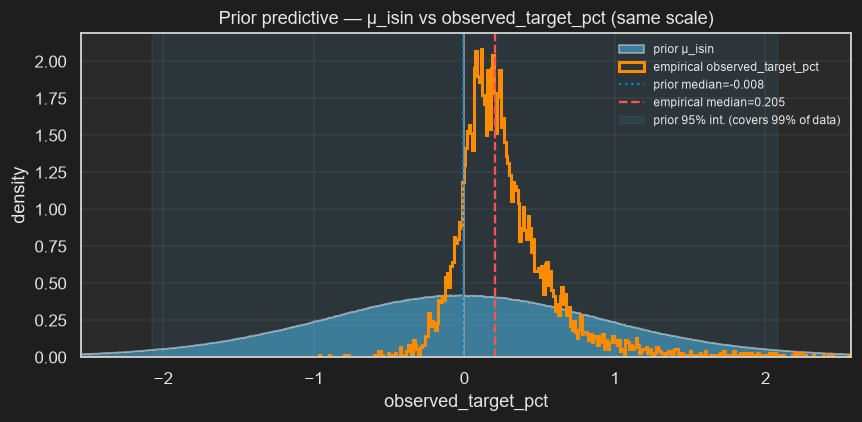

In [18]:
# 5.1  Prior on mu_isin vs empirical observed_target_pct.
# mu_isin is now on the SAME (observed_target_pct) scale as the data — no
# z-scaling needed — so the prior baseline and the empirical distribution are
# directly comparable.
empirical = model_df['observed_target_pct'].dropna().to_numpy()
prior_mu = prior_idata.prior['mu_isin'].values.reshape(-1)

# Shared, outlier-clipped bin edges so the two histograms are directly comparable.
lo, hi = np.percentile(np.concatenate([prior_mu, empirical]), [1, 99])
bin_edges = np.histogram_bin_edges(np.concatenate([prior_mu, empirical]),
                                   bins='auto', range=(lo, hi))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_mu, bins=bin_edges, density=True, histtype='stepfilled',
        alpha=0.5, color='#4FC3F7', label='prior μ_isin')
ax.hist(empirical, bins=bin_edges, density=True, histtype='step',
        lw=2, color='#FB8C00', label='empirical observed_target_pct')

ax.axvline(0, color='#9e9e9e', lw=1)
ax.axvline(np.median(prior_mu), color='#0288D1', ls=':',
           label=f'prior median={np.median(prior_mu):.3f}')
ax.axvline(np.median(empirical), color='#FF5252', ls='--',
           label=f'empirical median={np.median(empirical):.3f}')

# PPC coverage: share of empirical mass inside the prior's 95% interval.
p_lo, p_hi = np.percentile(prior_mu, [2.5, 97.5])
cover = np.mean((empirical >= p_lo) & (empirical <= p_hi))
ax.axvspan(p_lo, p_hi, color='#4FC3F7', alpha=0.08,
           label=f'prior 95% int. (covers {cover:.0%} of data)')

ax.set_xlim(lo, hi)
ax.set_title('Prior predictive — μ_isin vs observed_target_pct (same scale)')
ax.set_xlabel('observed_target_pct')
ax.set_ylabel('density')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\arviz_plots\plots\utils_ppc.py:68: UserWarning: This plot always uses the `observed_data` group.
Be cautious when using it for prior predictive checks.
  warn_if_prior_predictive(group)


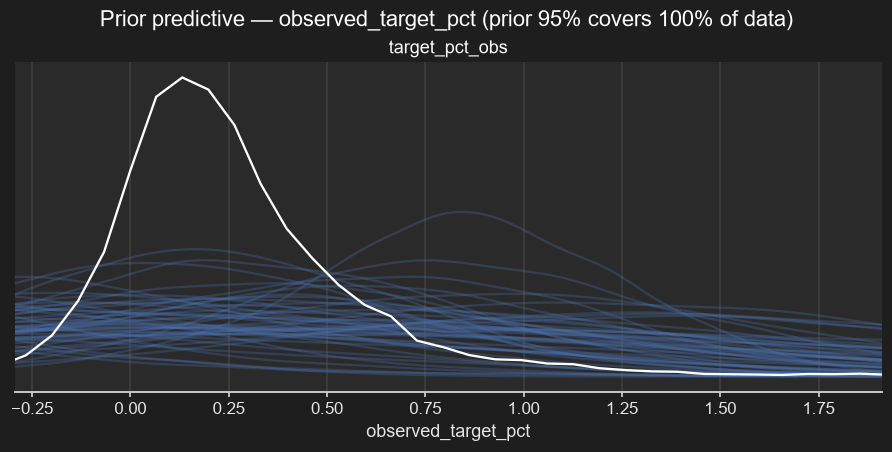

In [19]:
# 5.2  Prior predictive distribution of target_pct_obs vs the empirical data.
# Single `dims='isin'` response → one ECDF panel. We MUST opt into the observed
# overlay (plot_ppc_dist hides it by default for prior_predictive groups) so the
# check actually compares prior-predictive draws against the analyst data.
from arviz_plots import plot_ppc_dist

# Build layout/plot-collection options as a plain dict, then UNPACK with **.
# These are collected by plot_ppc_dist's variadic **pc_kwargs parameter.
ppc_layout = {
    "cols": "__variable__",
    "col_wrap": 1,
    "figure_kwargs": {"figsize": (8, 4)},
}

pc = plot_ppc_dist(
    prior_idata,
    group="prior_predictive",
    var_names=["target_pct_obs"],
    # Force the observed/empirical distribution overlay (hidden by default for
    # prior_predictive). The valid `visuals` keys for this arviz_plots version
    # are ('predictive_dist', 'observed_dist', 'title', 'remove_axis') — so the
    # overlay toggle is `observed_dist`, NOT `observed_data`.
    visuals={"observed_dist": True},
    **ppc_layout,  # NOT pc_kwargs=ppc_layout
)

# Focus the x-axis on the bulk; the Student-t prior predictive has heavy tails.
# Resolve the matplotlib Axes robustly from the figure the PlotCollection built
# (avoids the brittle `pc.viz["plot"].item()` lookup, whose node layout varies
# across arviz_plots versions / variable names).
emp = model_df["observed_target_pct"].dropna().to_numpy()
lo, hi = np.percentile(emp, [1, 99])

fig = pc.viz["figure"].item()
for ax in fig.axes:
    ax.set_xlim(lo, hi)
    ax.set_xlabel("observed_target_pct")

# Quantitative coverage verdict (consistent with §5.1).
pp = prior_idata.prior_predictive["target_pct_obs"].values.reshape(-1)
p_lo, p_hi = np.percentile(pp, [2.5, 97.5])
cover = np.mean((emp >= p_lo) & (emp <= p_hi))
pc.add_title(f"Prior predictive — observed_target_pct (prior 95% covers {cover:.0%} of data)")

pc.show()

## 6. Posterior Inference (NUTS)

Short NUTS run for notebook responsiveness — tune/draws can be increased for a production fit. The trace below feeds the posterior predictive checks and diagnostics in §7–§8.


In [20]:
# Sampler dispatch — nutpie → numpyro → pymc fallback. The cross-sectional
# hierarchical Student-t graph is supported by all three NUTS backends
# (nutpie/Rust, numpyro/JAX, PyMC pure-Python); we try them in priority order
# and fall back on the first that is installed and succeeds.
sample_kwargs = dict(
    draws=2000, tune=1000, chains=6, cores=3,
    target_accept=0.95, random_seed=RANDOM_SEED,
    progressbar=True, return_inferencedata=True,
    idata_kwargs={"log_likelihood": False},
)

# Probe sampler availability up-front so we don't waste time on samplers
# whose backends aren't installed (e.g. nutpie's Rust binary missing
# yields a bare FileNotFoundError that is hard to diagnose downstream).
import importlib.util as _ilu

_candidate_samplers = []
if _ilu.find_spec("nutpie") is not None:
    _candidate_samplers.append("nutpie")
if _ilu.find_spec("numpyro") is not None:
    _candidate_samplers.append("numpyro")
_candidate_samplers.append("pymc")  # always available — pure-Python NUTS
print(f"Available NUTS samplers (in priority order): {_candidate_samplers}")

sampling_errors = []
idata = None
for _sampler in _candidate_samplers:
    try:
        with price_target_model:
            idata = pm.sample(nuts_sampler=_sampler, **sample_kwargs)
        print(f"Sampled successfully with nuts_sampler={_sampler!r}.")
        break
    except Exception as e:  # pragma: no cover - environment-dependent fallback
        sampling_errors.append((_sampler, repr(e)))
        print(f"nuts_sampler={_sampler!r} failed: {e!r}")

if idata is None:
    raise RuntimeError(
        "All NUTS samplers failed:\n"
        + "\n".join(f"  - {s}: {err}" for s, err in sampling_errors)
    )

# Merge prior / prior_predictive groups into the posterior `idata` so the
# downstream PPC / diagnostic cells can read everything from one object.
from probabilistic_ml_model._pymc_arviz_compat import extend_datatree

idata = extend_datatree(idata, prior_idata)
idata

Available NUTS samplers (in priority order): ['nutpie', 'numpyro', 'pymc']


NUTS[nutpie]: [mu_global, beta, sigma_region, z_region, sigma_unit, z_unit, sigma_sector, z_sector, sigma_industry, z_industry, sigma_size_class, z_size_class, sigma_style_class, z_style_class, sigma_base, nu]


Output()

Sampled successfully with nuts_sampler='nutpie'.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:             (chain: 6, draw: 2000, pt_feature: 8, region: 5,
│                                unit: 49, sector: 9, industry: 59, size_class: 3,
│                                style_class: 3, isin: 6281)
│       Coordinates:
│         * chain               (chain) int64 48B 0 1 2 3 4 5
│         * draw                (draw) int64 16kB 0 1 2 3 4 ... 1995 1996 1997 1998 1999
│         * pt_feature          (pt_feature) object 64B 'feat_analyst_bearish_pct' .....
│         * region              (region) object 40B 'Africa / Middle East' ... 'Unite...
│         * unit                (unit) object 392B 'AED' 'ARS' 'AUD' ... 'VND' 'ZAR'
│         * sector              (sector) object 72B 'Communication Services' ... 'Uti...
│         * industry            (industry) object 472B 'Aerospace and Defense' ... 'W...
│         * size_class          (size_class) object 24B 'Large Cap' ... 'Small Cap'
│         * style_class         (style_class) object 24B 'Core' 'Growth' 'Value'
│         * isin                (isin) object 50kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables: (12/25)
│           mu_global           (chain, draw) float64 96kB 0.2096 0.2096 ... 0.07542
│           beta                (chain, draw, pt_feature) float64 768kB -1.38e-06 ......
│           z_region            (chain, draw, region) float64 480kB 0.1901 ... 0.7002
│           z_unit              (chain, draw, unit) float64 5MB 1.188 -1.189 ... 0.4199
│           z_sector            (chain, draw, sector) float64 864kB -0.4278 ... 0.4037
│           z_industry          (chain, draw, industry) float64 6MB -1.995 ... -0.4425
│           ...                  ...
│           industry_effect     (chain, draw, industry) float64 6MB -5.053e-06 ... -0...
│           size_class_effect   (chain, draw, size_class) float64 288kB 0.0807 ... -0...
│           style_class_effect  (chain, draw, style_class) float64 288kB 0.03763 ... ...
│           mu_isin             (chain, draw, isin) float64 603MB 0.4569 ... 0.7369
│           sigma_isin          (chain, draw, isin) float64 603MB 1.095e-05 ... 6.045...
│           risk_adj_return     (chain, draw, isin) float64 603MB 0.4564 ... 0.7369
│       Attributes:
│           created_at:                 2026-06-15T00:43:27.669806+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              1100.7568616867065
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                   (chain: 6, draw: 2000)
│       Coordinates:
│         * chain                     (chain) int64 48B 0 1 2 3 4 5
│         * draw                      (draw) int64 16kB 0 1 2 3 ... 1996 1997 1998 1999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 96kB 8 8 8 8 ... 10 10 10 10
│           maxdepth_reached          (chain, draw) bool 12kB False False ... True True
│           step_size                 (chain, draw) float64 96kB 0.0177 ... 0.009602
│           transformation_update_id  (chain, draw) int64 96kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 96kB 0.01781 ... 0.00959
│           mean_tree_accept          (chain, draw) float64 96kB 0.9863 ... 0.9946
│           ...                        ...
│           fisher_distance           (chain, draw) float64 96kB 2.3e+04 ... 6.09e+06
│           transformation_index      (chain, draw) int64 96kB 848 848 848 ... 847 847
│           diverging                 (chain, draw) bool 12kB False False ... False
│           divergence_draw           (chain, draw) uint64 96kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object

Sampling: [target_pct_obs]


Output()

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1642937396.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


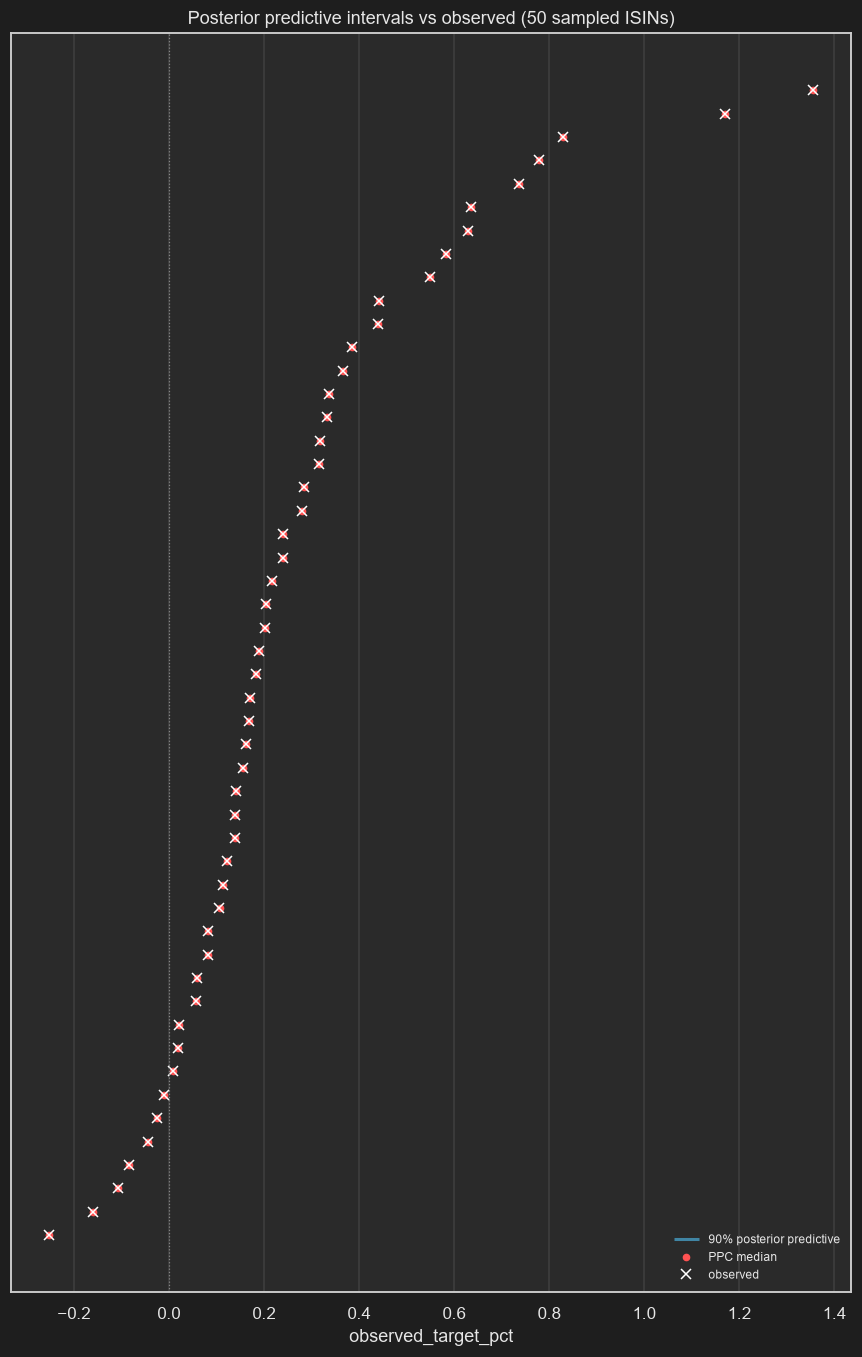

90% posterior-predictive interval empirical coverage: 91.6%


In [21]:
# 6.3  Posterior predictive vs observed (cross-sectional calibration).
# With a single response per ISIN we check calibration directly: per-ISIN
# posterior-predictive 90% interval + median against the observed value for a
# random subset, plus the empirical coverage of the 90% interval over ALL ISINs.
with price_target_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True,
        random_seed=RANDOM_SEED, progressbar=True,
    )

_ppc = idata.posterior_predictive['target_pct_obs'].stack(sample=('chain', 'draw'))
_med = _ppc.median('sample').values  # (isin,)
_q05 = _ppc.quantile(0.05, 'sample').values
_q95 = _ppc.quantile(0.95, 'sample').values
_obs = observed_target_pct

# Random subset of ISINs, ordered by predictive median for a readable strip.
_n_show = min(50, len(_obs))
_sel = rng.choice(len(_obs), size=_n_show, replace=False)
_sel = _sel[np.argsort(_med[_sel])]
ypos = np.arange(_n_show)

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * _n_show)))
ax.hlines(ypos, _q05[_sel], _q95[_sel], color='#4FC3F7', alpha=0.6, lw=2,
          label='90% posterior predictive')
ax.plot(_med[_sel], ypos, 'o', color='#FF5252', ms=4, label='PPC median')
ax.plot(_obs[_sel], ypos, 'x', color='#FFFFFF', ms=6, label='observed')
ax.axvline(0, color='#888', ls=':', lw=0.8)
ax.set_yticks([])
ax.set_xlabel('observed_target_pct')
ax.set_title(f'Posterior predictive intervals vs observed ({_n_show} sampled ISINs)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Calibration diagnostic: a well-specified model covers ~90% of observations.
_cover = float(np.mean((_obs >= _q05) & (_obs <= _q95)))
print(f'90% posterior-predictive interval empirical coverage: {_cover:.1%}')

## 7. Posterior Predictive Checks

Compare the predictive distribution of `observed_target_pct` (analyst implied upside) against the observed sample. A well-calibrated Student-t regression should cover the empirical density including its tails.


Sampling: [target_pct_obs]


Output()

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\2727927695.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


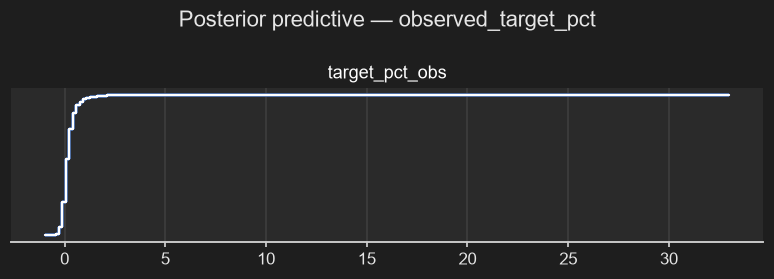

In [22]:
with price_target_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=False,
        random_seed=RANDOM_SEED, progressbar=True,
    )

from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    idata,
    group="posterior_predictive",
    var_names=["target_pct_obs"],
    kind="ecdf",
    num_samples=1000,
)
plt.suptitle("Posterior predictive — observed_target_pct")
plt.tight_layout()
plt.show()


In [23]:
# 7.1 Posterior sector-mean μ vs empirical sector target_pct_avg
import pandas as pd

sector_agg = (
    model_df.groupby('sector', as_index=False)
    .agg(empirical_target_pct=('observed_target_pct', 'mean'),
         n_obs=('isin', 'size'))
    .sort_values('sector').reset_index(drop=True)
)

# Note: the model defines the hierarchical sector intercept as
# pm.Deterministic('sector_effect', sigma_sector * z_sector, dims='sector').
# There is no 'alpha_sector' variable in idata.posterior.
post_sector_effect = (
    idata.posterior['sector_effect']
    .mean(dim=('chain', 'draw'))
    .to_pandas()
    .rename('posterior_sector_effect')
    .reset_index()
)

by_sector = sector_agg.merge(post_sector_effect, on='sector', how='left')
print(by_sector)


                   sector  empirical_target_pct  n_obs  \
0  Communication Services              0.289553    356   
1  Consumer Discretionary              0.327022    904   
2        Consumer Staples              0.242433    489   
3                  Energy              0.255136    352   
4             Health Care              0.512342    795   
5             Industrials              0.266288   1423   
6  Information Technology              0.211843    990   
7               Materials              0.271426    709   
8               Utilities              0.142030    263   

   posterior_sector_effect  
0                -0.013806  
1                -0.015283  
2                -0.012922  
3                -0.017741  
4                -0.014005  
5                -0.008573  
6                -0.009449  
7                -0.009653  
8                -0.012262  


## 8. MCMC Diagnostics

Convergence and sampler health: R-hat, ESS, divergences, trace plots, forest plot of predictor coefficients, and an ECDF of `p` — aligned with the ArviZ 1.0 diagnostic suite used in `probabilistic_ml_model.visualizations.arviz_diagnostics`.


In [24]:
# 8.1  R-hat / ESS summary across the cross-sectional parameter set.
# `requested` covers:
#   - cross-sectional baseline:   mu_global, beta
#   - hierarchical group effects:  sigma_<coord>, <coord>_effect for each coord
#   - likelihood scale / d.o.f.:   sigma_base, nu
posterior = idata.posterior
requested = ['mu_global', 'beta', 'sigma_base', 'nu']
for _grp in GROUP_EFFECTS:
    requested.extend([f'sigma_{_grp}', f'{_grp}_effect'])

available, skipped = [], []
for v in requested:
    if v not in posterior.data_vars:
        skipped.append((v, 'not in posterior'))
        continue
    da = posterior[v]
    non_sample_sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
    if any(s == 0 for s in non_sample_sizes):
        skipped.append((v, f'empty dim(s): {dict(da.sizes)}'))
        continue
    available.append(v)

if skipped:
    print('Skipping variables:')
    for name, reason in skipped:
        print(f'  - {name}: {reason}')

if not available:
    raise RuntimeError('No non-empty variables to summarise.')

summary = azs.summary(idata, var_names=available, round_to=4)
summary.sort_values('r_hat', ascending=False).head(50)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sector_effect[Utilities],-0.0123,0.0636,-0.1171,0.0672,6.2849,7.3573,5.0357,0.0259,0.0116
sector_effect[Communication Services],-0.0138,0.0629,-0.1171,0.0679,6.2968,7.3572,4.9251,0.0256,0.0117
region_effect[Asia / Pacific],-0.0078,0.0746,-0.1421,0.1172,6.3450,7.3537,4.5067,0.0304,0.0212
region_effect[Europe],-0.0078,0.0746,-0.1421,0.1172,6.3448,7.3540,4.5067,0.0304,0.0212
region_effect[Latin America and Caribbean],-0.0078,0.0746,-0.1421,0.1172,6.3445,7.3539,4.5062,0.0304,0.0212
region_effect[United States and Canada],-0.0078,0.0746,-0.1421,0.1172,6.3448,7.3537,4.5058,0.0304,0.0212
region_effect[Africa / Middle East],-0.0078,0.0746,-0.1421,0.1172,6.3447,7.3537,4.5051,0.0304,0.0212
sigma_sector,0.1759,0.0743,0.0846,0.2854,6.3551,7.3539,4.5038,0.0303,0.0106
sector_effect[Health Care],-0.0140,0.0618,-0.1171,0.0555,6.5425,8.6249,4.3439,0.0252,0.0114
sigma_style_class,0.1145,0.0887,0.0000,0.2638,6.3889,7.3842,4.3149,0.0361,0.0181


In [25]:
# 8.2  Divergences and aggregated R-hat / ESS.
# Per-variable max/min avoids the broadcast that a full to_array() would
# trigger over the per-coord group-effect dims.
n_div = int(idata.sample_stats['diverging'].sum())


def _non_empty_vars(ds):
    keep = []
    for name, da in ds.data_vars.items():
        sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
        if all(s > 0 for s in sizes):
            keep.append(name)
    return keep


posterior_tree = idata.posterior
posterior = posterior_tree.dataset if hasattr(posterior_tree, "dataset") else posterior_tree.to_dataset()

keep_vars = _non_empty_vars(posterior)
rhat_ds = azs.rhat(posterior[keep_vars])
ess_ds = azs.ess(posterior[keep_vars], method='bulk')

max_rhat = float(max(float(rhat_ds[v].max()) for v in rhat_ds.data_vars))
min_ess = float(min(float(ess_ds[v].min()) for v in ess_ds.data_vars))

# Surface the worst-offending hierarchical group-effect scales specifically:
# non-centred sigma_<coord> are the most prone to funnel pathologies.
_grp_keys = [f'sigma_{g}' for g in GROUP_EFFECTS if f'sigma_{g}' in rhat_ds.data_vars]
_grp_report = {v: (float(rhat_ds[v].max()), float(ess_ds[v].min()))
               for v in _grp_keys}

print(f'Divergences: {n_div}')
print(f'Max R-hat:   {max_rhat:.4f}')
print(f'Min ESS:     {min_ess:.1f}')
if _grp_report:
    print('Group-effect scale diagnostics (max R-hat, min ESS):')
    for v, (r, e) in _grp_report.items():
        print(f'  - {v:>20s}: r_hat={r:.3f}, ess_bulk={e:.1f}')

Divergences: 0
Max R-hat:   5.0357
Min ESS:     6.3
Group-effect scale diagnostics (max R-hat, min ESS):
  -         sigma_region: r_hat=3.319, ess_bulk=6.8
  -           sigma_unit: r_hat=1.407, ess_bulk=12.4
  -         sigma_sector: r_hat=4.504, ess_bulk=6.4
  -       sigma_industry: r_hat=1.780, ess_bulk=8.9
  -     sigma_size_class: r_hat=4.039, ess_bulk=6.5
  -    sigma_style_class: r_hat=4.315, ess_bulk=6.4


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\2996310766.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


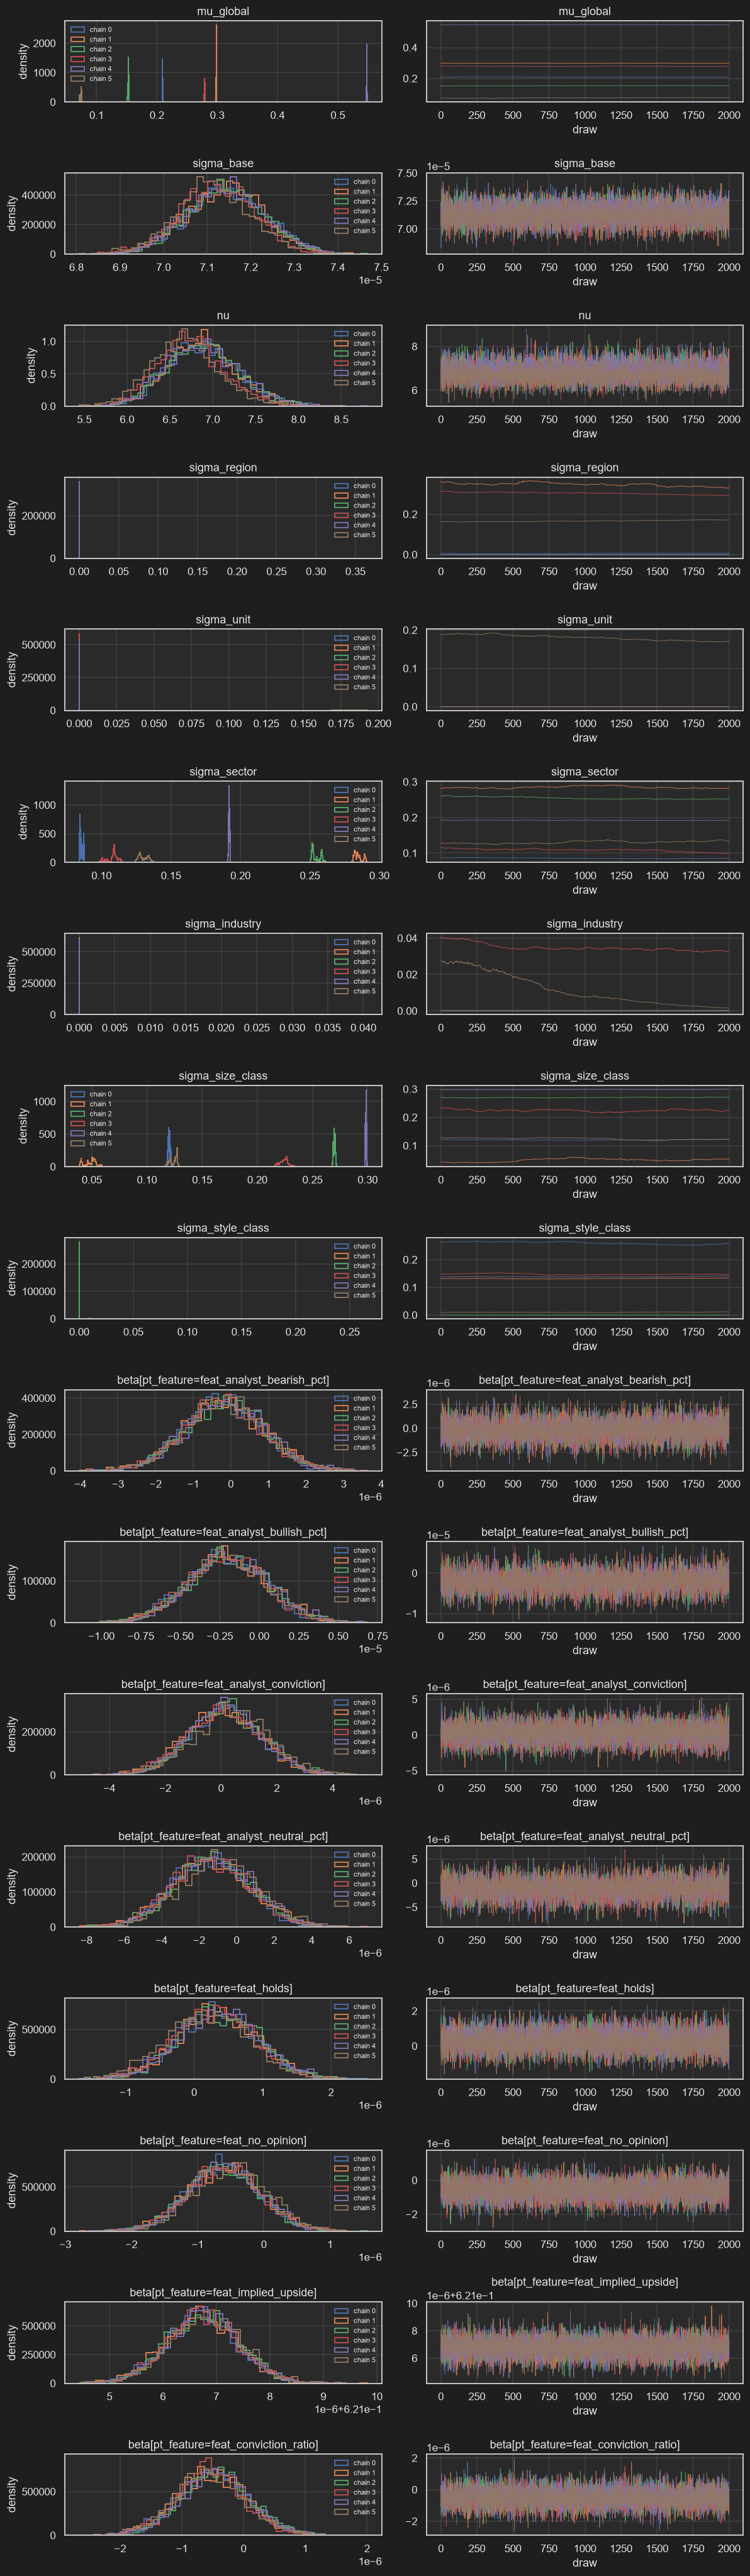

In [26]:
# 8.3  Trace + density plots for the key parameters (manual, backend-agnostic).
# Covers the cross-sectional baseline (mu_global, beta), the likelihood
# scale / d.o.f. (sigma_base, nu) and every hierarchical group-effect scale
# (sigma_<coord>). Per-coord `<coord>_effect` vectors are summarised in the
# §8.5 forest plot rather than blown up into one trace panel each.
import numpy as np
import matplotlib.pyplot as plt

_group_scale_vars = tuple(f'sigma_{g}' for g in GROUP_EFFECTS)

trace_vars = [v for v in (
    'mu_global', 'sigma_base', 'nu',
    *_group_scale_vars,
    'beta',
) if v in available]


def _iter_param_slices(da):
    """Yield (label_suffix, 2D array of shape (chain, draw)) for each scalar
    slice of a posterior DataArray. Works for scalar params (no extra dims),
    vector params (one extra dim, e.g. 'sector', 'pt_feature'), and matrix
    params (multiple extra dims)."""
    extra_dims = [d for d in da.dims if d not in ('chain', 'draw')]
    if not extra_dims:
        yield '', da.values
        return
    stacked = da.stack(_extra=extra_dims)
    for i in range(stacked.sizes['_extra']):
        sl = stacked.isel(_extra=i)
        coord_bits = []
        for d in extra_dims:
            val = sl.coords[d].values.item() if d in sl.coords else i
            coord_bits.append(f"{d}={val}")
        yield '[' + ', '.join(coord_bits) + ']', sl.values  # (chain, draw)


if trace_vars:
    posterior = idata.posterior
    rows = []
    for v in trace_vars:
        if v not in posterior:
            continue
        da = posterior[v]
        if any(da.sizes[d] == 0 for d in da.dims):
            continue
        for suffix, arr in _iter_param_slices(da):
            rows.append((f"{v}{suffix}", arr))

    if not rows:
        print('No non-empty posterior variables to plot.')
    else:
        n = len(rows)
        fig, axes = plt.subplots(n, 2, figsize=(11, 2.2 * n), squeeze=False)
        for i, (label, arr) in enumerate(rows):
            ax_density, ax_trace = axes[i, 0], axes[i, 1]
            n_chains = arr.shape[0]
            for c in range(n_chains):
                vals = arr[c]
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                ax_density.hist(vals, bins=40, density=True,
                                histtype='step', linewidth=1.2,
                                label=f'chain {c}')
            ax_density.set_title(label)
            ax_density.set_ylabel('density')
            if n_chains > 1:
                ax_density.legend(fontsize=7, loc='best')
            for c in range(n_chains):
                ax_trace.plot(arr[c], linewidth=0.6, alpha=0.85,
                              label=f'chain {c}')
            ax_trace.set_title(label)
            ax_trace.set_xlabel('draw')
        plt.tight_layout()
        plt.show()
else:
    print('No trace-eligible variables available.')

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\1120337363.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


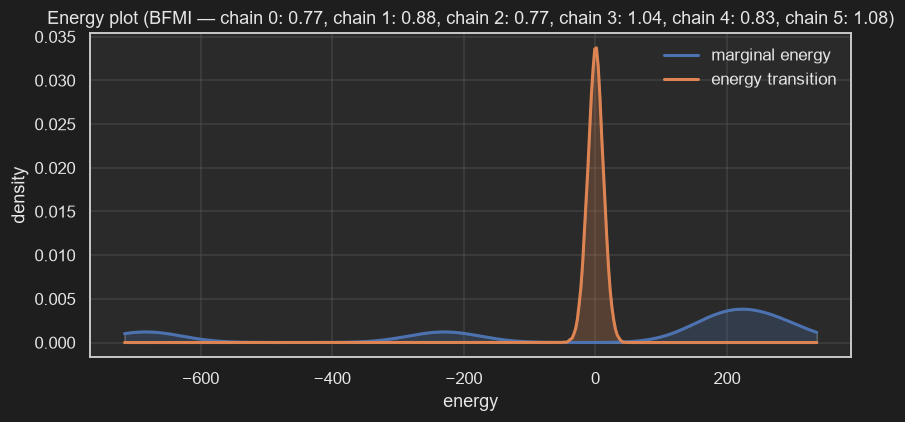

In [27]:
# 8.4 Energy plot (NUTS health) — single execution path, model-agnostic.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Robustly get groups for both InferenceData and DataTree
_groups_attr = getattr(idata, "groups", None)
if callable(_groups_attr):
    _groups = _groups_attr()  # classic arviz.InferenceData
else:
    _groups = tuple(_groups_attr) if _groups_attr is not None else ()  # xarray.DataTree

# DataTree group names start with '/', InferenceData uses plain names — normalize:
_group_names = {g.lstrip("/").split("/")[-1] for g in _groups}

if "sample_stats" in _group_names and "energy" in idata.sample_stats.data_vars:
    energy = idata.sample_stats["energy"]
    extra_dims = [d for d in energy.dims if d not in ("chain", "draw")]
    if extra_dims:
        energy = energy.mean(dim=extra_dims)  # collapse stray dims safely
    e = energy.values  # shape (chain, draw)

    marginal = (e - e.mean()).ravel()
    transition = np.diff(e, axis=1).ravel()
    transition = transition - transition.mean() + marginal.mean()

    # BFMI per chain (Betancourt 2016). Values < 0.3 typically indicate the
    # sampler is struggling — e.g. a poorly-identified hierarchical scale
    # (sigma_<coord>) inducing a funnel.
    bfmi = np.array([
        np.sum(np.diff(e[c]) ** 2) / np.sum((e[c] - e[c].mean()) ** 2)
        for c in range(e.shape[0])
    ])

    fig, ax = plt.subplots(figsize=(8, 4))
    grid = np.linspace(min(marginal.min(), transition.min()),
                       max(marginal.max(), transition.max()), 400)

    kde_m = gaussian_kde(marginal)
    kde_t = gaussian_kde(transition)
    ax.plot(grid, kde_m(grid), label="marginal energy", lw=2)
    ax.plot(grid, kde_t(grid), label="energy transition", lw=2)
    ax.fill_between(grid, kde_m(grid), alpha=0.25)
    ax.fill_between(grid, kde_t(grid), alpha=0.25)

    bfmi_str = ", ".join(f"chain {i}: {b:.2f}" for i, b in enumerate(bfmi))
    ax.set_title(f"Energy plot (BFMI — {bfmi_str})")
    ax.set_xlabel("energy")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("sample_stats.energy not available — skipping energy plot.")


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\3024935443.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


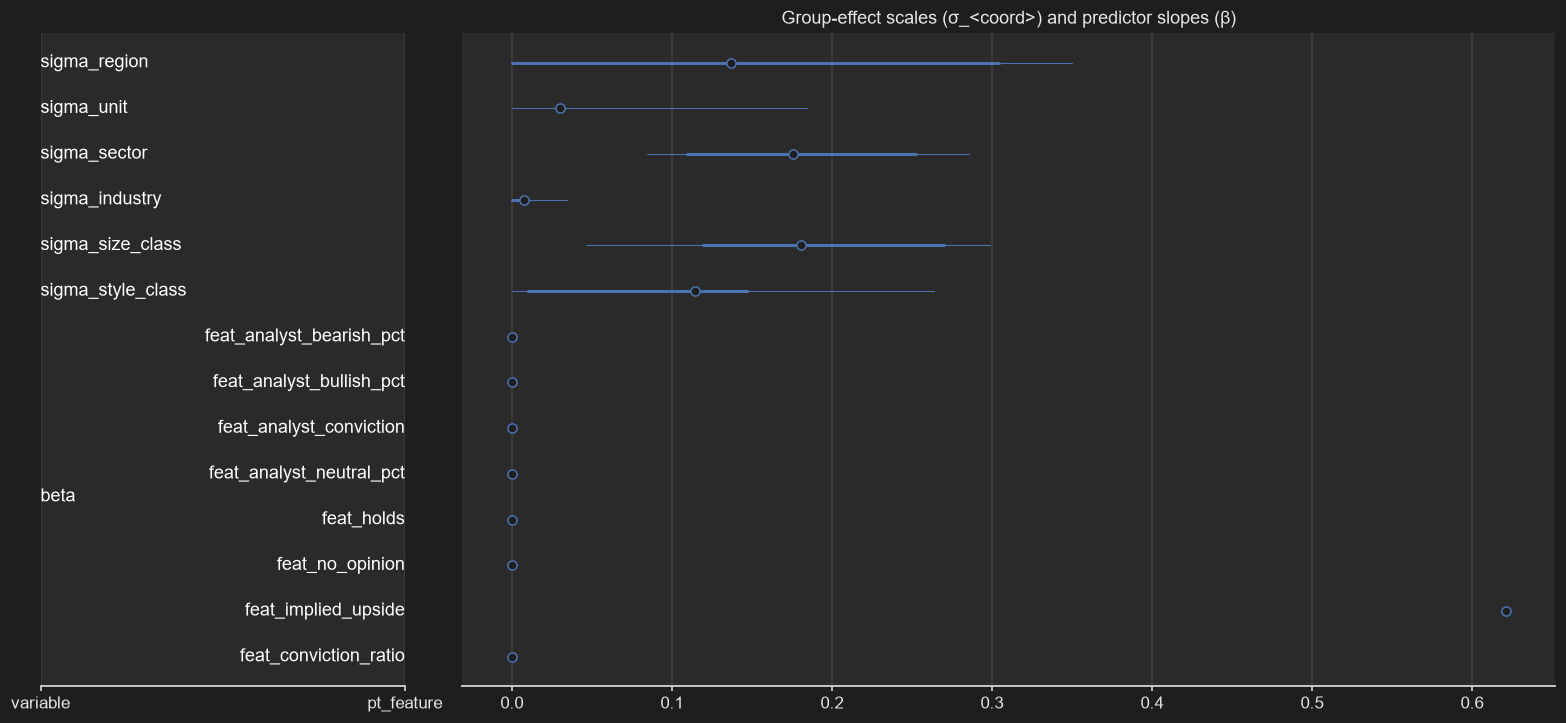

In [28]:
# 8.5  Forest plot of the hierarchical group-effect scales and predictor slopes.
# A wider `sigma_<coord>` means that coordinate (sector / industry / region /
# size_class / style_class) explains more cross-sectional dispersion in the
# analyst implied upside; the `beta` panel shows the standardised-predictor
# slopes. Replaces the previous diagonal-GRW innovation-scale forest.
import arviz_plots as azp

_forest_vars = [f'sigma_{g}' for g in GROUP_EFFECTS
                if f'sigma_{g}' in idata.posterior.data_vars]
_forest_vars += [v for v in ('beta',) if v in idata.posterior.data_vars]

if _forest_vars:
    azp.plot_forest(
        idata,
        var_names=_forest_vars,
        combined=True,
    )
    plt.title('Group-effect scales (σ_<coord>) and predictor slopes (β)')
    plt.tight_layout()
    plt.show()
else:
    print('No group-effect / beta variables in posterior — skipped.')

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


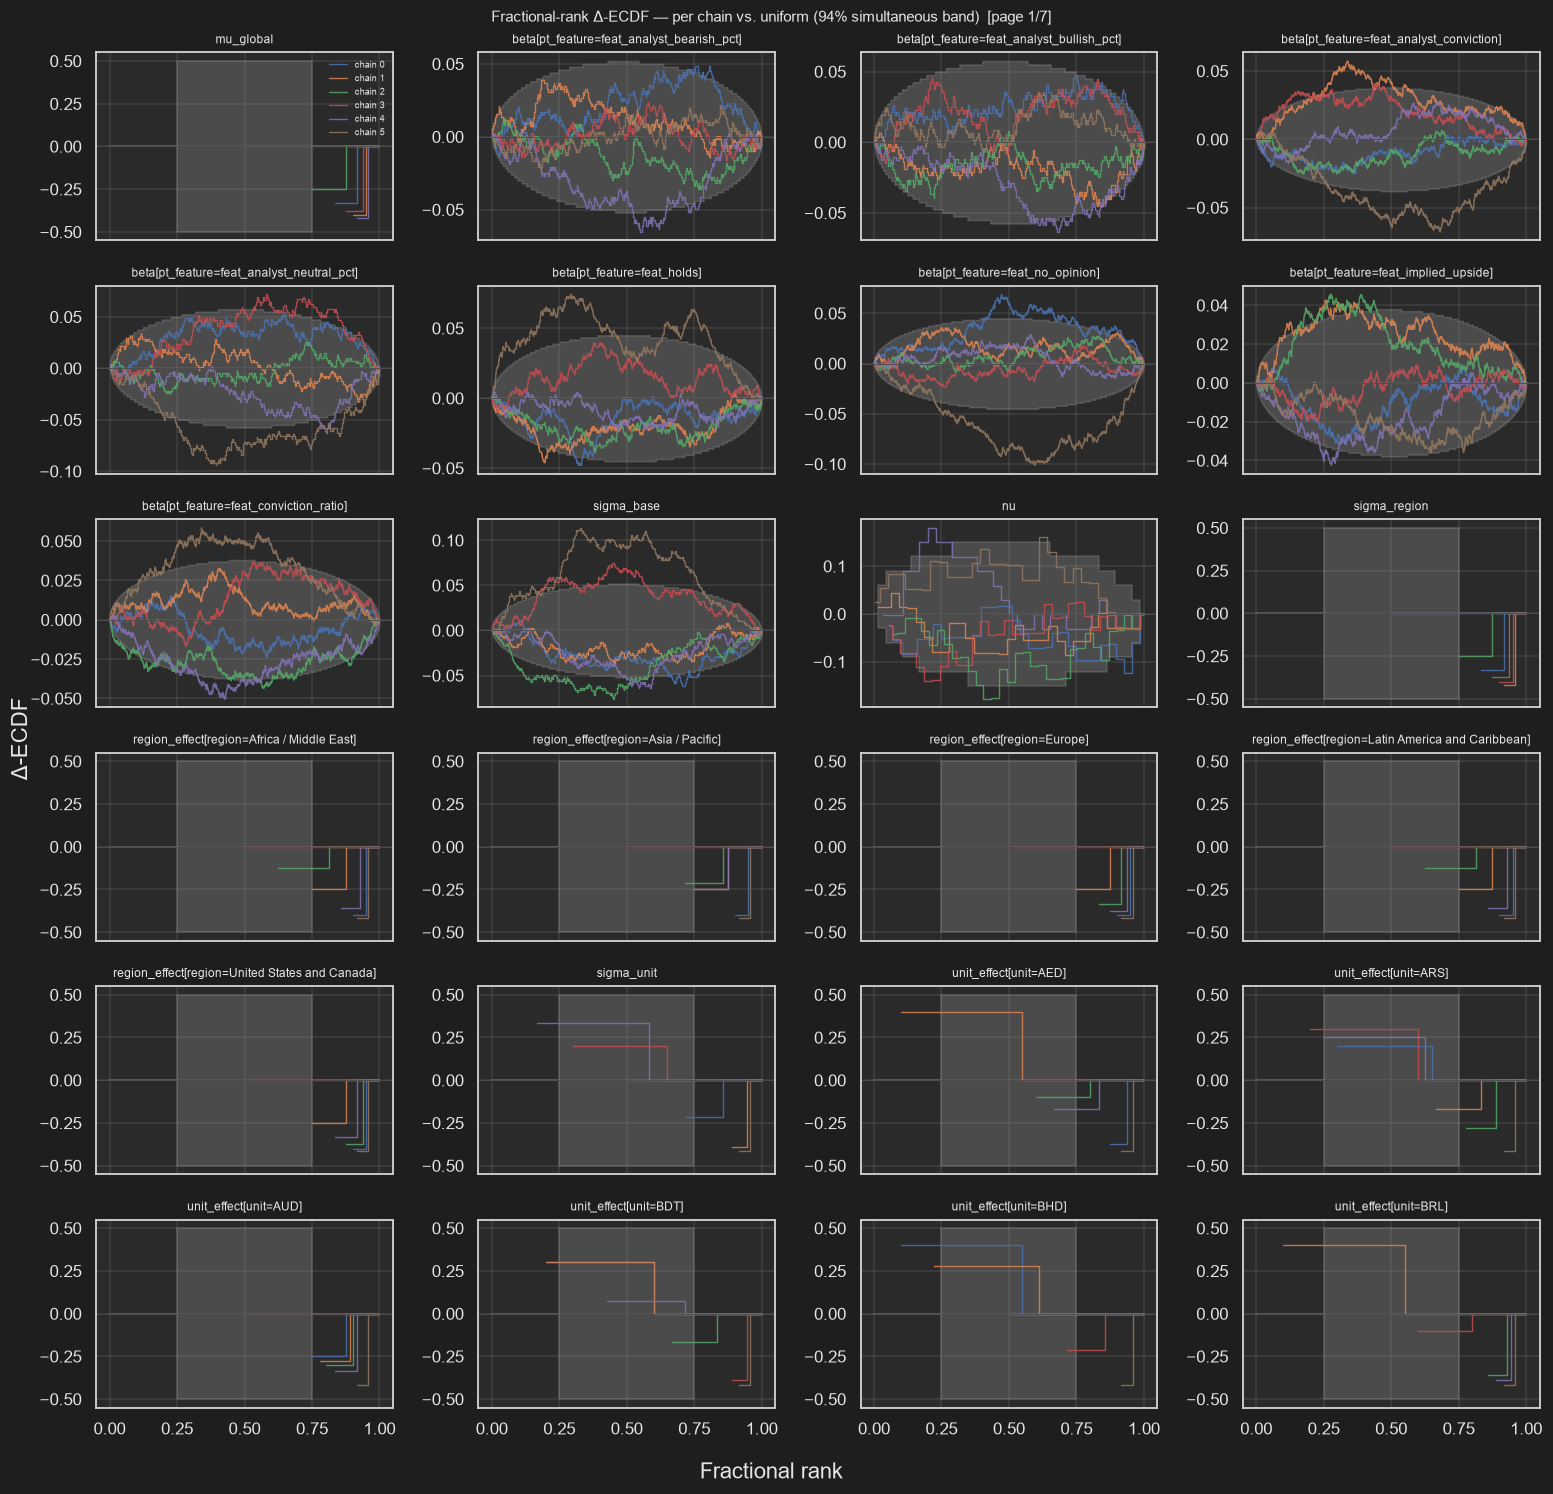

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


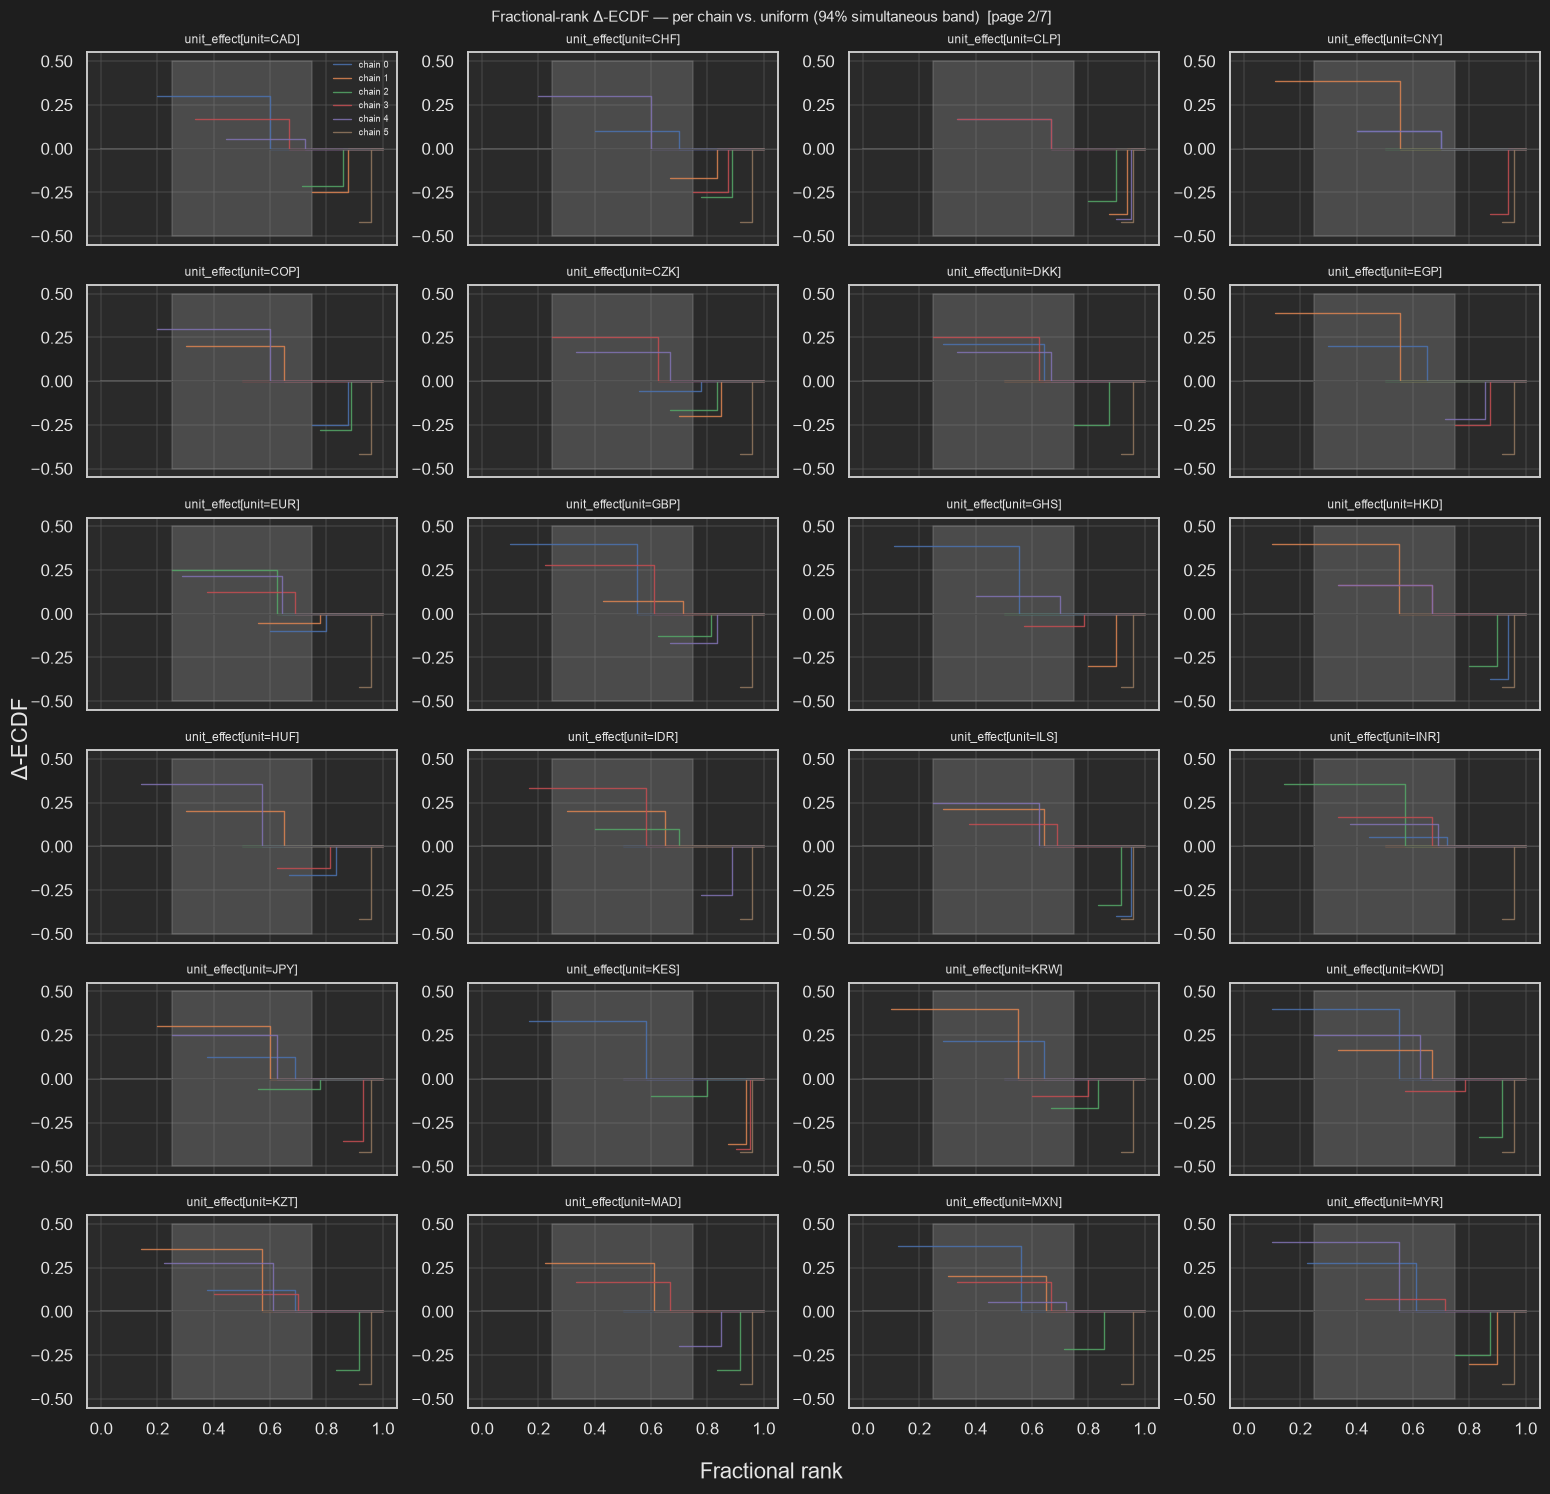

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


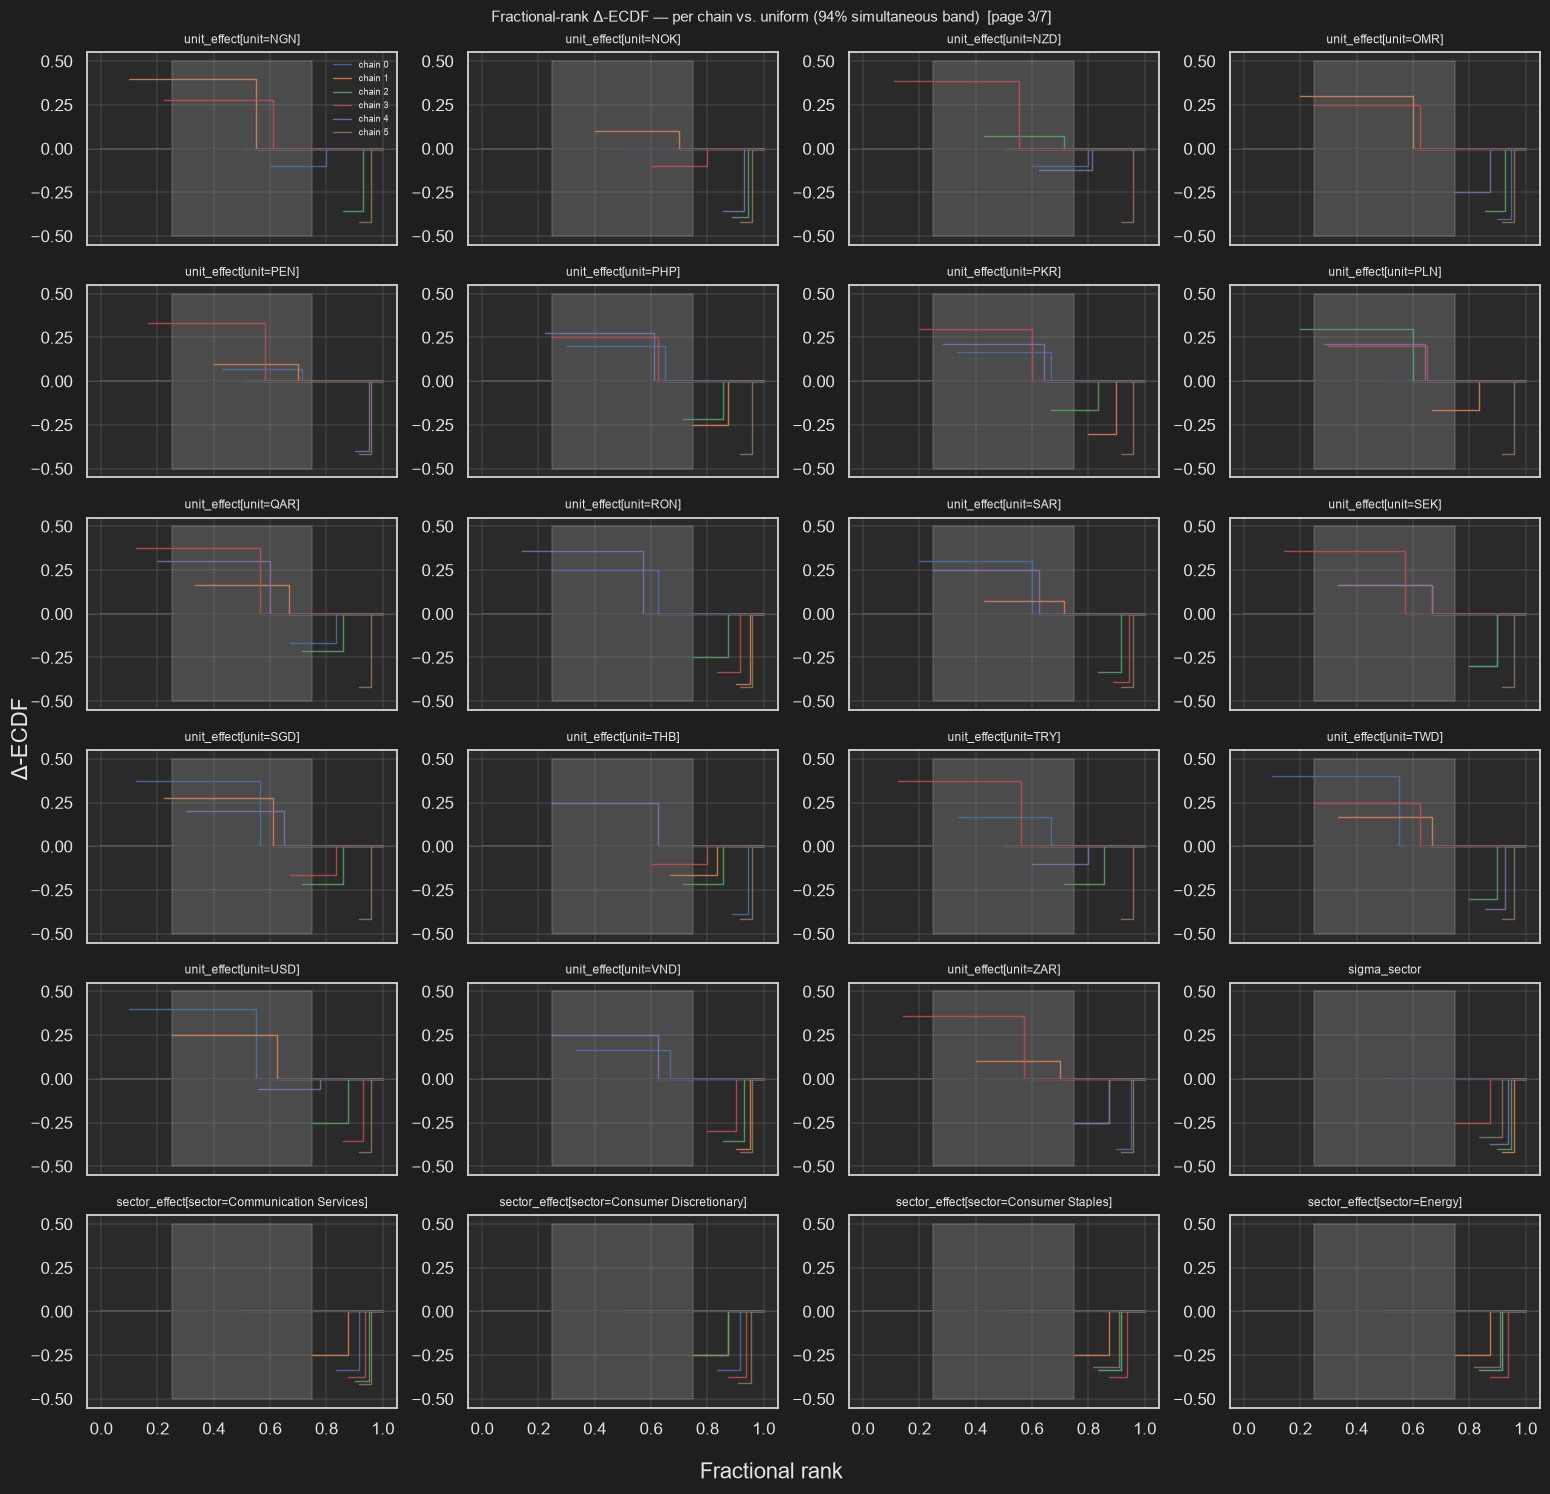

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


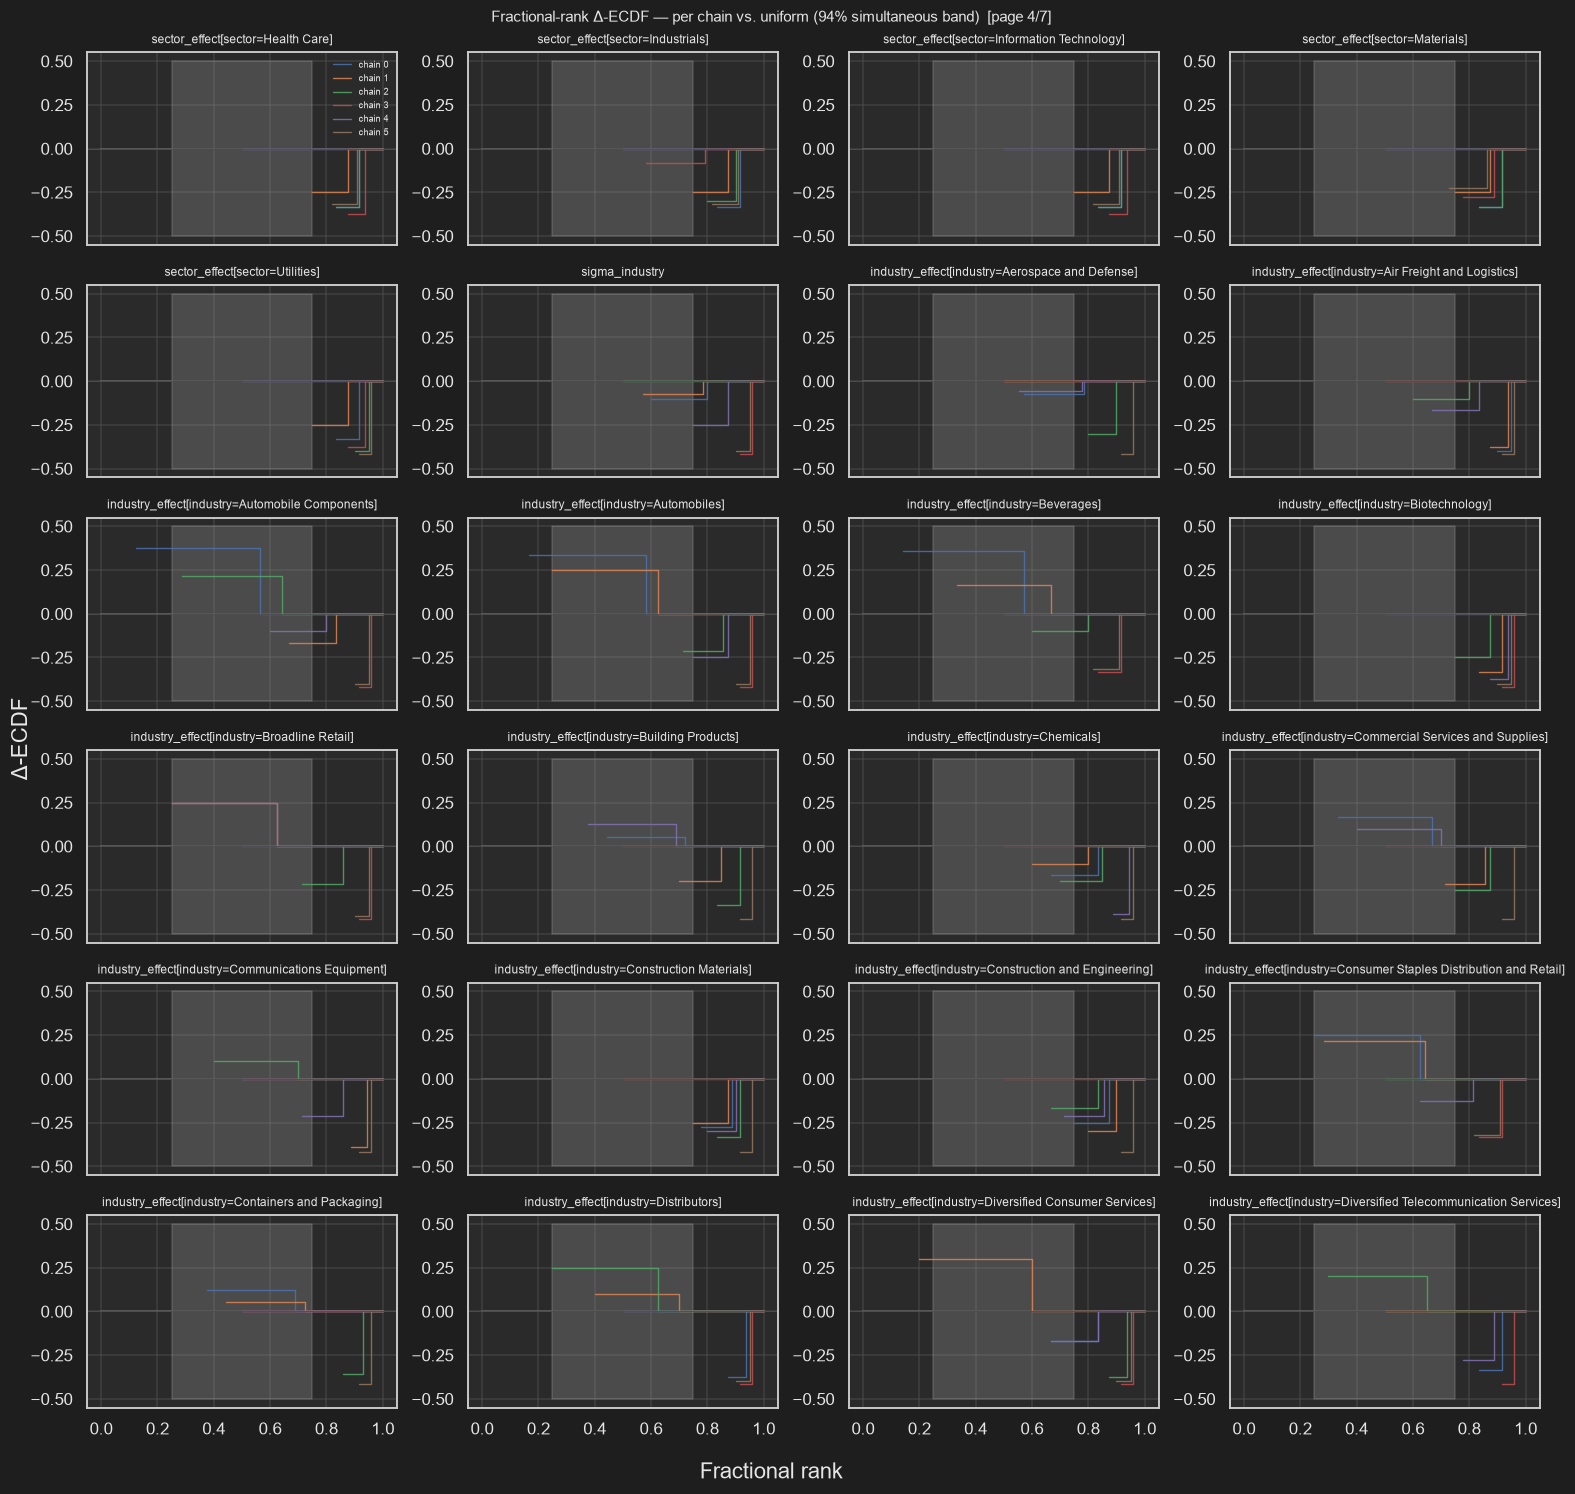

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


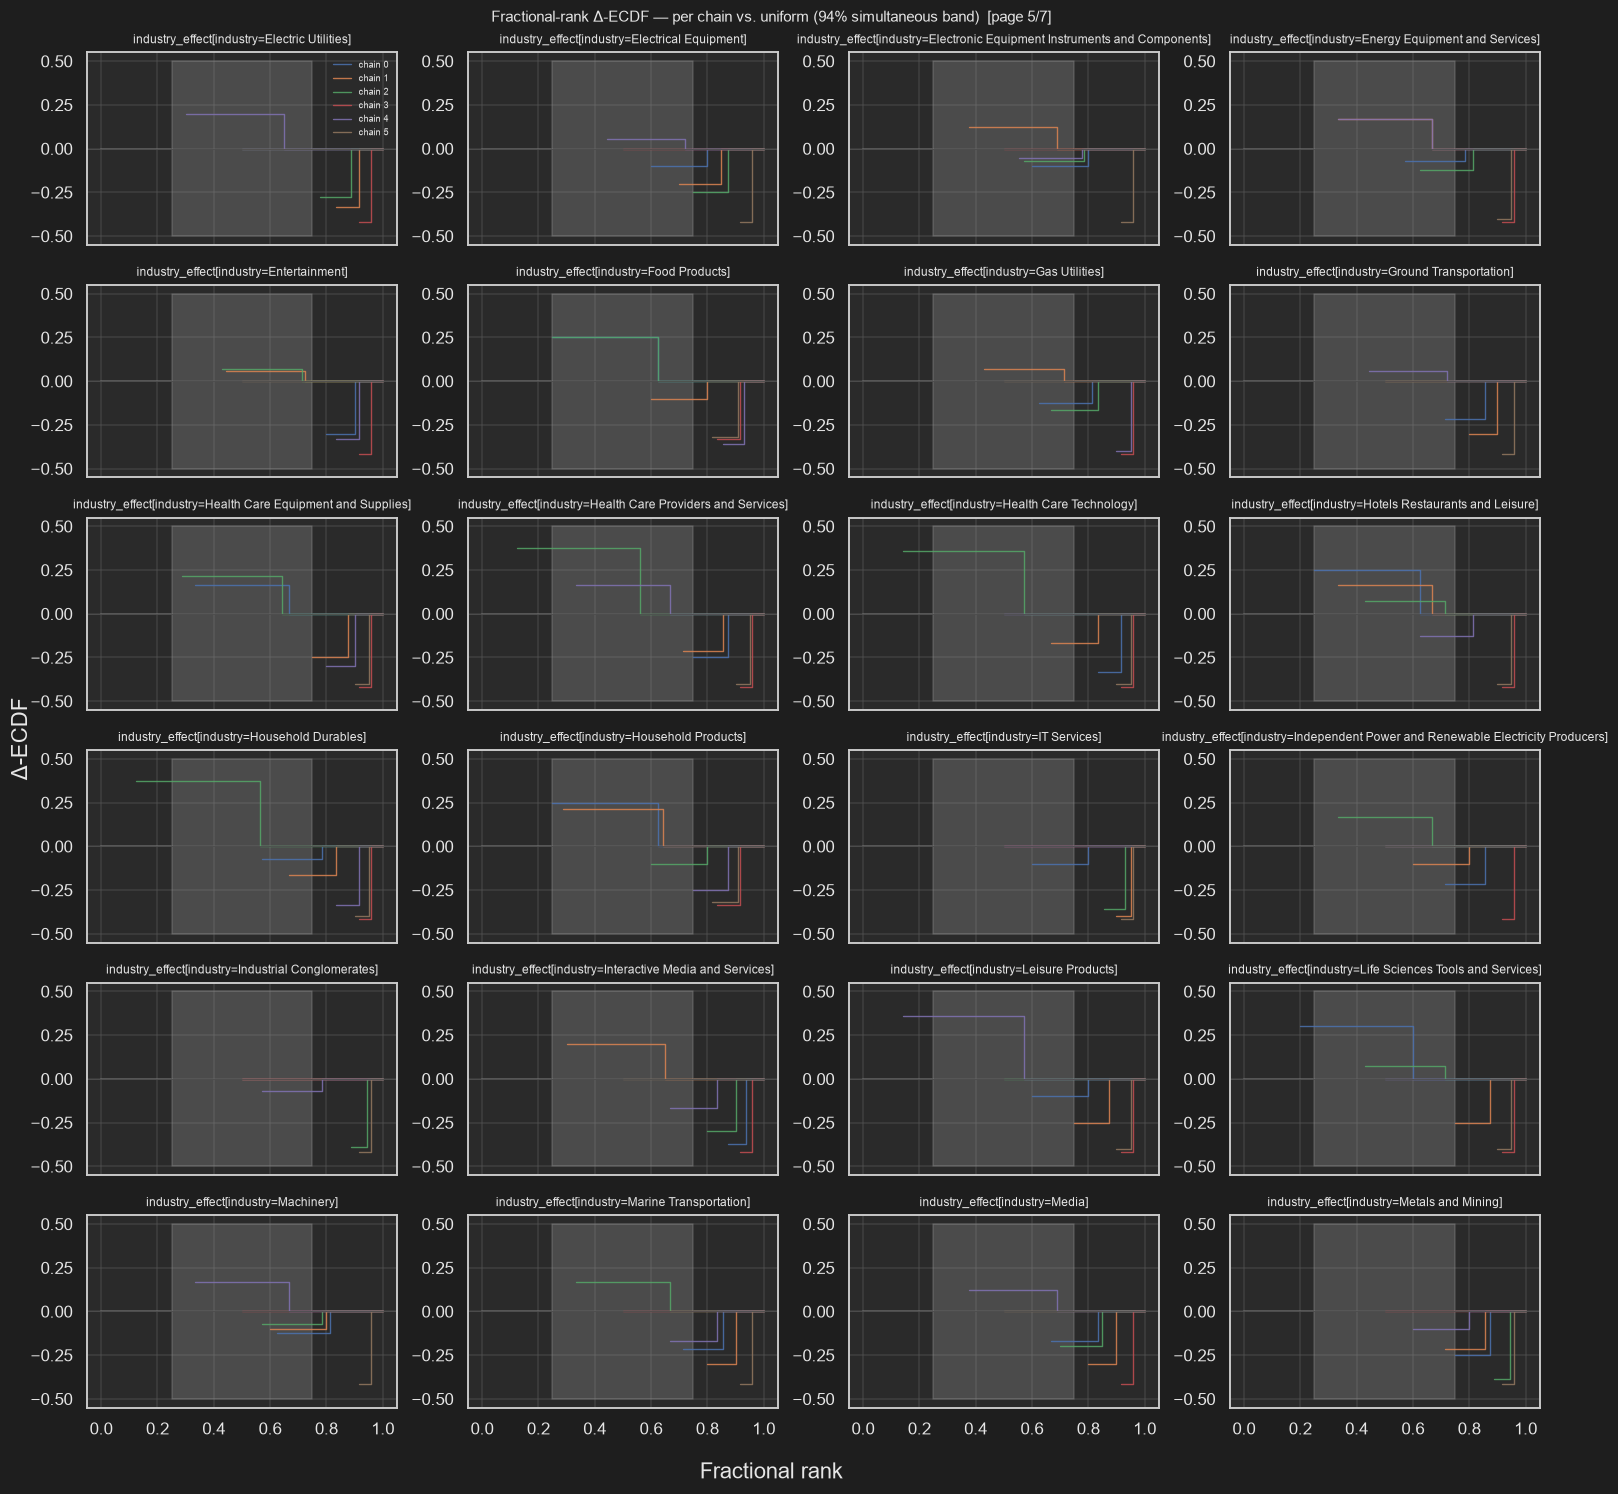

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


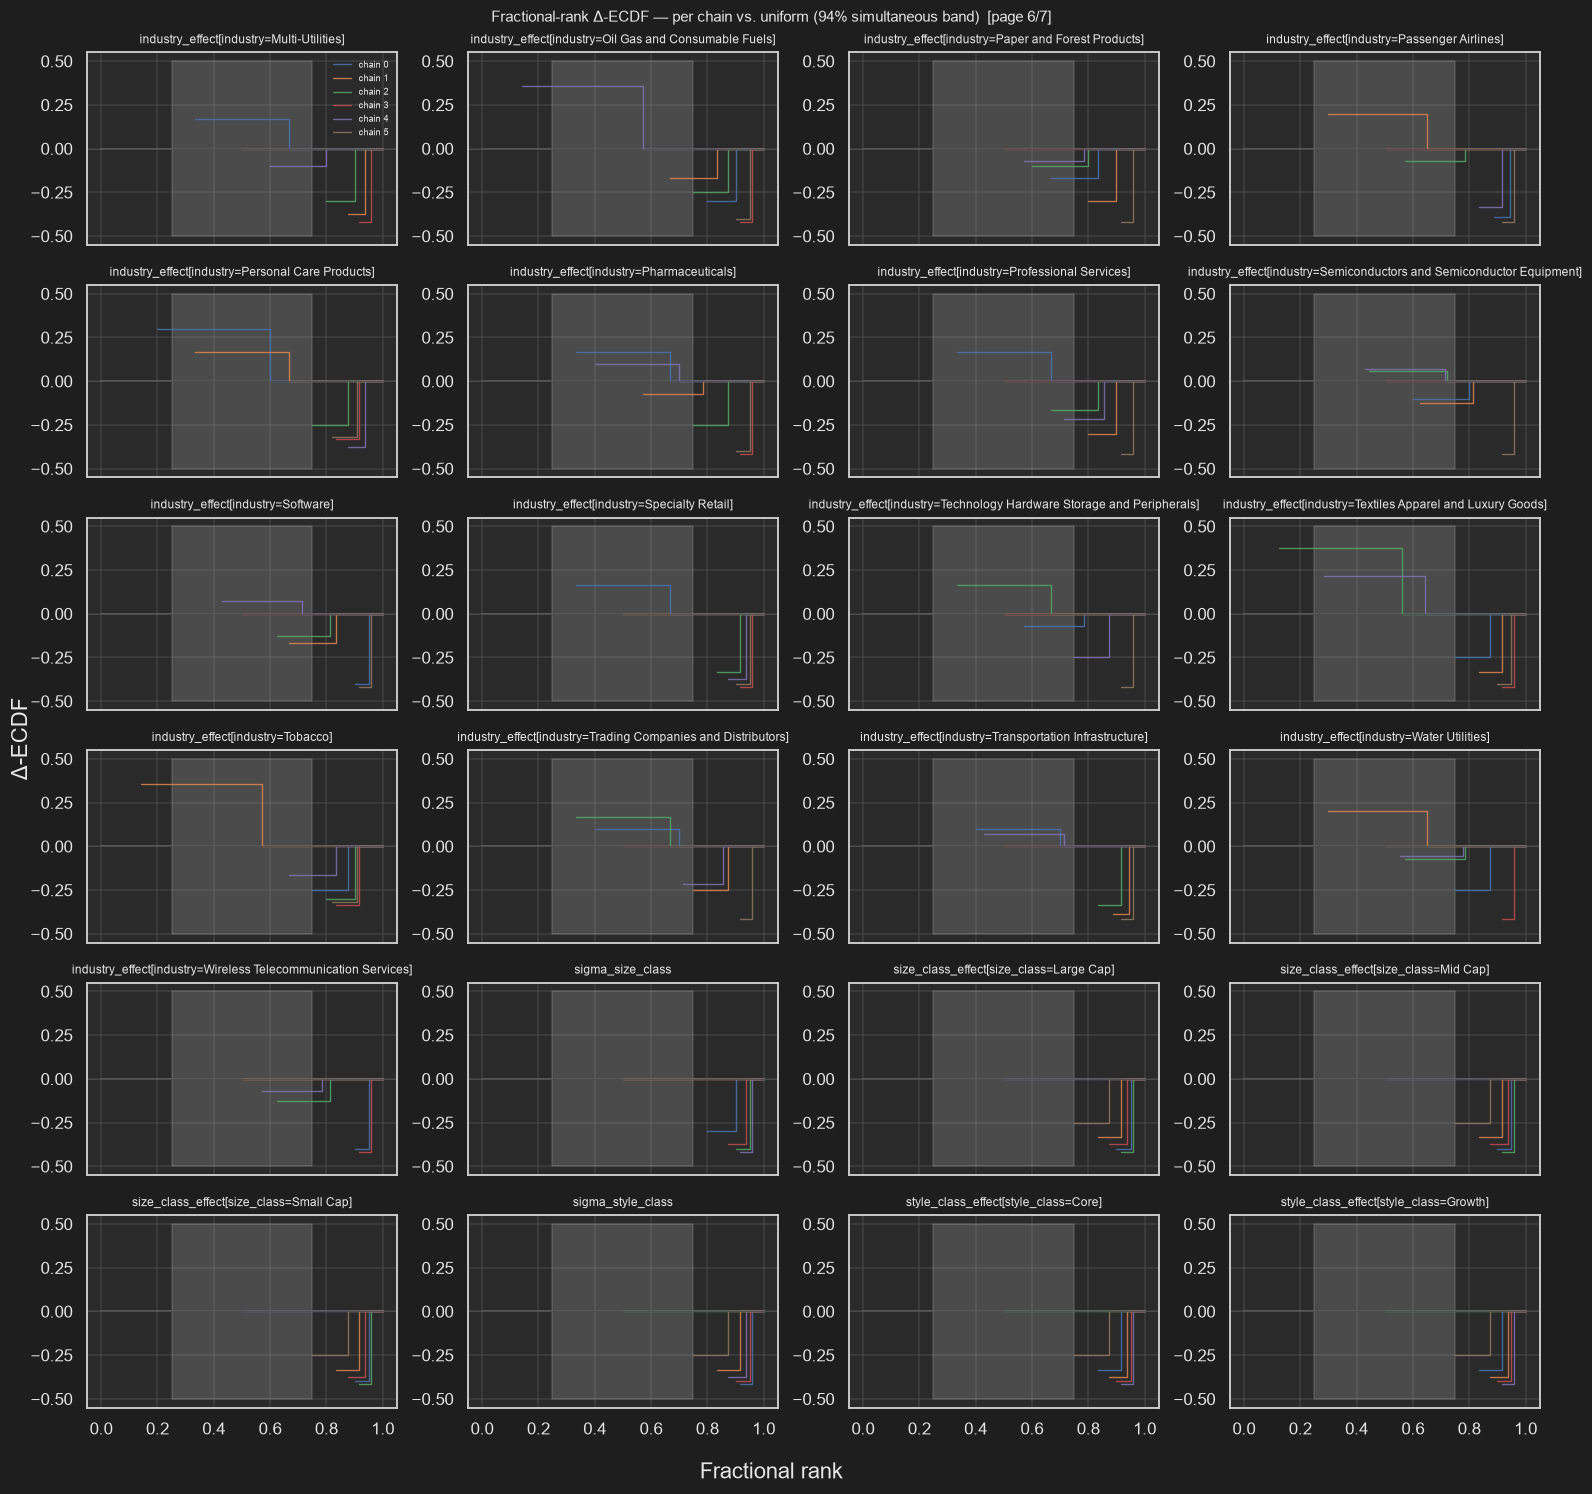

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\4257906338.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


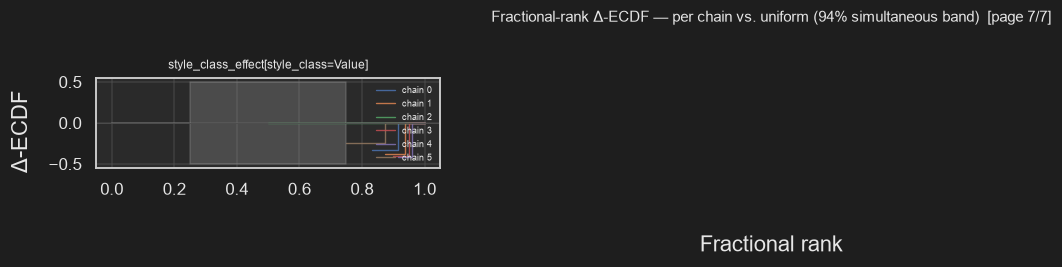

In [29]:
# 8.6  Fractional-rank Delta-ECDF diagnostics.
#
# The arviz_plots.plot_rank_dist batteries-included helper builds an internal
# PlotCollection whose per-aesthetic "mapping" lookup is brittle for this
# model's DataTree idata: it raised `KeyError: 'Could not find node at mapping'`
# for every parameter and leaked one Matplotlib figure per failed call. We
# instead compute the *same* fractional-rank Delta-ECDF statistics that
# `arviz_plots.plot_rank` uses internally and render them directly:
#
#   1. thin the draws (decorrelate, per Sailynoja et al. 2022),
#   2. replace draws by their fractional ranks computed over ALL chains
#      (`compute_ranks` over the sample dims) -> uniform[0, 1] under convergence,
#      then the per-chain PIT ECDF (`ecdf(..., pit=True)`),
#   3. overlay the simultaneous confidence band from
#      `arviz_stats.ecdf_utils.ecdf_pit` (accounts for the multi-chain comparison).
#
# A chain whose Delta-ECDF wanders outside the grey band signals that its ranks
# are not uniform -> that chain is not sampling the same posterior (poor mixing).
# This is backend-agnostic, renders every cross-sectional parameter of the
# hierarchical Student-t model (mu_global, beta, sigma_base, nu, and each
# sigma_<coord> / <coord>_effect group effect) in shared paginated figures, and
# never leaks per-call figures.
import numpy as np
import matplotlib.pyplot as plt
from arviz_stats.ecdf_utils import ecdf_pit

ENVELOPE_PROB = 0.94  # simultaneous confidence-band coverage
PANELS_PER_FIG = 24  # cap panels per figure (4 cols x 6 rows)
N_COLS = 4

post_rank = idata.posterior
_requested_rank = ['mu_global', 'beta', 'sigma_base', 'nu']
for _grp in GROUP_EFFECTS:
    _requested_rank.extend([f'sigma_{_grp}', f'{_grp}_effect'])
_rank_vars = [v for v in _requested_rank if v in post_rank.data_vars
              and all(post_rank[v].sizes[d] > 0 for d in post_rank[v].dims)]


def _iter_rank_slices(var_name):
    """Yield (label, 2-D (chain, draw) DataArray) for every scalar slice.

    Scalar params yield themselves; vector params (e.g. beta over `pt_feature`,
    `<coord>_effect` over a category) yield one labelled (chain, draw) slice per
    coordinate value, so each panel is a genuine 1-D rank diagnostic.
    """
    da = idata['posterior'][var_name]
    extra = [d for d in da.dims if d not in ('chain', 'draw')]
    if not extra:
        yield var_name, da
        return
    stacked = da.stack(_slice=extra)
    for i in range(stacked.sizes['_slice']):
        sl = stacked.isel(_slice=i)
        bits = [f"{d}={sl.coords[d].values.item()}" for d in extra if d in sl.coords]
        sl = sl.drop_vars([c for c in sl.coords if c not in ('chain', 'draw')],
                          errors='ignore')
        yield f"{var_name}[{', '.join(bits)}]", sl


def _frac_rank_ecdf(da2d):
    """Replicate plot_rank's Delta-ECDF for one (chain, draw) DataArray.

    Returns ``(x, y, x_ci, lower_ci, upper_ci)`` where ``x``/``y`` are the
    per-chain PIT ECDF coordinates (``y`` already differenced against the
    uniform CDF) and ``(x_ci, lower_ci, upper_ci)`` is the simultaneous band.
    """
    ds = da2d.to_dataset(name='v').azstats.thin(sample_dims=['draw'])
    sample_size = int(ds.sizes['draw'])
    n_chains = int(ds.sizes['chain'])
    ranks = ds.azstats.compute_ranks(dim=['chain', 'draw'])
    ecdf = ranks.azstats.ecdf(dim=['draw'], pit=True, npoints=sample_size)['v']
    x = ecdf.sel(plot_axis='x').values  # (chain, ecdf_dim)
    y = ecdf.sel(plot_axis='y').values  # (chain, ecdf_dim) Delta-ECDF
    dummy = np.linspace(0.0, 1.0, sample_size)
    x_ci, _, lower_ci, upper_ci = ecdf_pit(
        dummy, ENVELOPE_PROB, n_simulations=1000, n_chains=n_chains
    )
    return x, y, x_ci, lower_ci - x_ci, upper_ci - x_ci


_slices = [(label, da) for v in _rank_vars for label, da in _iter_rank_slices(v)]

if not _slices:
    print('No rank-dist-eligible variables available.')
else:
    n_total = len(_slices)
    for start in range(0, n_total, PANELS_PER_FIG):
        chunk = _slices[start:start + PANELS_PER_FIG]
        n = len(chunk)
        nrows = int(np.ceil(n / N_COLS))
        fig, axes = plt.subplots(
            nrows, N_COLS, figsize=(3.6 * N_COLS, 2.3 * nrows),
            squeeze=False, sharex=True,
        )
        for ax in axes.flat[n:]:
            ax.set_visible(False)
        for ax, (label, da) in zip(axes.flat, chunk):
            try:
                x, y, x_ci, lo, hi = _frac_rank_ecdf(da)
                ax.fill_between(x_ci, lo, hi, step='mid', color='0.6', alpha=0.30)
                for c in range(y.shape[0]):
                    ax.step(x[c], y[c], where='mid', linewidth=0.9, alpha=0.85,
                            label=f'chain {c}')
                ax.axhline(0.0, color='0.3', linewidth=0.6)
                ax.set_title(label, fontsize=8)
            except Exception as exc:  # pragma: no cover - per-slice guard
                ax.set_visible(False)
                print(f"  Skipping {label!r}: {type(exc).__name__}: {exc}")
        if n:
            axes.flat[0].legend(fontsize=6, loc='upper right', framealpha=0.6)
        page = start // PANELS_PER_FIG + 1
        pages = int(np.ceil(n_total / PANELS_PER_FIG))
        fig.suptitle(
            f'Fractional-rank Δ-ECDF — per chain vs. uniform '
            f'({int(ENVELOPE_PROB * 100)}% simultaneous band)  '
            f'[page {page}/{pages}]',
            fontsize=10,
        )
        fig.supxlabel('Fractional rank')
        fig.supylabel('Δ-ECDF')
        fig.tight_layout()
        plt.show()


### Summary

- §2 — EDA over `pml.mv_pymc_price_target` columns using `vw_pymc_feature_catalogue` (`pymc_role` / `feature_role` / `feature_alias`). Classification coords (`region, country, trading_country, exchange, unit, style_class, size_class, sector, industry`) profiled.
- §3 — per-column summary statistics merged with the catalogue, rolled up by `(pymc_role, feature_role, category)`; analyst-sentiment / valuation predictors visualised.
- §4 — **cross-sectional hierarchical Student-t** PyMC model with `pm.Data` containers named after MV aliases (`pt_features`, `feat_target_dispersion_cv`, `feat_analyst_conviction`, `sqrt_n_analysts`, `observed_target_pct`, `<coord>_idx`). One observation per ISIN; multi-coord partial-pooling intercepts (`sector, industry, region, size_class, style_class`). `mu_isin` lives on the `observed_target_pct` scale; `risk_adj_return` is a derived screening output. The previous tiled `(isin, time, y_series)` MvGRW and per-observation latent were removed so the marginal posterior and PSIS-LOO are reliable and comparable.
- §5 — prior predictive checks: `mu_isin` vs empirical `observed_target_pct` (same scale) and the prior predictive ECDF of `target_pct_obs`.
- §6 — NUTS posterior inference with `nutpie → numpyro → pymc` fallback; posterior-predictive interval-vs-observed calibration with empirical 90% coverage.
- §7 — posterior predictive ECDF and `sector_effect` vs empirical sector means.
- §8 — R-hat / ESS / divergences across the parameter set (`mu_global`, `beta`, `sigma_{sector,industry,region,size_class,style_class}`, `<coord>_effect`, `sigma_base`, `nu`); trace + density panels, energy plot with BFMI, and a forest plot of the group-effect scales and predictor slopes.

## 9. Expected Price Targets — Posterior Summary

`risk_adj_return` is the model's per-ISIN **risk-adjusted expected return** (the
`mu_isin * exp(-RISK_PENALTY * conviction)` deterministic), on the same fractional scale as
`observed_target_pct`. We translate it into price space as

```
expected_pt = last_price * (1 + risk_adj_return)
```

and report it alongside the analyst consensus target (`observed_pt = price_target`) and the
current `last_price`. The 94% HDI is propagated through the same transform. Comparison
signals surfaced in the table:

- **`expected_pt` vs `observed_pt` vs `last_price`** — model fair-value vs analyst target vs spot.
- **`observed_target_pct` vs `risk_adj_return`** — raw analyst-implied return vs the model's
  shrunk, risk-adjusted estimate.
- **`expected_upside_pct`** = `risk_adj_return * 100` — the implied move that ranks the screen.

In [30]:
# 9.0  Posterior expected price targets + implied upside per ISIN.
# expected_pt = last_price * (1 + risk_adj_return); risk_adj_return is a fractional
# return (same scale as observed_target_pct), so the (1 + .) form is the correct
# price-space conversion. The 94% HDI is propagated through the same transform.
post = idata.posterior


def _post_mean(v):
    return post[v].mean(('chain', 'draw')).values


def _post_hdi(v, p=0.94):
    da = post[v].stack(s=('chain', 'draw'))
    lo = da.quantile((1 - p) / 2, dim='s').values
    hi = da.quantile(1 - (1 - p) / 2, dim='s').values
    return lo, hi


rar = _post_mean('risk_adj_return')
rar_lo, rar_hi = _post_hdi('risk_adj_return')

last_price = model_df['last_price'].to_numpy()
observed_pt = model_df['price_target'].to_numpy()

expected_pt = last_price * (1.0 + rar)
expected_pt_lo = last_price * (1.0 + rar_lo)
expected_pt_hi = last_price * (1.0 + rar_hi)

results = pd.DataFrame({
    'isin': isin_labels,
    'ticker': model_df.get('ticker'),
    'name': model_df.get('name'),
    'sector': model_df.get('sector'),
    'last_price': last_price,
    'observed_pt': observed_pt,
    'expected_pt': expected_pt,
    'expected_pt_hdi_lo': expected_pt_lo,
    'expected_pt_hdi_hi': expected_pt_hi,
    'risk_adj_return': rar,
    # Comparative return signals: model risk-adjusted return, raw analyst-implied
    # target return, and (where available) realised YTD return.
    'expected_upside_pct': rar * 100.0,
    'observed_target_pct': model_df['observed_target_pct'].to_numpy() * 100.0,
    'implied_upside_pct': (
        model_df['feat_implied_upside'].to_numpy() * 100.0
        if 'feat_implied_upside' in model_df.columns
        else (observed_pt / last_price - 1.0) * 100.0
    ),
    'total_return_ytd_pct': (
        model_df['total_return_ytd'].to_numpy() * 100.0
        if 'total_return_ytd' in model_df.columns else np.nan
    ),
    'n_analysts': model_df['n_analysts'].to_numpy(),
})
results = results.sort_values('expected_upside_pct', ascending=False).reset_index(drop=True)
print(f'Expected price targets for {len(results)} ISINs '
      f'(median |risk_adj_return| = {np.nanmedian(np.abs(rar)):.3f}).')
results.head(50)

Expected price targets for 6281 ISINs (median |risk_adj_return| = 0.218).


,isin,ticker,name,sector,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,risk_adj_return,expected_upside_pct,observed_target_pct,implied_upside_pct,total_return_ytd_pct,n_analysts
0,BMG9156K1018,2020,2020 Bulkers Ltd.,Industrials,3.9940,135.7632,135.763234,135.762966,135.763503,32.991796,3299.179609,3299.18,3299.178768,63.44,2
1,GB0004170089,HEAD,Headlam Group plc,Consumer Discretionary,0.2370,3.1500,3.149030,3.149023,3.149036,12.287045,1228.704511,1229.11,1229.113924,-49.57,2
2,DE000A40ZW88,TPG0,The Platform Group SE & Co. KGaA,Consumer Discretionary,1.4600,18.5000,18.487226,18.487191,18.487260,11.662483,1166.248333,1167.12,1167.123288,-73.26,3
3,GG00B2R9PM06,CHAR,Chariot Limited,Energy,0.0162,0.1972,0.197019,0.197019,0.197019,11.161674,1116.167406,1117.09,1117.283951,10.73,2
4,GB00BP41S218,SAVE,Savannah Energy PLC,Energy,0.0650,0.3720,0.371693,0.371693,0.371694,4.718357,471.835673,472.31,472.307692,-7.80,2
5,BE0974358906,NYXH,Nyxoah SA,Health Care,1.4060,7.3667,7.362726,7.362713,7.362739,4.236647,423.664693,423.95,423.947368,-65.58,3
6,SE0009581051,ISOFOL,Isofol Medical AB (publ),Health Care,0.6910,3.6000,3.600002,3.599992,3.600011,4.209843,420.984308,420.98,420.984081,-5.21,2
7,FR0013153541,MDM,Maisons du Monde S.A.,Consumer Discretionary,0.4370,2.2667,2.266701,2.266696,2.266705,4.186959,418.695858,418.69,418.695652,-76.73,3
8,IT0005603078,MS,Misitano & Stracuzzi S.p.A.,Consumer Staples,0.3100,1.5250,1.525001,1.524998,1.525004,3.919359,391.935895,391.94,391.935484,-85.24,2
9,SE0007413455,ALZ,Alzinova AB (publ),Health Care,0.4860,2.3000,2.300002,2.299995,2.300008,3.732514,373.251367,373.25,373.251029,-41.38,2


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\927447987.py:24: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\markm\AppData\Local\Temp\ipykernel_24796\927447987.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


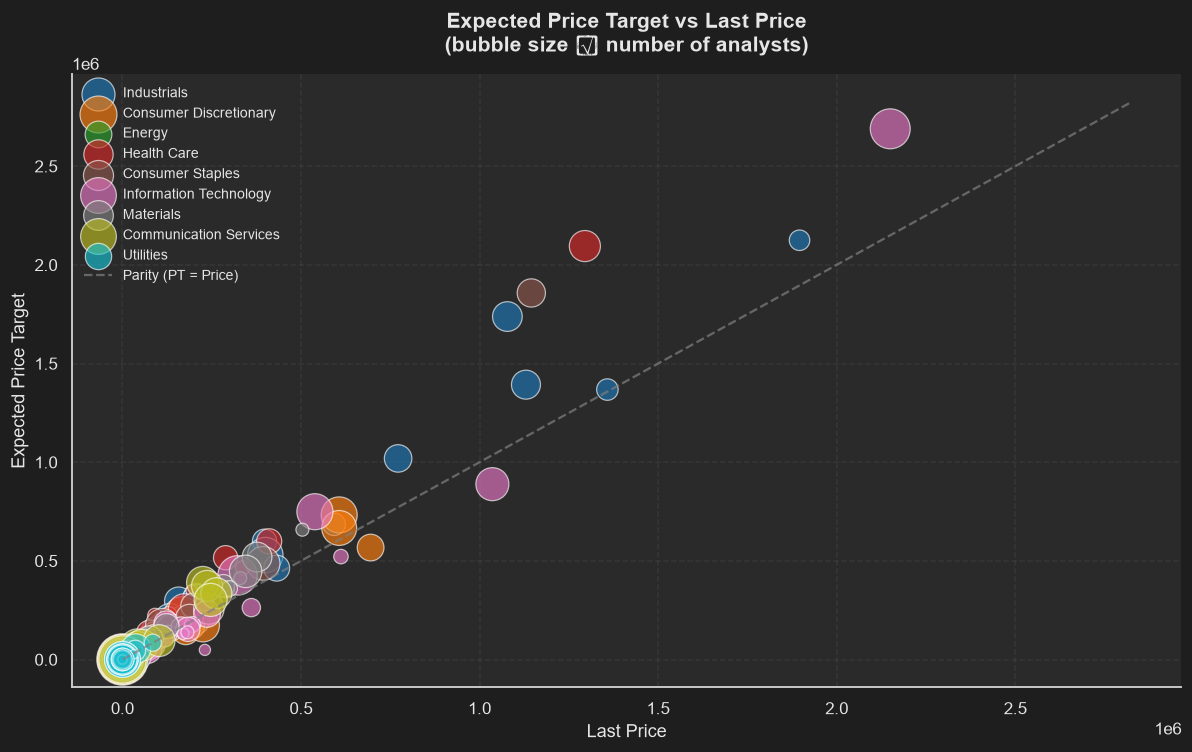

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 7))
sectors = results['sector'].unique()
cmap = plt.cm.tab10(np.linspace(0, 1, len(sectors)))
color_map = {s: cmap[i] for i, s in enumerate(sectors)}
for s in sectors:
    sub = results[results['sector'] == s]
    ax.scatter(sub['last_price'], sub['expected_pt'],
               s=sub['n_analysts'] * 18, alpha=0.65,
               color=color_map[s], edgecolors='white', linewidth=0.8, label=s)
lim = max(results['last_price'].max(), results['expected_pt'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.7, label='Parity (PT = Price)')
ax.set_xlabel('Last Price', fontsize=12)
ax.set_ylabel('Expected Price Target', fontsize=12)
ax.set_title('Expected Price Target vs Last Price\n(bubble size ∝ number of analysts)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

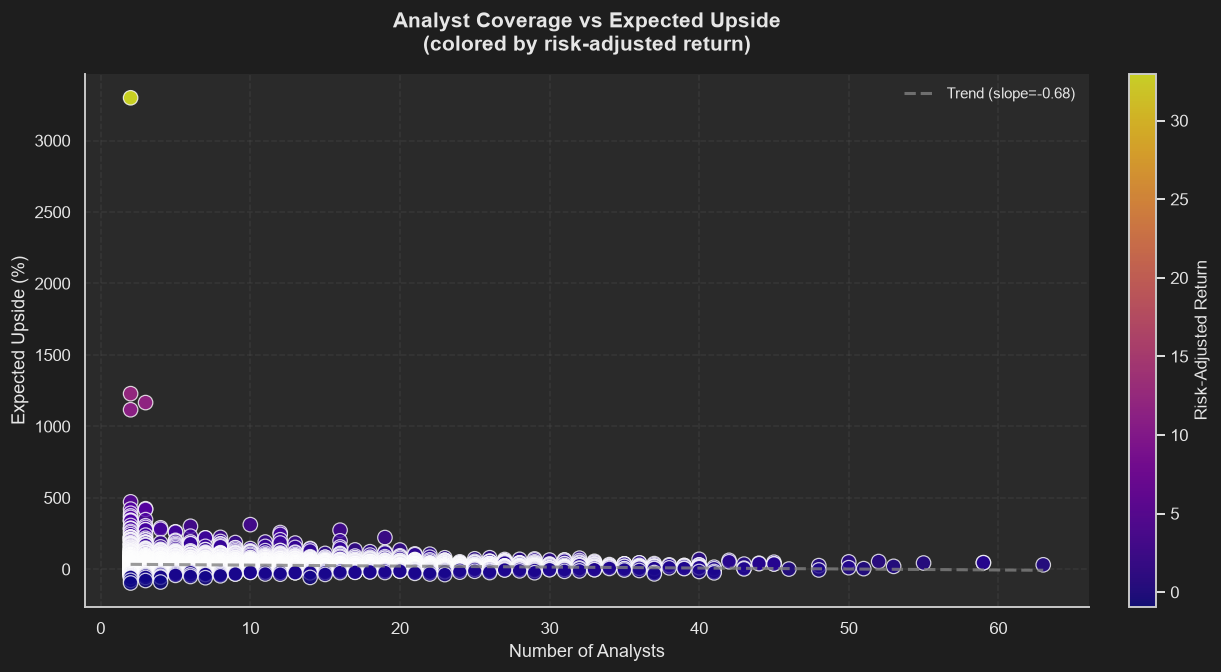

In [33]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(results['n_analysts'], results['expected_upside_pct'],
                c=results['risk_adj_return'], cmap='plasma',
                s=90, alpha=0.8, edgecolors='white', linewidth=0.8)
z = np.polyfit(results['n_analysts'], results['expected_upside_pct'], 1)
xs = np.linspace(results['n_analysts'].min(), results['n_analysts'].max(), 100)
ax.plot(xs, np.polyval(z, xs), '--', color='gray', linewidth=2, alpha=0.8,
        label=f'Trend (slope={z[0]:.2f})')
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Risk-Adjusted Return', fontsize=11)
ax.set_xlabel('Number of Analysts', fontsize=12)
ax.set_ylabel('Expected Upside (%)', fontsize=12)
ax.set_title('Analyst Coverage vs Expected Upside\n(colored by risk-adjusted return)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

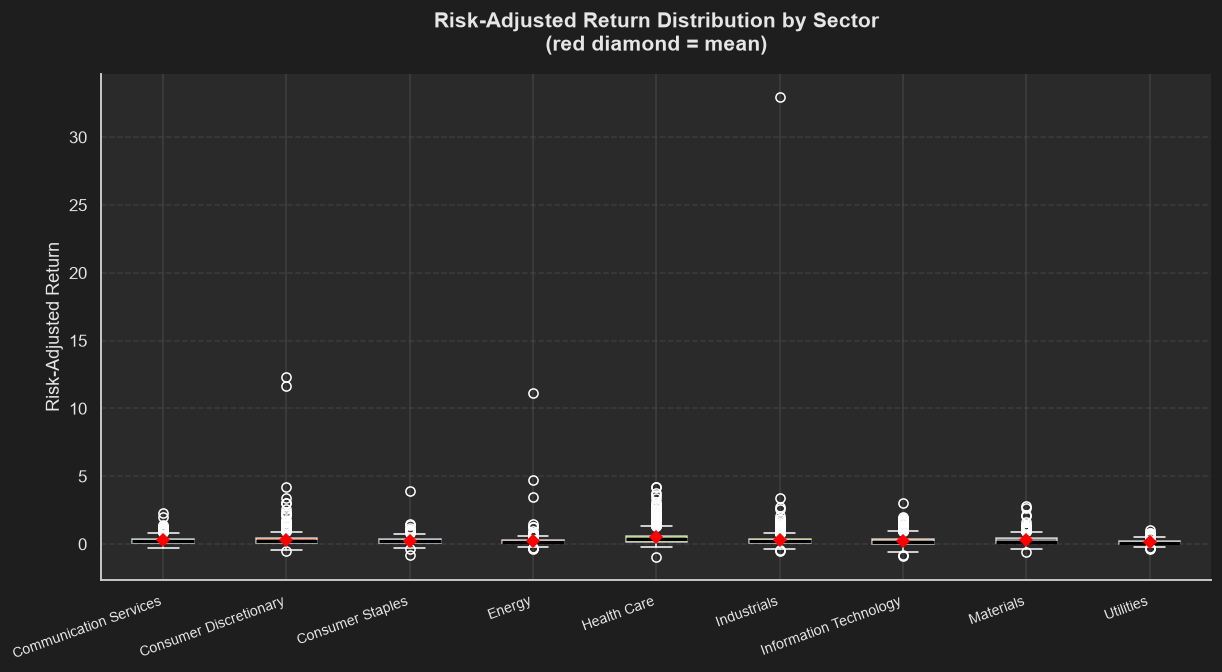

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))
sectors = sorted(results['sector'].unique())
data = [results[results['sector'] == s]['risk_adj_return'].dropna().values for s in sectors]
bp = ax.boxplot(data, label=sectors, patch_artist=True, showmeans=True,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=6))
colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('Risk-Adjusted Return', fontsize=12)
ax.set_title('Risk-Adjusted Return Distribution by Sector\n(red diamond = mean)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(sectors, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

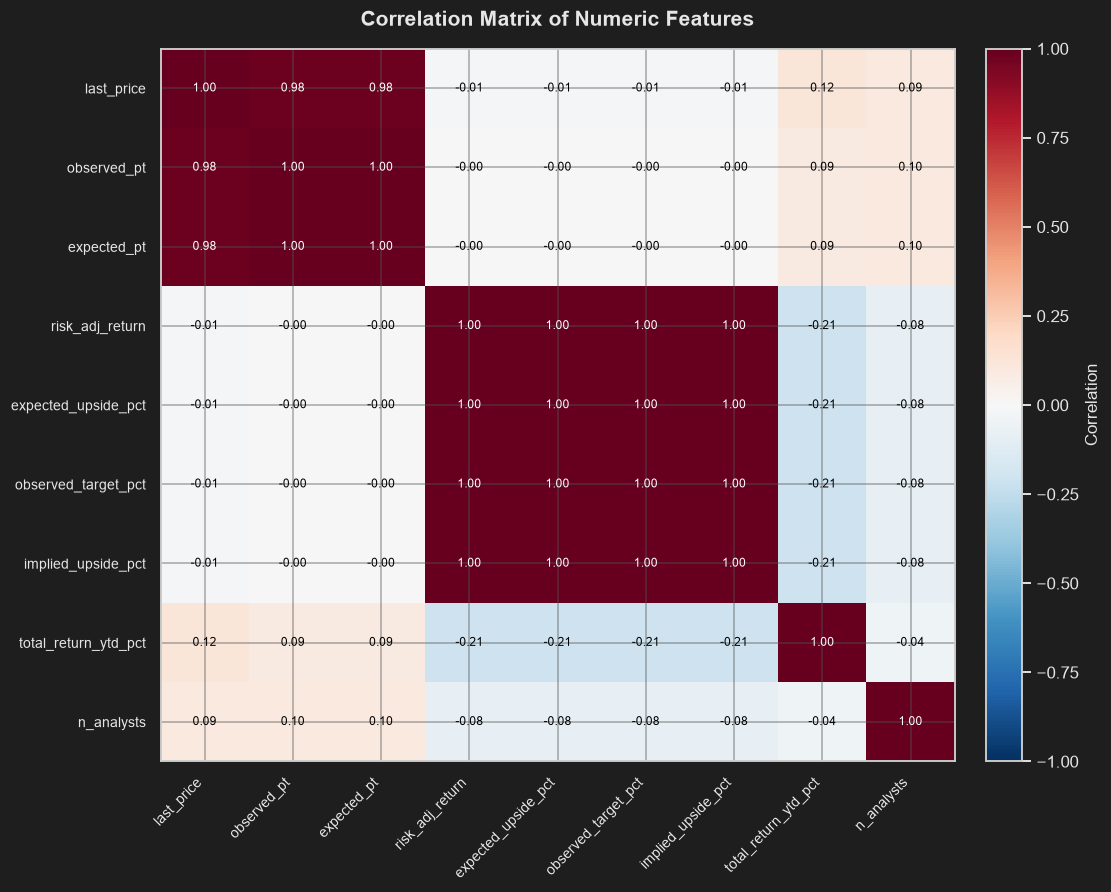

In [38]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['last_price', 'observed_pt', 'expected_pt', 'risk_adj_return',
        'expected_upside_pct', 'observed_target_pct', 'implied_upside_pct',
        'total_return_ytd_pct', 'n_analysts']
corr = results[cols].corr().values
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr[i, j]) > 0.5 else 'black', fontsize=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation', fontsize=11)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.show()

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\486413734.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


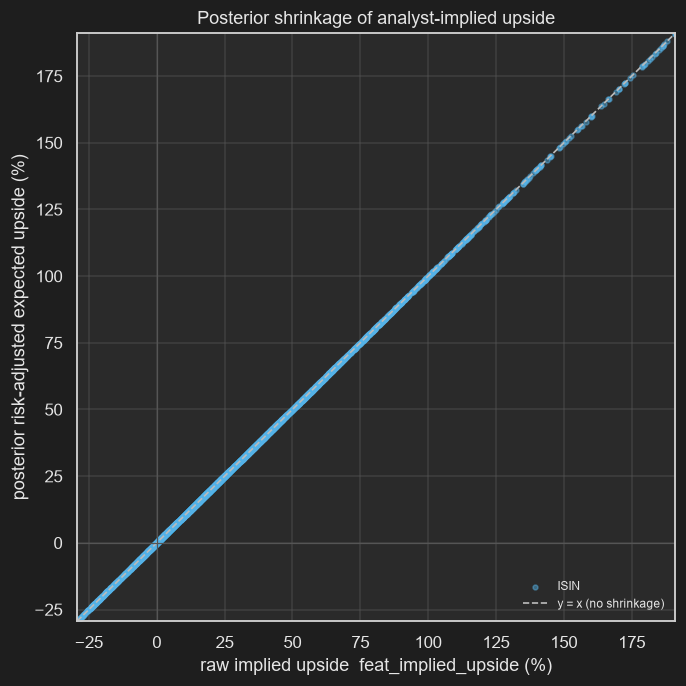

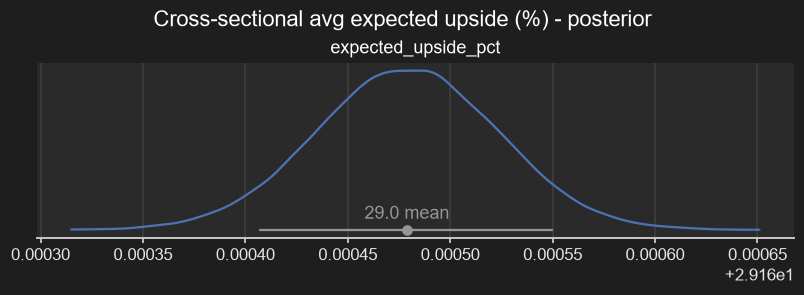

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\486413734.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


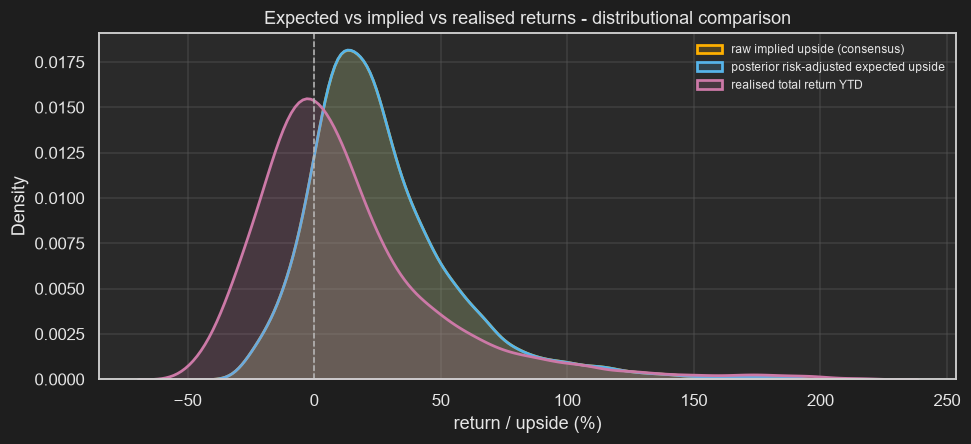

C:\Users\markm\AppData\Local\Temp\ipykernel_24796\486413734.py:102: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


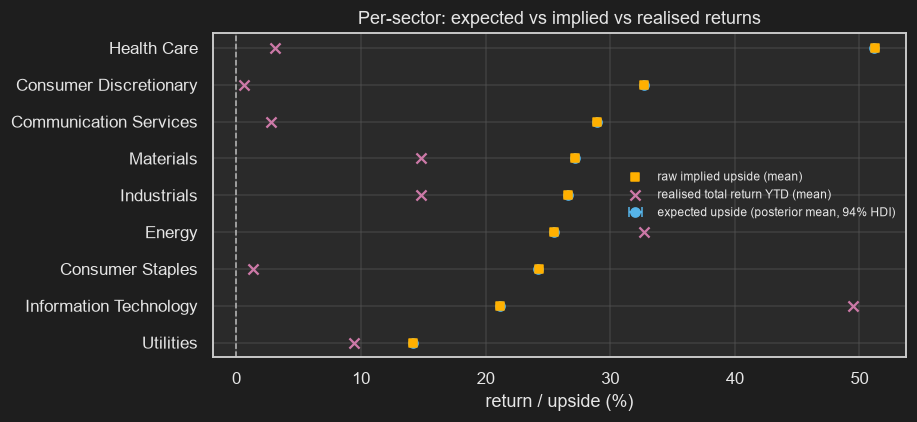

In [39]:
# Section 9b: comparative stock-returns analytics -
# implied_upside (raw analyst consensus) vs expected_upside (posterior risk-adjusted
# return) vs total_return_ytd (realised YTD return). Three complementary views.
#
# Adapted from the Kalman notebook's §10b. Two model-specific changes vs that source:
#   * this model has NO `expected_upside` deterministic; the per-ISIN posterior return
#     is `risk_adj_return` (mu_isin * exp(-RISK_PENALTY * conviction)). We read it from
#     idata.posterior['risk_adj_return'] and rescale to % for the posterior views.
#   * `xarray` is not imported at the top of this notebook, so we import it here.
import xarray as xr

_comp = results.dropna(subset=['expected_upside_pct']).copy()

# (1) Shrinkage scatter: raw analyst-implied upside (x) vs posterior risk-adjusted
#     expected upside (y). Points pulled toward y=0 / off the y=x line are shrunk
#     toward the hierarchical group mean.
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.scatter(_comp['implied_upside_pct'], _comp['expected_upside_pct'],
           s=10, alpha=0.45, color='#56b4e9', label='ISIN')
_both = np.r_[_comp['implied_upside_pct'].to_numpy(), _comp['expected_upside_pct'].to_numpy()]
_both = _both[np.isfinite(_both)]
_lo, _hi = float(np.nanpercentile(_both, 1)), float(np.nanpercentile(_both, 99))
ax.plot([_lo, _hi], [_lo, _hi], '--', color='#bbbbbb', lw=1.1, label='y = x (no shrinkage)')
ax.axhline(0, color='#555555', lw=0.8)
ax.axvline(0, color='#555555', lw=0.8)
ax.set_xlim(_lo, _hi)
ax.set_ylim(_lo, _hi)
ax.set_xlabel('raw implied upside  feat_implied_upside (%)')
ax.set_ylabel('posterior risk-adjusted expected upside (%)')
ax.set_title('Posterior shrinkage of analyst-implied upside')
ax.legend(fontsize=8, framealpha=0.25)
plt.tight_layout()
plt.show()

# (2) arviz_plots KDE of the posterior cross-sectional-average expected upside, then
#     an empirical KDE overlay of all three signals for a direct expected-vs-implied-
#     vs-realised comparison. This model exposes risk_adj_return (fractional) rather
#     than an `expected_upside` deterministic, so we rescale it to a % return here.
eu_pct = idata.posterior['risk_adj_return'] * 100.0  # (chain, draw, isin)
try:
    _dist = xr.Dataset({'expected_upside_pct': eu_pct.mean('isin')})
    pc_d = azp.plot_dist(_dist, kind='kde', var_names=['expected_upside_pct'],
                         sample_dims=['chain', 'draw'], backend='matplotlib')
    pc_d.add_title('Cross-sectional avg expected upside (%) - posterior')
    pc_d.show()
except Exception as _e:
    print(f'plot_dist KDE skipped: {_e!r}')

fig, ax = plt.subplots(figsize=(9, 4.2))
for _col, _lab, _c in [
    ('implied_upside_pct', 'raw implied upside (consensus)', '#ffb000'),
    ('expected_upside_pct', 'posterior risk-adjusted expected upside', '#56b4e9'),
    ('total_return_ytd_pct', 'realised total return YTD', '#cc79a7'),
]:
    _v = pd.to_numeric(_comp.get(_col), errors='coerce').to_numpy()
    _v = _v[np.isfinite(_v)]
    if _v.size > 5:
        _v = _v[(_v >= np.nanpercentile(_v, 1)) & (_v <= np.nanpercentile(_v, 99))]
    if _v.size:
        sns.kdeplot(_v, ax=ax, label=_lab, color=_c, fill=True, alpha=0.18, lw=1.8)
ax.axvline(0, color='#bbbbbb', ls='--', lw=1.0)
ax.set_xlabel('return / upside (%)')
ax.set_title('Expected vs implied vs realised returns - distributional comparison')
ax.legend(fontsize=8, framealpha=0.25)
plt.tight_layout()
plt.show()

# (3) Per-sector forest-style comparison: posterior expected upside (mean + 94% HDI)
#     against the per-sector mean raw implied upside and realised YTD return. Built
#     with a matplotlib error-bar so the HDI and the two reference series align
#     robustly on one y-axis (reuses the section-10 groupby-by-coord pattern).
_sector_da = xr.DataArray(
    model_df['sector'].fillna('Unknown').astype(str).to_numpy(),
    dims='isin', coords={'isin': eu_pct.coords['isin']},
)
eu_by_sector = eu_pct.groupby(_sector_da.rename('sector')).mean('isin')
_stack = eu_by_sector.stack(s=('chain', 'draw'))
_sec = [str(s) for s in eu_by_sector['sector'].values]
_mean = _stack.mean('s').values
_q_lo = _stack.quantile(0.03, 's').values
_q_hi = _stack.quantile(0.97, 's').values
_ref = (_comp.assign(sector=_comp['sector'].fillna('Unknown').astype(str))
        .groupby('sector')[['implied_upside_pct', 'total_return_ytd_pct']].mean()
        .reindex(_sec))
_order = np.argsort(_mean)
_y = np.arange(len(_sec))
fig, ax = plt.subplots(figsize=(8.5, max(4.0, 0.42 * len(_sec))))
ax.errorbar(_mean[_order], _y,
            xerr=[(_mean - _q_lo)[_order], (_q_hi - _mean)[_order]],
            fmt='o', color='#56b4e9', ecolor='#56b4e9', elinewidth=1.4, capsize=3,
            label='expected upside (posterior mean, 94% HDI)')
ax.scatter(_ref['implied_upside_pct'].to_numpy()[_order], _y, marker='s',
           color='#ffb000', s=34, zorder=6, label='raw implied upside (mean)')
ax.scatter(_ref['total_return_ytd_pct'].to_numpy()[_order], _y, marker='x',
           color='#cc79a7', s=44, zorder=6, label='realised total return YTD (mean)')
ax.axvline(0, color='#bbbbbb', ls='--', lw=1.0)
ax.set_yticks(_y)
ax.set_yticklabels(np.array(_sec)[_order])
ax.set_xlabel('return / upside (%)')
ax.set_title('Per-sector: expected vs implied vs realised returns')
ax.legend(fontsize=8, framealpha=0.25, loc='best')
plt.tight_layout()
plt.show()

## 10. Estimated Price Targets over upcoming/recent Earnings Period

This section scopes the expected price targets to the **earnings cohort** — modelled names
whose next earnings land within `±EARNINGS_WINDOW_DAYS` of today (`days_to_next_earnings`
from `pml.mv_pymc_price_target`). It **reuses the already-fitted cross-sectional posterior**
(no refit): for each cohort name we read `expected_pt` / `risk_adj_return` straight from
section 9's `results`, and compare the three headline quantities `last_price`, `observed_pt`
and `expected_pt`. An ArviZ forest of the per-ISIN `risk_adj_return` posterior (94% HDI)
shows which imminent reporters carry the strongest model-implied upside. The forest is capped
to the most extreme names when the cohort is large.

Earnings cohort (|days_to_next_earnings| <= 5): 123 of 6281 modelled ISINs.
Earnings-cohort expected price targets (last_price vs observed_pt vs expected_pt):


,isin,ticker,name,sector,days_to_next_earnings,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,observed_target_pct,expected_upside_pct,n_analysts
0,GB0004170089,HEAD,Headlam Group plc,Consumer Discretionary,1,0.237,3.150,3.149,3.149,3.149,1229.11,1228.705,2
1,GG00B2R9PM06,CHAR,Chariot Limited,Energy,4,0.016,0.197,0.197,0.197,0.197,1117.09,1116.167,2
2,GB00BP41S218,SAVE,Savannah Energy PLC,Energy,0,0.065,0.372,0.372,0.372,0.372,472.31,471.836,2
3,IT0005603078,MS,Misitano & Stracuzzi S.p.A.,Consumer Staples,4,0.310,1.525,1.525,1.525,1.525,391.94,391.936,2
4,IT0004147952,NWRN,Newron Pharmaceuticals S.p.A.,Health Care,1,12.060,47.087,47.066,47.066,47.066,290.44,290.264,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,US4663131039,JBL,Jabil Inc.,Information Technology,2,384.820,358.889,358.910,358.908,358.911,-6.74,-6.733,9
119,CNE100001ZT0,3396,Legend Holdings Corporation,Information Technology,-3,15.200,13.069,13.071,13.071,13.072,-14.02,-14.004,2
120,US1431301027,KMX,CarMax Inc.,Consumer Discretionary,2,51.260,42.692,42.693,42.693,42.694,-16.71,-16.712,13
121,FR0014005HJ9,OVH,OVH Groupe S.A.,Information Technology,4,15.750,10.444,10.444,10.444,10.445,-33.69,-33.686,9


Cohort has 123 ISINs; forest shows the 40 most extreme by expected upside (top/bottom 20).


C:\Users\markm\AppData\Local\Temp\ipykernel_24796\2346156501.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


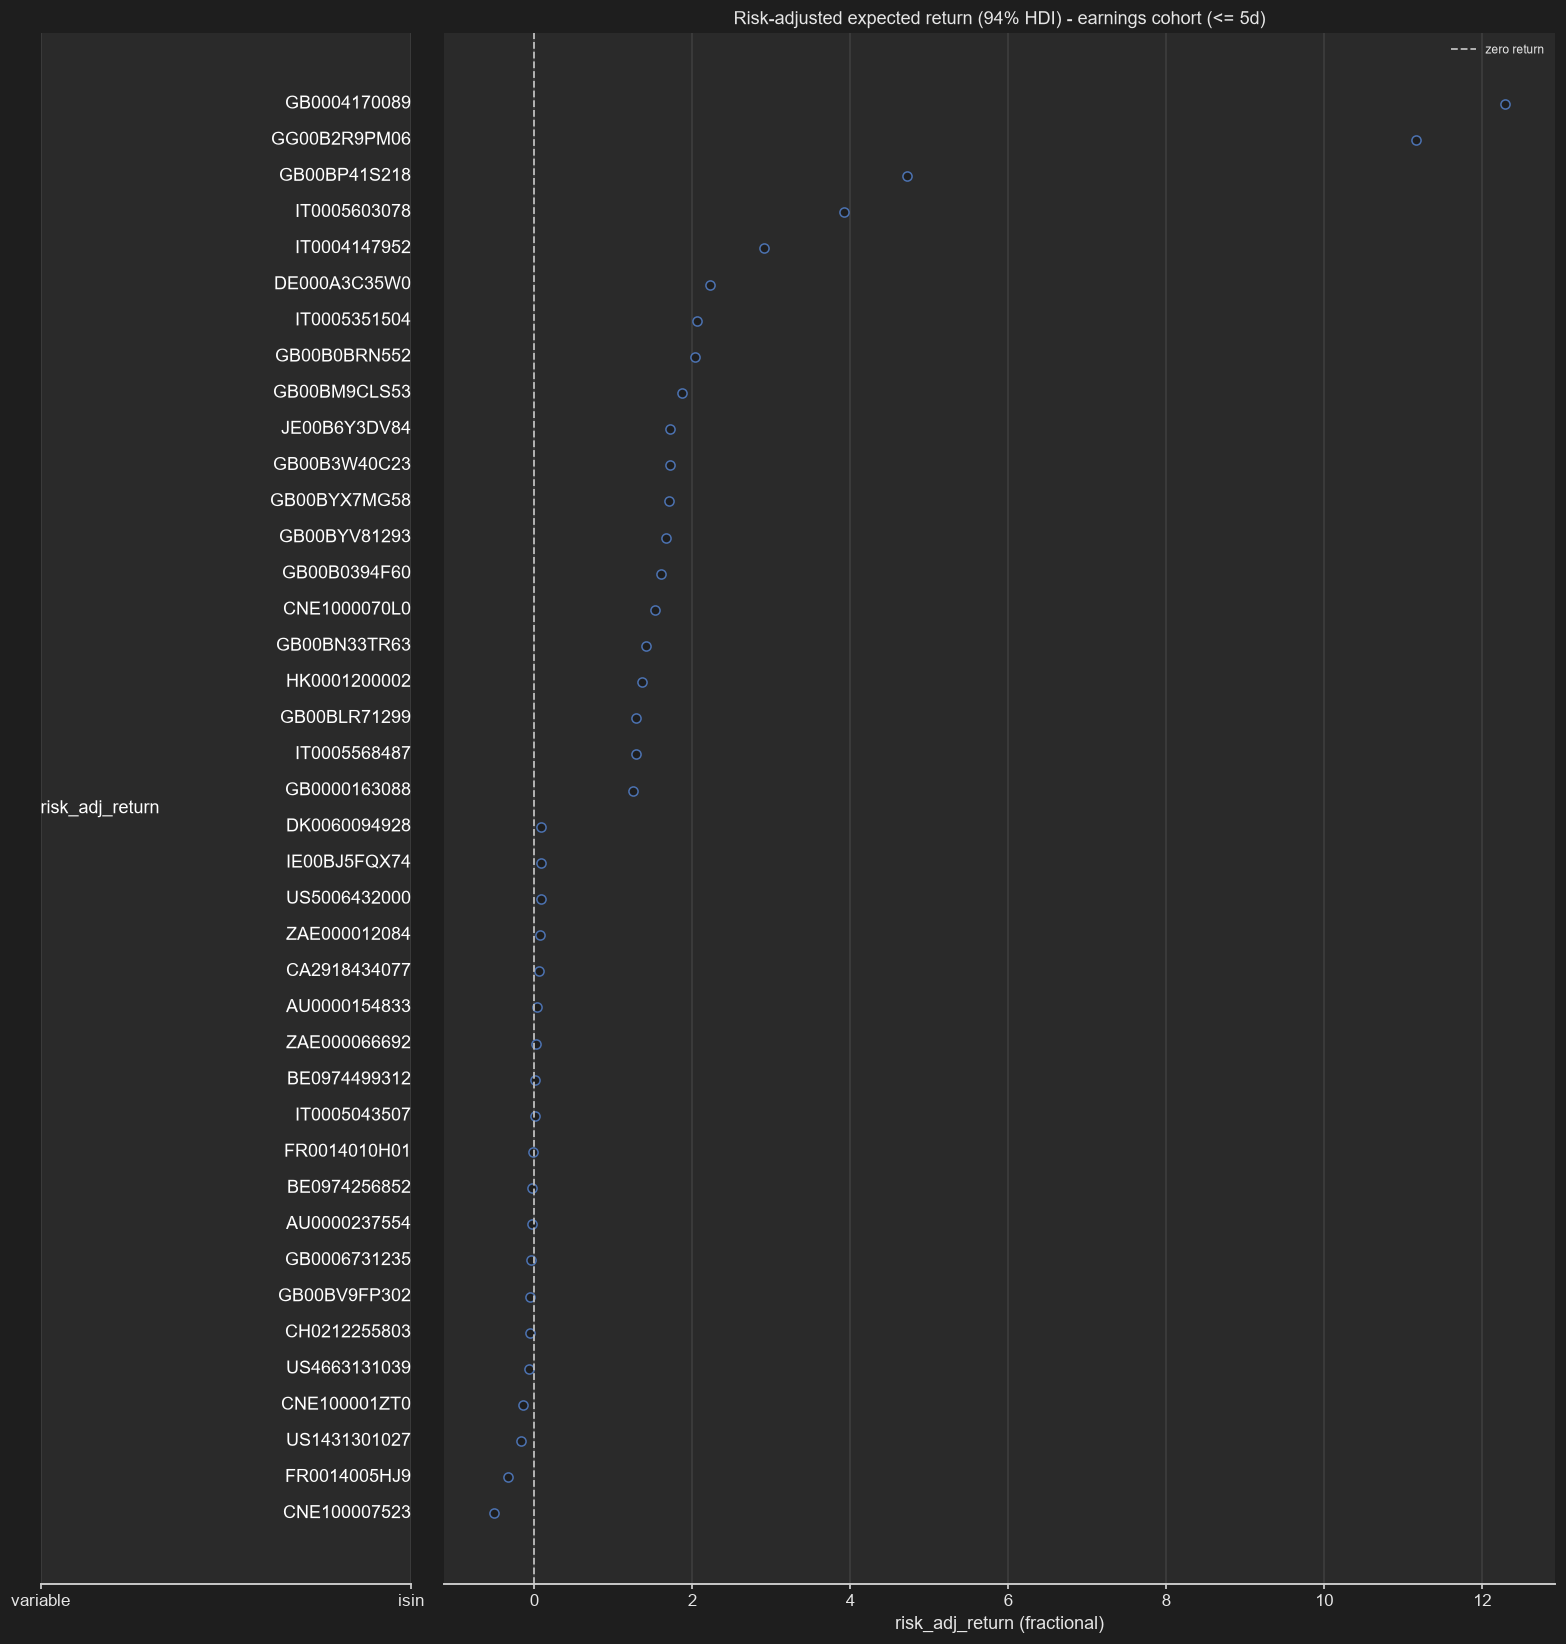

In [40]:
# 10.0  Earnings-cohort expected price targets (reuses the fitted posterior, no refit).
EARNINGS_WINDOW_DAYS = 5
MAX_FOREST = 40

try:
    # days_to_next_earnings is precomputed in the MV; fall back to relative
    # next_earnings spacing only if the day-count column is absent.
    if 'days_to_next_earnings' in model_df.columns:
        dte = pd.to_numeric(model_df['days_to_next_earnings'], errors='coerce')
    elif 'next_earnings' in model_df.columns:
        _ne = pd.to_datetime(model_df['next_earnings'], errors='coerce')
        dte = (_ne - _ne.dropna().min()).dt.days
    else:
        dte = pd.Series(np.nan, index=model_df.index)

    cohort_mask = (dte.abs() <= EARNINGS_WINDOW_DAYS).fillna(False).to_numpy()
    cohort_isins = model_df.loc[cohort_mask, 'isin'].astype(str).tolist()
    print(f'Earnings cohort (|days_to_next_earnings| <= {EARNINGS_WINDOW_DAYS}): '
          f'{len(cohort_isins)} of {len(model_df)} modelled ISINs.')

    if not cohort_isins:
        print('No modelled names report within the earnings window; section skipped.')
    else:
        dte_by_isin = pd.Series(dte.to_numpy(),
                                index=model_df['isin'].astype(str).to_numpy())
        cohort_tbl = results[results['isin'].isin(cohort_isins)].copy()
        cohort_tbl['days_to_next_earnings'] = cohort_tbl['isin'].map(dte_by_isin)
        cohort_tbl = cohort_tbl.sort_values('expected_upside_pct', ascending=False)
        print('Earnings-cohort expected price targets '
              '(last_price vs observed_pt vs expected_pt):')
        display(cohort_tbl[[
            'isin', 'ticker', 'name', 'sector', 'days_to_next_earnings', 'last_price',
            'observed_pt', 'expected_pt', 'expected_pt_hdi_lo', 'expected_pt_hdi_hi',
            'observed_target_pct', 'expected_upside_pct', 'n_analysts',
        ]].round(3).reset_index(drop=True))

        # Cap the forest so one row per ISIN stays legible: most extreme by upside.
        forest_isins = cohort_isins
        if len(cohort_tbl) > MAX_FOREST:
            half = MAX_FOREST // 2
            forest_isins = pd.concat([cohort_tbl.head(half),
                                      cohort_tbl.tail(half)])['isin'].astype(str).tolist()
            print(f'Cohort has {len(cohort_tbl)} ISINs; forest shows the {MAX_FOREST} '
                  f'most extreme by expected upside (top/bottom {half}).')

        rar_ds = idata.posterior['risk_adj_return'].sel(isin=forest_isins).to_dataset()
        azp.plot_forest(rar_ds, var_names=['risk_adj_return'], combined=True,
                        backend='matplotlib')
        plt.axvline(0.0, ls='--', color='#bbbbbb', lw=1.2, label='zero return')
        plt.legend(fontsize=8, framealpha=0.25)
        plt.title(f'Risk-adjusted expected return (94% HDI) - earnings cohort '
                  f'(<= {EARNINGS_WINDOW_DAYS}d)')
        plt.xlabel('risk_adj_return (fractional)')
        plt.tight_layout()
        plt.show()
except Exception as e:  # pragma: no cover - environment-dependent
    print(f'Section 10 (earnings-cohort expected price targets) skipped: {e!r}')

## 11. Granular Earnings-Cohort Expected-Price Simulation — Posterior-Predictive Forest

Section 10 reports posterior *means*; this section stays per-ISIN granular and renders the
full **posterior-predictive distribution of the expected stock price** for the earnings
cohort. Each posterior-predictive `target_pct_obs` draw (a simulated target return) is mapped
to price units via `last_price * (1 + target_pct_obs)`, giving a predictive distribution of
the simulated analyst price target per name. These are drawn as an `arviz_plots`
**posterior-predictive forest** with the realised analyst targets overlaid as points
(`visuals.scatter_x`). Two reference layers make it readable as a screen:

- **Reference HDI bands** (`add_bands`) — the cohort's central expected-price region from the
  pooled posterior `expected_pt` (94% lightest, 50% darker). Names whose predictive interval
  sits entirely outside the 94% band are the cohort's relative outliers going into earnings.
- **Cohort `last_price` line** (`add_lines`) — the median spot price, so simulated targets
  read as implied upside / downside.

The cell is guarded and caps the forest to the most extreme names when the cohort is large.

Cohort has 123 ISINs; showing the 40 most extreme by expected upside (top/bottom 20).


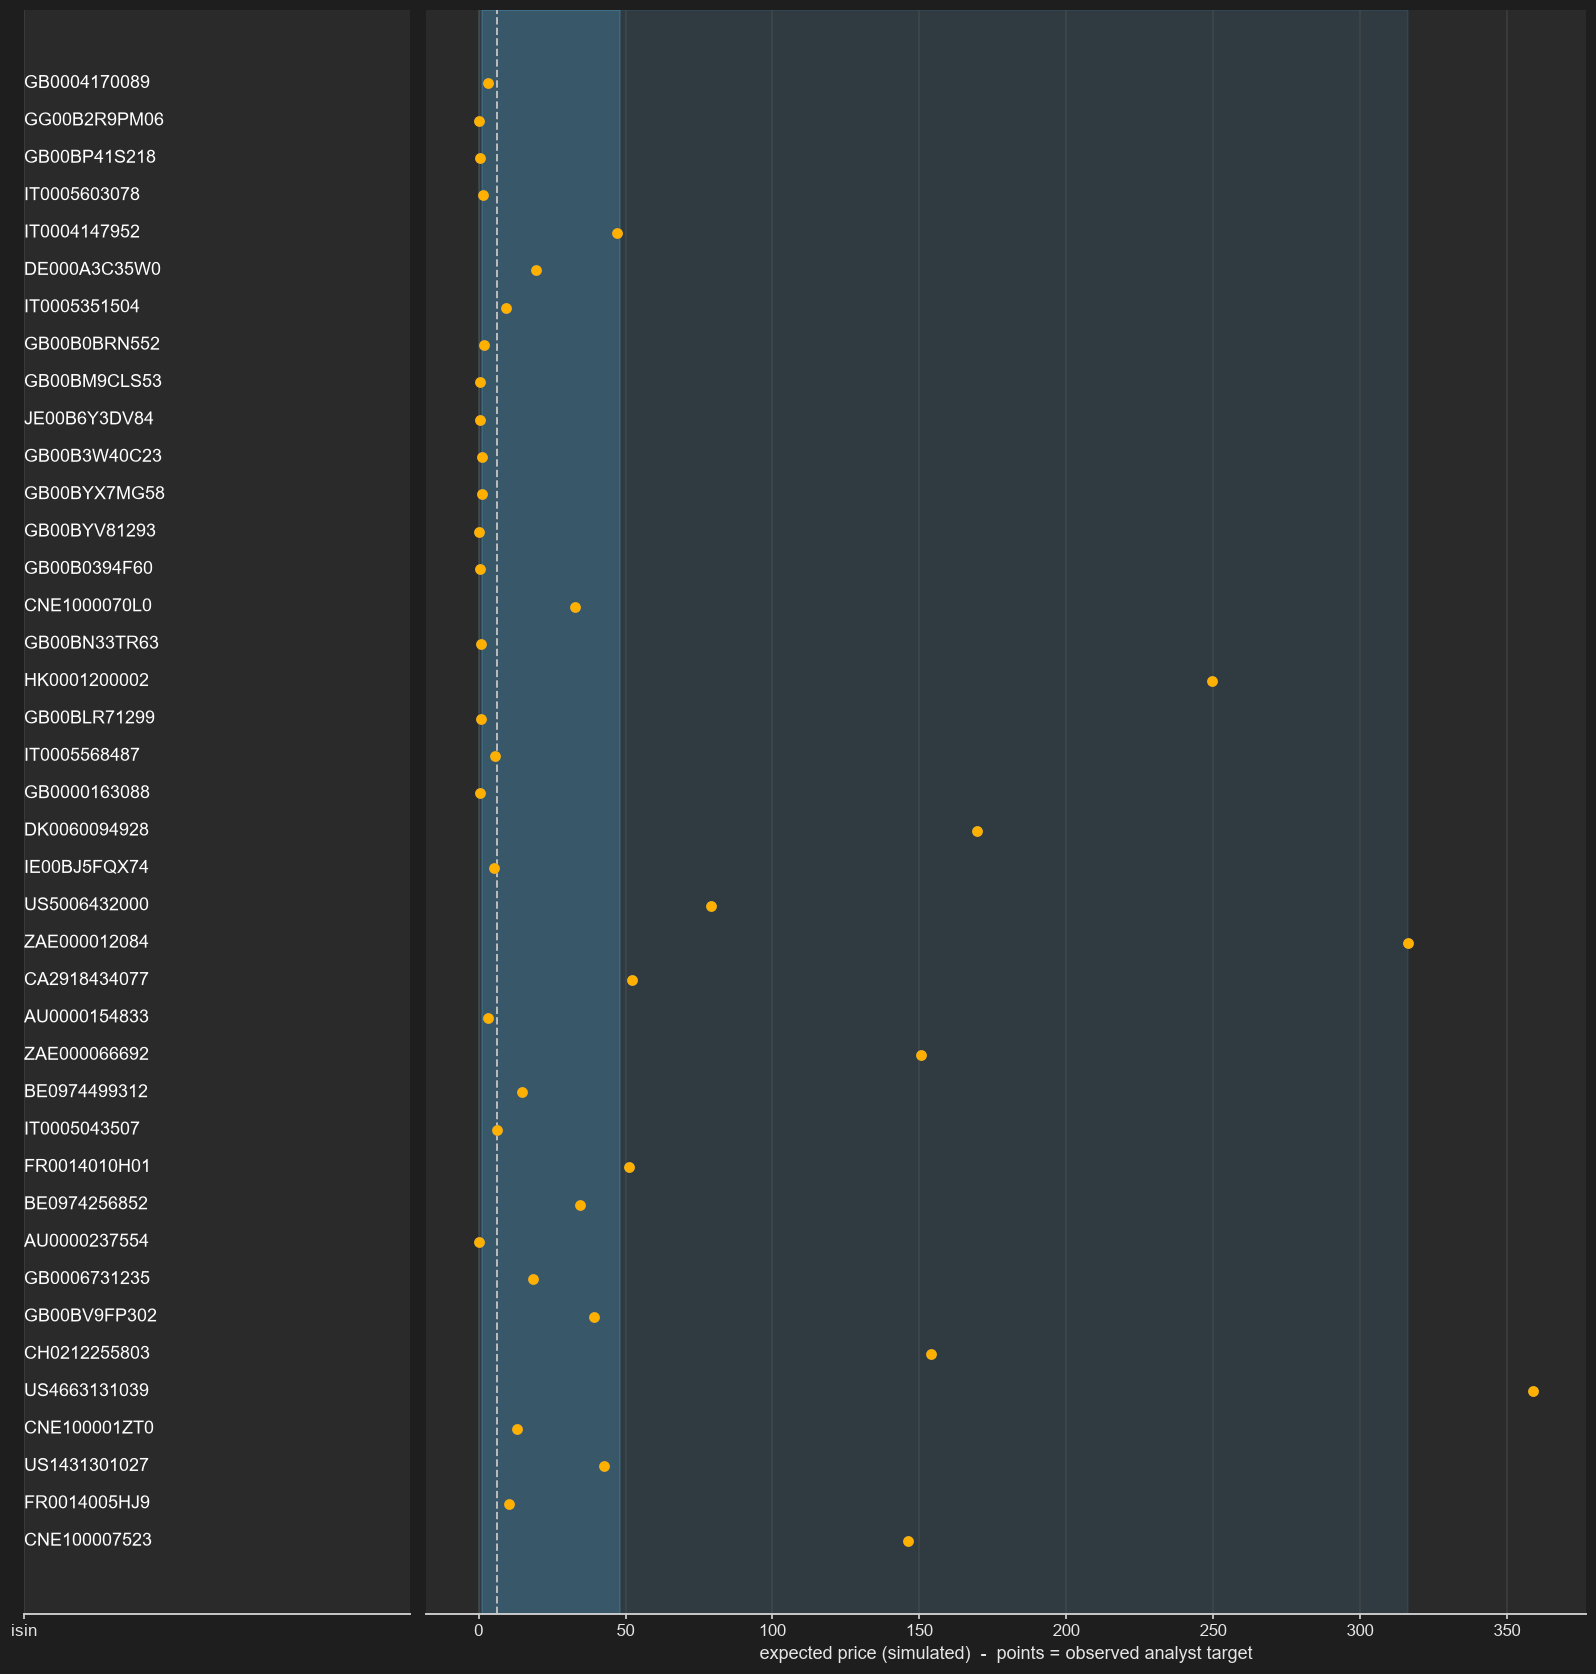

Cohort expected_pt 94% HDI band: (0.17, 316.17);  50% HDI band: (1.00, 48.13);  cohort last_price ref = 6.20.


,isin,ticker,name,sector,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,expected_upside_pct
0,GB0004170089,HEAD,Headlam Group plc,Consumer Discretionary,0.237,3.150,3.149,3.149,3.149,1228.705
1,GG00B2R9PM06,CHAR,Chariot Limited,Energy,0.016,0.197,0.197,0.197,0.197,1116.167
2,GB00BP41S218,SAVE,Savannah Energy PLC,Energy,0.065,0.372,0.372,0.372,0.372,471.836
3,IT0005603078,MS,Misitano & Stracuzzi S.p.A.,Consumer Staples,0.310,1.525,1.525,1.525,1.525,391.936
4,IT0004147952,NWRN,Newron Pharmaceuticals S.p.A.,Health Care,12.060,47.087,47.066,47.066,47.066,290.264
5,DE000A3C35W0,7V0,Darwin AG,Health Care,6.000,19.375,19.362,19.362,19.362,222.694
6,IT0005351504,EDAC,EdiliziAcrobatica S.p.A.,Industrials,3.050,9.350,9.344,9.344,9.344,206.352
7,GB00B0BRN552,BGO,Bango PLC,Information Technology,0.625,1.895,1.894,1.894,1.894,203.060
8,GB00BM9CLS53,LORD,Lords Group Trading plc,Industrials,0.168,0.480,0.480,0.480,0.480,186.443
9,JE00B6Y3DV84,CRTA,Cirata plc,Information Technology,0.160,0.437,0.437,0.437,0.437,172.288


In [41]:
# 11.0  Granular per-ISIN posterior-predictive forest of simulated expected prices for
# the recent-earnings cohort. Re-uses the fitted cross-sectional `idata`, `results`,
# `model_df`, EARNINGS_WINDOW_DAYS and MAX_FOREST from sections 9-10.
try:
    import xarray as xr
    from arviz_plots import visuals as azv

    # Recompute the cohort defensively (section 10 may have been skipped on a re-run).
    if 'days_to_next_earnings' in model_df.columns:
        _dte = pd.to_numeric(model_df['days_to_next_earnings'], errors='coerce')
    else:
        _dte = pd.Series(np.nan, index=model_df.index)
    _mask = (_dte.abs() <= EARNINGS_WINDOW_DAYS).fillna(False).to_numpy()
    _cohort = model_df.loc[_mask, 'isin'].astype(str).tolist()

    # Keep only cohort ISINs present in the fitted posterior-predictive.
    pp = idata.posterior_predictive['target_pct_obs']  # dims (chain, draw, isin)
    obsd = idata.observed_data['target_pct_obs']
    modelled = set(pp.coords['isin'].astype(str).values.tolist())
    _cohort = [i for i in _cohort if i in modelled]
    if not _cohort:
        raise RuntimeError('No earnings-window ISIN overlaps the fitted posterior.')

    # Cap the forest so one row per ISIN stays legible; rank by expected upside.
    cohort_results = (results[results['isin'].isin(_cohort)]
                      .sort_values('expected_upside_pct', ascending=False))
    if len(cohort_results) > MAX_FOREST:
        half = MAX_FOREST // 2
        keep = pd.concat([cohort_results.head(half), cohort_results.tail(half)])
        print(f'Cohort has {len(cohort_results)} ISINs; showing the {MAX_FOREST} most '
              f'extreme by expected upside (top/bottom {half}).')
    else:
        keep = cohort_results
    forest_isins = keep['isin'].astype(str).tolist()

    # Map posterior-predictive / observed target RETURNS to price units per ISIN:
    # price = last_price * (1 + target_pct_obs). Align last_price by ISIN.
    _lp = (pd.Series(model_df['last_price'].to_numpy(),
                     index=model_df['isin'].astype(str).to_numpy())
           .reindex(forest_isins).astype('float64'))
    lp_da = xr.DataArray(_lp.to_numpy(), dims='isin', coords={'isin': forest_isins})

    pp_price = ((1.0 + pp.sel(isin=forest_isins)) * lp_da).rename('expected_price')
    obs_price = ((1.0 + obsd.sel(isin=forest_isins)) * lp_da).rename('expected_price')
    ppc_tree = xr.DataTree.from_dict({
        'posterior_predictive': pp_price.to_dataset(),
        'observed_data': obs_price.to_dataset(),
    })

    # Reference bands from the POSTERIOR expected_pt (price units), pooled over the
    # cohort: expected_pt = last_price * (1 + risk_adj_return). 94% / 50% HDI.
    exp_pt_pool = (((1.0 + idata.posterior['risk_adj_return'].sel(isin=forest_isins))
                    * lp_da).stack(s=('chain', 'draw', 'isin')))
    _q = lambda p: float(exp_pt_pool.quantile(p).values)
    band94 = (_q(0.03), _q(0.97))
    band50 = (_q(0.25), _q(0.75))
    cohort_last_price = float(np.nanmedian(_lp.to_numpy()))

    # Posterior-predictive forest + observed analyst targets (scatter_x overlay).
    pc = azp.plot_forest(
        ppc_tree, group='posterior_predictive', combined=True,
        labels=['isin'], backend='matplotlib',
    )
    pc.map(
        azv.scatter_x, 'observations',
        data=ppc_tree.observed_data.ds, coords={'column': 'forest'},
        color='#ffb000',
    )
    pc.map(
        azv.labelled_x, 'xlabel', coords={'column': 'forest'},
        text='expected price (simulated)  -  points = observed analyst target',
        ignore_aes='y',
    )

    # Reference HDI bands (94% lightest, 50% darker) + cohort last_price line.
    pc.coords = {'column': 'forest'}
    pc = azp.add_bands(pc, values=[band94],
                       visuals={'ref_band': {'color': '#56b4e9', 'alpha': 0.12}})
    pc = azp.add_bands(pc, values=[band50],
                       visuals={'ref_band': {'color': '#56b4e9', 'alpha': 0.24}})
    pc = azp.add_lines(pc, values=cohort_last_price,
                       visuals={'ref_line': {'color': '#bbbbbb',
                                             'linestyle': '--', 'linewidth': 1.3}})
    pc.show()

    print(f'Cohort expected_pt 94% HDI band: ({band94[0]:.2f}, {band94[1]:.2f});  '
          f'50% HDI band: ({band50[0]:.2f}, {band50[1]:.2f});  '
          f'cohort last_price ref = {cohort_last_price:.2f}.')

    # Tidy per-ISIN summary for the names shown in the forest.
    _cols = ['isin', 'ticker', 'name', 'sector', 'last_price', 'observed_pt', 'expected_pt',
             'expected_pt_hdi_lo', 'expected_pt_hdi_hi', 'expected_upside_pct']
    display(keep[[c for c in _cols if c in keep.columns]]
            .round(3).reset_index(drop=True))
except Exception as e:  # pragma: no cover - optional / environment-dependent
    print(f'Section 11 (granular earnings-cohort posterior-predictive forest) skipped: {e!r}')